In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"
import pandas as pd
import numpy as np
import random
import pickle
import re
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
from tqdm import tqdm
from sklearn.metrics import r2_score
import seaborn as sns
# from ucimlrepo import fetch_ucirepo 

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split

from data.data_loader import EPCDataset
from models.lstm import LSTMModel
from models.lstm_attention import LSTMWithAttention, BiLSTMWithAttention
from models.gru import GRUModel
from models.utils import create_model, train_for_short_term_forecast, train_for_long_term_forecast, load_model, evaluate_for_short_term_forecast, evaluate_for_long_term_forecast

from explainers.utils import get_explainer
# from explainers.lime import LimeExplainer
# from explainers.shap import ShapExplainer
# from explainers.attention import AttentionExplainer
# from explainers.grad_cam import GradCAMExplainer
# from explainers.lrp import LRPExplainer

In [2]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. Load dataset

- 하루 기준 1시간 데이터 / 6시간 데이터로 구분
- 각 데이터는 feaature가 다름 (6시간 데이터는 온/습도에 대해 min, max, avg, range를 포함)
- datetime의 경우, sin/cos 임베딩을 하여 feature로 사용

In [3]:
# short term 
features_for_1h = [
    'Global_active_power',
    'Global_intensity',
    'Sub_metering_1', 
    'Sub_metering_2', 
    'Sub_metering_3', 
    'Temperature',	
    'Humidity',	
]

# long term
features_for_6h = [
    'Global_active_power',
    'Global_intensity',
    'Sub_metering_1', 
    'Sub_metering_2', 
    'Sub_metering_3', 
    'Temp_Min',	'Temp_Max', 'Temp_Avg',	'Temp_Range',
    'Humidity_Min',	'Humidity_Max',	'Humidity_Avg',	'Humidity_Range'
]

file_path_for_1h = 'data/final_data.csv'
# file_path_for_6h = 'data/final_data_per_6hr_with_avg_range.csv'

In [4]:
def load_dataset(params, target_features_long, target_features_short, is_long_term_forecast=True):
    selected_features = dict()
    
    if is_long_term_forecast:
        dataset_6h = EPCDataset(
            # file_path=file_path_for_6h,
            file_path=file_path_for_1h,
            sequence_length=params['long_term_length'],  
            prediction_length=params['long_term_pred_length'],
            target_features=target_features_long
        )
        train_long, train_targets_long, eval_long, eval_targets_long = dataset_6h.load_data()
        
        dataset_1h = EPCDataset(
            file_path=file_path_for_1h,
            sequence_length=params['short_term_length'],  
            prediction_length=params['short_term_pred_length'],
            target_features=target_features_short
        )
        train_short, train_targets_short, eval_short, eval_targets_short = dataset_1h.load_data()
        
        train_data=(train_long, train_short)
        train_targets=(train_targets_long, train_targets_short)
        eval_data=(eval_long, eval_short)
        eval_targets=(eval_targets_long, eval_targets_short)

        selected_features['long'] = dataset_6h.selected_features
        selected_features['short'] = dataset_1h.selected_features

    else:
        dataset_1h = EPCDataset(
            file_path=file_path_for_1h,
            sequence_length=params['sequence_length'],  
            prediction_length=params['prediction_length'],
            target_features=target_features_short
        )
        
        train_sequence, train_targets_sequence, eval_sequence, eval_targets_sequence = dataset_1h.load_data()

        train_data=train_sequence
        train_targets=train_targets_sequence
        eval_data=eval_sequence
        eval_targets=eval_targets_sequence
    
        selected_features['single'] = dataset_1h.selected_features

    return train_data, train_targets, eval_data, eval_targets, selected_features

In [5]:
# Task
## long-term forecast: 일주일 전력량 예측 (7*24) -> Long-term Short-term CNN-LSTM 모델
## Short-term forecast: 하루 전력량 예측 (24)    -> LSTM, GRU, CNN-LSTM 모델 

# 1. 온/습도 정보 없는 케이스도 비교 필요 


dataset_params = {
    # for long-term forecast 

    # 'long_term_length' : 365*4, # 6시간 단위 1년 데이터
    'long_term_length' : 90*24,
    'long_term_pred_length' : 256, # 64, 128, 256
    
    'short_term_length' : 30*24, # 1시간 단위 한달 데이터
    'short_term_pred_length' : 7*24, # 일주일 데이터 예측

    
    # 2. LSTM, GRU, CNN-LSTM  -> 365*24 / 7*24 (비교용)
    # for Short-term forecast 
    'sequence_length' : 24*30,  # -> 일주일 / 10일 / 15일 / 한달  
    'prediction_length' : 24
}

In [6]:
is_long_term_forecast = False

train_data, train_targets, eval_data, eval_targets, selected_features = load_dataset(params=dataset_params,
                                                                                     target_features_long=features_for_1h, 
                                                                                     target_features_short=features_for_1h, 
                                                                                     is_long_term_forecast=is_long_term_forecast)

if isinstance(train_data, tuple):
    print("6-hour data sequences for long-term forecast:")
    print(f"  Train sequences shape: {train_data[0].shape}")
    print(f"  Train targets shape: {train_targets[0].shape}")
    print(f"  Eval sequences shape: {eval_data[0].shape}")
    print(f"  Eval targets shape: {eval_targets[0].shape}")
    print(f"  Selected_features: {selected_features['long']}")
    
    print("\n1-hour data sequences for long-term forecast:")
    print(f"  Train sequences shape: {train_data[1].shape}")
    print(f"  Train targets shape: {train_targets[1].shape}")
    print(f"  Eval sequences shape: {eval_data[1].shape}")
    print(f"  Eval targets shape: {eval_targets[1].shape}")
    print(f"  Selected_features: {selected_features['short']}")
    
else:
    print("1-hour data sequences for short-term forecast:")
    print(f"  Train sequences shape: {train_data.shape}")
    print(f"  Train targets shape: {train_targets.shape}")
    print(f"  Eval sequences shape: {eval_data.shape}")
    print(f"  Eval targets shape: {eval_targets.shape}")
    print(f"  Selected_features: {selected_features['single']}")

1-hour data sequences for short-term forecast:
  Train sequences shape: torch.Size([23777, 720, 13])
  Train targets shape: torch.Size([23777, 24])
  Eval sequences shape: torch.Size([5388, 720, 13])
  Eval targets shape: torch.Size([5388, 24])
  Selected_features: ['Global_active_power', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Temperature', 'Humidity', 'sin_hour', 'cos_hour', 'sin_day', 'cos_day', 'sin_month', 'cos_month']


## 2. Load model 

주요 모델 파라미터
- model_name: LSTM, GRU, LSTM-Att, ...
- input_size: feature 개수
- hidden_size: LSTM hidden layer size (128 / 256)
- num_layers: LSTM layer 개수 (2 / 3)
- output_size: 모델 출력 크기 (=prediction_length)

학습 주요 파라미터
- num_epochs
- dropout: fully-connected layer의 드롭아웃 비율
- batch_size
- learning_rate
- patience

모델 이름 (save/load)
- (model_name)_(feature_type)_(days)_(prediction_length)

In [7]:
# from models.lstm import LSTMModel
# from models.gru import GRUModel
# from models.cnnlstm import CNNLSTMModel
# from models.lstm_attention import AttentionLSTMModel, LSTMWithAttention
# from models.ls_cnnlstm import LongShortCNNLSTM
# from models.ls_cnnlstm_attention import LongShortCNNLSTMWithAttention

# def create_model2(model_name, input_size, hidden_size, num_layers, output_size,
#                   dropout=0.2, long_term_length=None, short_term_length=None):
#     if model_name == 'GRU':
#         return GRUModel(input_size['single'], hidden_size, num_layers, output_size['single'], dropout)
#     elif model_name == 'LSTM':
#         return LSTMModel(input_size['single'], hidden_size, num_layers, output_size['single'], dropout)
#     elif model_name == 'LSTM-Att':
#         return LSTMWithAttention(input_size['single'], hidden_size, num_layers, output_size['single'], dropout)
#     elif model_name == 'CNNLSTM':
#         return CNNLSTMModel(input_size['single'], hidden_size, num_layers, output_size['single'], dropout)
#     elif model_name == 'LS_CNNLSTM': 
#         return LongShortCNNLSTM(
#             long_input_size=input_size['long'],
#             short_input_size=input_size['short'],
#             hidden_size=hidden_size,
#             num_layers=num_layers,
#             long_output_size=output_size['long'],
#             short_output_size=output_size['short'],
#             long_term_length=long_term_length,
#             short_term_length=short_term_length,
#             dropout=dropout
#         )
#     elif model_name == 'LS_CNNLSTM_Att': 
#         return LongShortCNNLSTMWithAttention(
#             input_dim_long=input_size['long'],
#             input_dim_short=input_size['short'],
#             hidden_dim=hidden_size,
#             long_output_dim=output_size['long'],
#             output_dim=output_size['short'], 
#             seq_len_long=long_term_length, 
#             seq_len_short=short_term_length)
#     else:
#         raise ValueError(f"Model {model_name} is not recognized.")

In [8]:
# class LS_Loss(nn.Module):
#     def __init__(self, alpha=1.0, beta=0.3, gamma=0.0):
#         super(LS_Loss, self).__init__()
#         self.alpha = alpha  # Weight for Short-term Loss
#         self.beta = beta    # Weight for Long-term Loss
#         self.gamma = gamma  # Weight for Cross-Modality Consistency Loss
#         self.mse_loss = nn.MSELoss()

#     def forward(self, output_long, target_long, output_short, target_short):
#         # Short-term Loss
#         loss_short = self.mse_loss(output_short, target_short)

#         # Long-term Loss
#         loss_long = self.mse_loss(output_long, target_long)

#         # Optional: Cross-Modality Consistency Loss
#         consistency_loss = 0.0
#         if self.gamma > 0:
#             long_mean = torch.mean(output_long, dim=1, keepdim=True)
#             short_mean = torch.mean(output_short, dim=1, keepdim=True)
#             consistency_loss = torch.mean((long_mean - short_mean) ** 2)

#         # Combined Loss
#         total_loss = self.alpha * loss_short + self.beta * loss_long + self.gamma * consistency_loss
#         return total_loss

# class SimpleMSELoss(nn.Module):
#     def __init__(self, alpha=1.0, beta=0.1):
#         super(SimpleMSELoss, self).__init__()
#         self.alpha = alpha  # Weight for Short-term Loss
#         self.beta = beta    # Weight for Long-term Loss
#         self.mse_loss = nn.MSELoss()

#     def forward(self, output_long, target_long, output_short, target_short):
#         # Short-term Loss
#         loss_short = self.mse_loss(output_short, target_short)

#         # Long-term Loss
#         loss_long = self.mse_loss(output_long, target_long)

#         # Combined Loss
#         total_loss = self.alpha * loss_short + self.beta * loss_long
#         return total_loss

# def oversample_data(long_data, short_data, long_targets, short_targets):
#     """
#     Oversample short-term data to match the size of long-term data.
#     """
#     # Check the smaller dataset
#     if len(short_data) < len(long_data):
#         # Calculate the oversample factor and residual
#         oversample_factor = len(long_data) // len(short_data)
#         residual_samples = len(long_data) % len(short_data)

#         # Oversample short data
#         short_data = torch.cat([short_data] * oversample_factor + [short_data[:residual_samples]], dim=0)
#         short_targets = torch.cat([short_targets] * oversample_factor + [short_targets[:residual_samples]], dim=0)
#     elif len(long_data) < len(short_data):
#         # Calculate the oversample factor and residual for long data
#         oversample_factor = len(short_data) // len(long_data)
#         residual_samples = len(short_data) % len(long_data)

#         # Oversample long data
#         long_data = torch.cat([long_data] * oversample_factor + [long_data[:residual_samples]], dim=0)
#         long_targets = torch.cat([long_targets] * oversample_factor + [long_targets[:residual_samples]], dim=0)
    
#     # Ensure shapes match after oversampling
#     assert len(long_data) == len(short_data), "Oversampling failed to match dataset sizes!"
#     assert len(long_targets) == len(short_targets), "Oversampling failed to match target sizes!"

#     return long_data, short_data, long_targets, short_targets


# def train_model_for_short_term_forecast(model, model_name, train_sequences, train_targets, 
#                                          eval_sequences, eval_targets, model_path, num_epochs=100, 
#                                          batch_size=64, learning_rate=0.001, patience=5):
    
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     model.to(device)

#     # Data loader
#     train_dataset = torch.utils.data.TensorDataset(torch.tensor(train_sequences, dtype=torch.float32), torch.tensor(train_targets, dtype=torch.float32))
#     eval_dataset = torch.utils.data.TensorDataset(torch.tensor(eval_sequences, dtype=torch.float32), torch.tensor(eval_targets, dtype=torch.float32))
    
#     train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
#     eval_loader = torch.utils.data.DataLoader(dataset=eval_dataset, batch_size=batch_size, shuffle=False)

#     criterion = nn.MSELoss()
#     optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) #, weight_decay=1e-5)

#     best_val_loss = np.inf
#     epochs_no_improve = 0

#     for epoch in range(num_epochs):
#         model.train()
#         running_loss = 0.0

#         # tqdm을 사용하여 학습 진행도 표시
#         with tqdm(train_loader, unit="batch") as tepoch:
#             for sequences_batch, targets_batch in tepoch:
#                 tepoch.set_description(f"Epoch {epoch+1}/{num_epochs}")
                
#                 # Move batch to GPU
#                 sequences_batch, targets_batch = sequences_batch.to(device), targets_batch.to(device)
                
#                 # Forward pass
#                 if 'Att' in model_name:
#                     outputs, _ = model(sequences_batch) 
#                 else:
#                     outputs = model(sequences_batch)

#                 loss = criterion(outputs.squeeze(), targets_batch)

#                 # Backward pass and optimization
#                 optimizer.zero_grad()
#                 loss.backward()
#                 optimizer.step()

#                 # 현재 배치 손실을 누적
#                 running_loss += loss.item()
#                 tepoch.set_postfix(loss=loss.item())

#         # Epoch 단위로 평균 손실 계산
#         train_loss = running_loss / len(train_loader)

#         # Evaluation on the validation set
#         model.eval()
#         eval_loss = 0.0
#         with torch.no_grad():
#             for sequences_batch, targets_batch in eval_loader:
#                 # Move batch to GPU
#                 sequences_batch, targets_batch = sequences_batch.to(device), targets_batch.to(device)

#                 if 'Att' in model_name:
#                     val_outputs, _ = model(sequences_batch) 
#                 else:
#                     val_outputs = model(sequences_batch)
#                 loss = criterion(val_outputs.squeeze(), targets_batch)
#                 eval_loss += loss.item()

#         eval_loss /= len(eval_loader)
#         print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {eval_loss:.7f}')

#         # Check if the validation loss improved
#         if eval_loss < best_val_loss:
#             best_val_loss = eval_loss
#             torch.save(model.state_dict(), model_path)
#             print(f"Validation loss improved. Model saved at epoch {epoch+1}")
#             epochs_no_improve = 0
#         else:
#             epochs_no_improve += 1

#         # Early stopping
#         if epochs_no_improve >= patience:
#             print(f"Early stopping applied at epoch {epoch+1}")
#             break


# def train_model_for_long_term_forecast(model, model_name, train_data, train_targets, 
#                                        eval_data, eval_targets, model_path, num_epochs=100, 
#                                        batch_size=64, learning_rate=0.001, patience=5, 
#                                        oversample_eval=False, alpha=0.3, beta=1.0):
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     model.to(device)

#     train_long, train_short = train_data
#     train_targets_long, train_targets_short = train_targets

#     eval_long, eval_short = eval_data
#     eval_targets_long, eval_targets_short = eval_targets

#     # Oversample training data
#     print("Perform oversampling on training data...")
#     train_long, train_short, train_targets_long, train_targets_short = oversample_data(
#         train_long, train_short, train_targets_long, train_targets_short
#     )

#     # Optionally oversample evaluation data
#     if oversample_eval:
#         print("Perform oversampling on evaluation data...")
#         eval_long, eval_short, eval_targets_long, eval_targets_short = oversample_data(
#             eval_long, eval_short, eval_targets_long, eval_targets_short
#         )
#     else:
#         min_eval_size = min(len(eval_long), len(eval_short))
#         eval_long = eval_long[:min_eval_size]
#         eval_short = eval_short[:min_eval_size]
#         eval_targets_long = eval_targets_long[:min_eval_size]
#         eval_targets_short = eval_targets_short[:min_eval_size]

#     # DataLoaders
#     train_dataset = torch.utils.data.TensorDataset(train_long, train_short, train_targets_long, train_targets_short)
#     eval_dataset = torch.utils.data.TensorDataset(eval_long, eval_short, eval_targets_long, eval_targets_short)

#     train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
#     eval_loader = DataLoader(dataset=eval_dataset, batch_size=batch_size, shuffle=False)

#     # Loss function and optimizer
#     # criterion = nn.MSELoss()
#     criterion = SimpleMSELoss(alpha=alpha, beta=beta)
#     # criterion = LS_Loss(alpha=1.0, beta=0.3, gamma=0.2, lambda_=0.1, eta=0.01)
    
#     # optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
#     optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
#     best_val_loss = float('inf')
#     epochs_no_improve = 0

#     for epoch in tqdm(range(num_epochs)):
#         model.train()
#         train_loss = 0.0

#         for long_batch, short_batch, target_long, target_short in train_loader:
#             long_batch, short_batch = long_batch.to(device), short_batch.to(device)
#             target_long, target_short = target_long.to(device), target_short.to(device)

#             if 'Att' in model_name:
#                 output_long, output_short, _ = model(long_batch, short_batch)
#             else:
#                 output_long, output_short = model(long_batch, short_batch)
            
#             # loss = criterion(output_long, target_long) + criterion(output_short, target_short)
#             loss = criterion(output_long, target_long, output_short, target_short)

#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()

#             train_loss += loss.item()

#         train_loss /= len(train_loader)

#         # Validation
#         model.eval()
#         eval_loss = 0.0
#         with torch.no_grad():
#             for long_batch, short_batch, target_long, target_short in eval_loader:
#                 long_batch, short_batch = long_batch.to(device), short_batch.to(device)
#                 target_long, target_short = target_long.to(device), target_short.to(device)

#                 if 'Att' in model_name:
#                     output_long, output_short, _ = model(long_batch, short_batch)
#                 else:
#                     output_long, output_short = model(long_batch, short_batch)
                
#                 # loss = criterion(output_long, target_long) + criterion(output_short, target_short)
#                 loss = criterion(output_long, target_long, output_short, target_short)
                
#                 eval_loss += loss.item()

#         eval_loss /= len(eval_loader)
#         scheduler.step(eval_loss)
        
#         print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {eval_loss:.4f}")

#         if not(criterion.alpha == 1.0 and criterion.beta == 1.0):
#             criterion.alpha = min(1.0, criterion.alpha + 0.05)  # Increase alpha
#             criterion.beta = max(0.1, criterion.beta - 0.05)   # Decrease beta
        
#         # Early stopping
#         if eval_loss < best_val_loss:
#             best_val_loss = eval_loss
#             torch.save(model.state_dict(), model_path)
#             print(f"Validation loss improved. Model saved at epoch {epoch+1}")
#             epochs_no_improve = 0
#         else:
#             epochs_no_improve += 1

#         if epochs_no_improve >= patience:
#             print(f"Early stopping at epoch {epoch+1}")
#             break


# def evaluate_for_short_term_forecast(model, eval_sequences, eval_targets, model_name="", batch_size=64):
#     """
#     Evaluate a given model with R², SMAPE, and MASE.
#     """
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     model.to(device)
#     model.eval()

#     eval_dataset = torch.utils.data.TensorDataset(torch.tensor(eval_sequences, dtype=torch.float32),
#                                                   torch.tensor(eval_targets, dtype=torch.float32))
#     eval_loader = torch.utils.data.DataLoader(dataset=eval_dataset, batch_size=batch_size, shuffle=False)

#     all_outputs = []
#     all_targets = []

#     with torch.no_grad():
#         for sequences_batch, targets_batch in eval_loader:
#             sequences_batch, targets_batch = sequences_batch.to(device), targets_batch.to(device)
            
#             if 'Att' in model_name:
#                 outputs, _ = model(sequences_batch)
#             else:
#                 outputs = model(sequences_batch)

#             # 필요에 따라 squeeze() 적용
#             if outputs.shape[-1] == 1:
#                 outputs = outputs.squeeze(-1)

#             all_outputs.append(outputs.cpu().numpy())
#             all_targets.append(targets_batch.cpu().numpy())

#     all_outputs = np.concatenate(all_outputs, axis=0)
#     all_targets = np.concatenate(all_targets, axis=0)

#     # Metrics calculation
#     r2 = r2_score(all_targets, all_outputs)
#     n = len(all_targets)
#     k = eval_data[0].shape[-1] if is_multi_input else eval_data.shape[-1]
#     adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - k - 1)
#     smape_score = smape(all_targets, all_outputs)
#     mase_score = mase(all_targets, all_outputs)

#     # Print results
#     print(f"R² Score: {r2:.4f}")
#     print(f"Adjusted R²: {adjusted_r2:.4f}")
#     print(f"SMAPE: {smape_score:.2f}")
#     print(f"MASE: {mase_score:.4f}")

#     return {"R2": r2, "Adjusted R2": adjusted_r2, "SMAPE": smape_score, "MASE": mase_score}


# def evaluate_for_long_term_forecast(model, eval_data, eval_targets, model_name="", 
#                     batch_size=64, oversample_eval=False):
#     """
#     Evaluate the model using R², SMAPE, and MASE metrics.
#     """
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     model.to(device)
#     model.eval()

#     eval_long, eval_short = eval_data
#     eval_targets_long, eval_targets_short = eval_targets

#     # Optionally oversample evaluation data
#     if oversample_eval:
#         eval_long, eval_short, eval_targets_long, eval_targets_short = oversample_data(
#             eval_long, eval_short, eval_targets_long, eval_targets_short
#         )

#     # Adjust evaluation data sizes if oversample is not applied
#     if not oversample_eval:
#         min_eval_size = min(len(eval_long), len(eval_short))
#         eval_long = eval_long[:min_eval_size]
#         eval_short = eval_short[:min_eval_size]
#         eval_targets_long = eval_targets_long[:min_eval_size]
#         eval_targets_short = eval_targets_short[:min_eval_size]

#     eval_dataset =  torch.utils.data.TensorDataset(eval_long, eval_short, eval_targets_long, eval_targets_short)
#     eval_loader = DataLoader(dataset=eval_dataset, batch_size=batch_size, shuffle=False)

#     all_outputs_long = []
#     all_outputs_short = []
#     all_targets_long = []
#     all_targets_short = []

#     with torch.no_grad():
#         for long_batch, short_batch, long_target, short_target in eval_loader:
#             long_batch, short_batch = long_batch.to(device), short_batch.to(device)
#             long_target, short_target = long_target.to(device), short_target.to(device)

#             if 'Att' in model_name:
#                 output_long, output_short, attention_weights = model(long_batch, short_batch)
#             else:
#                 output_long, output_short = model(long_batch, short_batch)

#             all_outputs_long.append(output_long.cpu().numpy())
#             all_outputs_short.append(output_short.cpu().numpy())
#             all_targets_long.append(long_target.cpu().numpy())
#             all_targets_short.append(short_target.cpu().numpy())

#     all_outputs_long = np.concatenate(all_outputs_long, axis=0)
#     all_outputs_short = np.concatenate(all_outputs_short, axis=0)
#     all_targets_long = np.concatenate(all_targets_long, axis=0)
#     all_targets_short = np.concatenate(all_targets_short, axis=0)

#     # Metrics calculation for long-term and short-term predictions
#     r2_short = r2_score(all_targets_short, all_outputs_short)
#     n = len(all_targets_short)
#     k = eval_data[0].shape[-1]
#     adjusted_r2 = 1 - ((1 - r2_short) * (n - 1)) / (n - k - 1)
#     smape_short = smape(all_targets_short, all_outputs_short)
#     mase_short = mase(all_targets_short, all_outputs_short)


#     # Print results
#     print(f"R² Score: {r2_short:.4f}")
#     print(f"Adjusted R²: {adjusted_r2:.4f}")
#     print(f"SMAPE: {smape_short:.2f}")
#     print(f"MASE: {mase_short:.4f}")
    
#     return {
#         "R2 Short": r2_short,
#         "Adjusted R2": adjusted_r2,
#         "SMAPE Short": smape_short,
#         "MASE Short": mase_short
#     }


In [11]:
def load_trained_model(params):
    if params is None:
        return

    # Extract parameters
    model_name = params['model_name']
    hidden_size = params['hidden_size']
    num_layers = params['num_layers']
    dropout = params['dropout']
    num_epochs = params['num_epochs']
    batch_size = params['batch_size']
    learning_rate = params['learning_rate']
    patience = params['patience']
    mse_decay = params['mse_decay']

    # Determine input size and output size
    input_size = {
        # 'long': len(features_for_6h)+6,
        'long': len(features_for_1h)+6,
        'short': len(features_for_1h)+6,
        'single': len(features_for_1h)+6
    }
    output_size = {
        'long': dataset_params['long_term_pred_length'],
        'short': dataset_params['short_term_pred_length'],
        'single': dataset_params['prediction_length']
    }

    if mse_decay:
        mse_alpha = 0.3
        mse_beta = 1.0

    else:
        mse_alpha = 1.0
        mse_beta = 1.0

    # Model 생성 
    model = create_model(
        model_name=model_name,
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        output_size=output_size,
        dropout=dropout, 
        long_term_length=dataset_params['long_term_length'], 
        short_term_length=dataset_params['short_term_length']
    ) 

    if 'LS_CNNLSTM' in model_name:
        model_path = './trained_models/{}_long_{}_short_{}_{}_{}_{}_alpha_{}_beta_{}.pth'.format(
            model_name, dataset_params['long_term_length'], dataset_params['short_term_length'],
            dataset_params['long_term_pred_length'], hidden_size, num_layers, mse_alpha, mse_beta
        )
    else:
        model_path = './trained_models/{}_{}_{}_{}_{}.pth'.format(
            model_name, dataset_params['sequence_length'], dataset_params['prediction_length'],
             hidden_size, num_layers
        )
        
    print("Model path:", model_path)

    # Load pre-trained model or train a new one
    if os.path.exists(model_path):
        print(f"Loading the pre-trained {model_name} model...")
        model.load_state_dict(torch.load(model_path))
        model.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
    else:
        print(f"{model_name} model not found. Training a new model...")
        if 'LS_CNNLSTM' in model_name:
            train_for_long_term_forecast(
                model=model,
                model_name=model_name,
                train_data=train_data,
                train_targets=train_targets,
                eval_data=eval_data,
                eval_targets=eval_targets,
                model_path=model_path,
                num_epochs=num_epochs,
                batch_size=batch_size,
                learning_rate=learning_rate,
                patience=patience,
                oversample_eval=True, 
                alpha=mse_alpha, 
                beta=mse_beta
            )
        else:
            train_for_short_term_forecast(
                model=model,
                model_name=model_name,
                train_sequences=train_data,
                train_targets=train_targets,
                eval_sequences=eval_data,
                eval_targets=eval_targets,
                model_path=model_path,
                num_epochs=num_epochs,
                batch_size=batch_size,
                learning_rate=learning_rate,
                patience=patience
            )

    return model, model_path

In [ ]:
# LS_CNNLSTM, LS_CNNLSTM_Att -> hz 256, 512, nl 3, mse_d T or F
# LSTM, GRU -> hs(nl): 256(2, 3), 512(2,3)

# model_params = {
#     'model_name' : 'LS_CNNLSTM_Att', 
#     'hidden_size' : 256, # 256 # 512 # 1024
#     'num_layers' : 3,  # 3
#     'dropout' : 0.3,
#     'num_epochs' : 200,
#     'batch_size' : 128,
#     'learning_rate' : 0.001,
#     'patience' : 15,
#     'mse_decay' : False   # 고정, 가중치 변화
# }
model_params = {
    'model_name'  : 'LSTM',
    'hidden_size' : 256,
    'num_layers'  : 2,
    'dropout'     : 0.3,
    'num_epochs'  : 200,
    'batch_size'  : 128,
    'learning_rate': 0.001,
    'patience'    : 15,
    'mse_decay'   : True
}

# build model 
model, model_path = load_trained_model(model_params)

print("Evaluating the model...")
if is_long_term_forecast:
    results = evaluate_for_long_term_forecast(
        model=model,
        eval_data=eval_data,
        eval_targets=eval_targets,
        model_name=model_params['model_name'],
        batch_size=model_params['batch_size'], 
        oversample_eval=True 
    )
else:
    results = evaluate_for_short_term_forecast(
        model=model,
        eval_sequences=eval_data,
        eval_targets=eval_targets,
        model_name=model_params['model_name'],
        batch_size=model_params['batch_size']
    )

In [1]:
# LS_CNNLSTM, LS_CNNLSTM_Att -> hz 256, 512, nl 3, mse_d T or F
# LSTM, GRU -> hs(nl): 256(2, 3), 512(2,3)

model_params = {
    'model_name' : 'LS_CNNLSTM_Att', 
    'hidden_size' : 256, # 256 # 512 # 1024
    'num_layers' : 3,  # 3
    'dropout' : 0.3,
    'num_epochs' : 200,
    'batch_size' : 128,
    'learning_rate' : 0.001,
    'patience' : 15,
    'mse_decay' : True   # 고정, 가중치 변화
}

# model_params = {
#     'model_name' : 'LS_CNNLSTM_Att', 
#     'hidden_size' : 256, # 256 # 512 # 1024
#     'num_layers' : 3,  # 3
#     'dropout' : 0.3,
#     'num_epochs' : 200,
#     'batch_size' : 16,
#     'learning_rate' : 0.001,
#     'patience' : 15,
#     'mse_decay' : True   # 고정, 가중치 변화
# }


# build model 
model, model_path = load_trained_model(model_params)

print("Evaluating the model...")
if is_long_term_forecast:
    results = evaluate_for_long_term_forecast(
        model=model,
        eval_data=eval_data,
        eval_targets=eval_targets,
        model_name=model_params['model_name'],
        batch_size=model_params['batch_size'], 
        oversample_eval=True 
    )
else:
    results = evaluate_for_short_term_forecast(
        model=model,
        eval_sequences=eval_data,
        eval_targets=eval_targets,
        model_name=model_params['model_name'],
        batch_size=model_params['batch_size']
    )

NameError: name 'load_trained_model' is not defined

In [13]:
# LS_CNNLSTM, LS_CNNLSTM_Att -> hz 256, 512, nl 3, mse_d T or F
# LSTM, GRU -> hs(nl): 256(2, 3), 512(2,3)

model_params = {
    'model_name' : 'LS_CNNLSTM_Att', 
    'hidden_size' : 512, # 256 # 512 # 1024
    'num_layers' : 3,  # 3
    'dropout' : 0.3,
    'num_epochs' : 200,
    'batch_size' : 128,
    'learning_rate' : 0.001,
    'patience' : 15,
    'mse_decay' : False   # 고정, 가중치 변화
}

# model_params = {
#     'model_name' : 'LS_CNNLSTM_Att', 
#     'hidden_size' : 256, # 256 # 512 # 1024
#     'num_layers' : 3,  # 3
#     'dropout' : 0.3,
#     'num_epochs' : 200,
#     'batch_size' : 16,
#     'learning_rate' : 0.001,
#     'patience' : 15,
#     'mse_decay' : True   # 고정, 가중치 변화
# }


# build model 
model, model_path = load_trained_model(model_params)

print("Evaluating the model...")
if is_long_term_forecast:
    results = evaluate_for_long_term_forecast(
        model=model,
        eval_data=eval_data,
        eval_targets=eval_targets,
        model_name=model_params['model_name'],
        batch_size=model_params['batch_size'], 
        oversample_eval=True 
    )
else:
    results = evaluate_for_short_term_forecast(
        model=model,
        eval_sequences=eval_data,
        eval_targets=eval_targets,
        model_name=model_params['model_name'],
        batch_size=model_params['batch_size']
    )

Model path: ./trained_models/LS_CNNLSTM_Att_long_2160_short_720_256_512_3_alpha_1.0_beta_1.0.pth
LS_CNNLSTM_Att model not found. Training a new model...
Perform oversampling on training data...
Perform oversampling on evaluation data...


  0%|▍                                                                                            | 1/200 [03:37<12:01:58, 217.68s/it]

Validation loss improved. Model saved at epoch 1


  1%|▉                                                                                            | 2/200 [07:18<12:04:14, 219.47s/it]

Validation loss improved. Model saved at epoch 2


  2%|█▍                                                                                           | 3/200 [10:58<12:01:58, 219.89s/it]

Validation loss improved. Model saved at epoch 3


  2%|█▊                                                                                           | 4/200 [14:39<11:59:51, 220.36s/it]

Validation loss improved. Model saved at epoch 4


  2%|██▎                                                                                          | 5/200 [18:20<11:56:15, 220.39s/it]

Validation loss improved. Model saved at epoch 5


  4%|███▎                                                                                         | 7/200 [25:38<11:47:01, 219.80s/it]

Validation loss improved. Model saved at epoch 7


  4%|███▋                                                                                         | 8/200 [29:18<11:44:25, 220.13s/it]

Validation loss improved. Model saved at epoch 8


  5%|████▌                                                                                       | 10/200 [36:36<11:35:28, 219.62s/it]

Validation loss improved. Model saved at epoch 10


  6%|█████                                                                                       | 11/200 [40:17<11:32:43, 219.91s/it]

Validation loss improved. Model saved at epoch 11


  8%|███████▋                                                                                  | 17/200 [1:02:01<11:05:48, 218.30s/it]

Validation loss improved. Model saved at epoch 17


 10%|█████████                                                                                 | 20/200 [1:12:55<10:55:12, 218.41s/it]

Validation loss improved. Model saved at epoch 20


 12%|██████████▊                                                                               | 24/200 [1:27:26<10:40:23, 218.32s/it]

Validation loss improved. Model saved at epoch 24


 14%|████████████▏                                                                             | 27/200 [1:38:20<10:29:59, 218.49s/it]

Validation loss improved. Model saved at epoch 27


 14%|████████████▌                                                                             | 28/200 [1:42:01<10:28:47, 219.35s/it]

Validation loss improved. Model saved at epoch 28


 14%|█████████████                                                                             | 29/200 [1:45:42<10:26:17, 219.75s/it]

Validation loss improved. Model saved at epoch 29


 17%|███████████████▎                                                                          | 34/200 [2:03:50<10:04:28, 218.48s/it]

Validation loss improved. Model saved at epoch 34


 18%|███████████████▋                                                                          | 35/200 [2:07:30<10:02:37, 219.14s/it]

Validation loss improved. Model saved at epoch 35


 18%|████████████████▊                                                                          | 37/200 [2:14:48<9:55:25, 219.18s/it]

Validation loss improved. Model saved at epoch 37


 20%|█████████████████▋                                                                         | 39/200 [2:22:05<9:47:49, 219.07s/it]

Validation loss improved. Model saved at epoch 39


 20%|██████████████████▏                                                                        | 40/200 [2:25:46<9:46:01, 219.76s/it]

Validation loss improved. Model saved at epoch 40


 20%|██████████████████▋                                                                        | 41/200 [2:29:27<9:42:56, 219.98s/it]

Validation loss improved. Model saved at epoch 41


 21%|███████████████████                                                                        | 42/200 [2:33:08<9:39:46, 220.17s/it]

Validation loss improved. Model saved at epoch 42


 23%|████████████████████▉                                                                      | 46/200 [2:47:39<9:21:42, 218.85s/it]

Validation loss improved. Model saved at epoch 46


 26%|███████████████████████▏                                                                   | 51/200 [3:05:46<9:01:53, 218.21s/it]

Validation loss improved. Model saved at epoch 51


 26%|███████████████████████▋                                                                   | 52/200 [3:09:27<9:00:23, 219.08s/it]

Validation loss improved. Model saved at epoch 52


 33%|██████████████████████████████                                                             | 66/200 [4:03:38<8:14:39, 221.49s/it]

Early stopping at epoch 67
Evaluating the model...


R² Score: -0.0537
Adjusted R²: -0.0561
SMAPE: 72.64
MASE: 1.6596


In [14]:
# LS_CNNLSTM, LS_CNNLSTM_Att -> hz 256, 512, nl 3, mse_d T or F
# LSTM, GRU -> hs(nl): 256(2, 3), 512(2,3)

model_params = {
    'model_name' : 'LS_CNNLSTM_Att', 
    'hidden_size' : 512, # 256 # 512 # 1024
    'num_layers' : 3,  # 3
    'dropout' : 0.3,
    'num_epochs' : 200,
    'batch_size' : 128,
    'learning_rate' : 0.001,
    'patience' : 15,
    'mse_decay' : True   # 고정, 가중치 변화
}

# model_params = {
#     'model_name' : 'LS_CNNLSTM_Att', 
#     'hidden_size' : 256, # 256 # 512 # 1024
#     'num_layers' : 3,  # 3
#     'dropout' : 0.3,
#     'num_epochs' : 200,
#     'batch_size' : 16,
#     'learning_rate' : 0.001,
#     'patience' : 15,
#     'mse_decay' : True   # 고정, 가중치 변화
# }


# build model 
model, model_path = load_trained_model(model_params)

print("Evaluating the model...")
if is_long_term_forecast:
    results = evaluate_for_long_term_forecast(
        model=model,
        eval_data=eval_data,
        eval_targets=eval_targets,
        model_name=model_params['model_name'],
        batch_size=model_params['batch_size'], 
        oversample_eval=True 
    )
else:
    results = evaluate_for_short_term_forecast(
        model=model,
        eval_sequences=eval_data,
        eval_targets=eval_targets,
        model_name=model_params['model_name'],
        batch_size=model_params['batch_size']
    )

Model path: ./trained_models/LS_CNNLSTM_Att_long_2160_short_720_256_512_3_alpha_0.3_beta_1.0.pth
LS_CNNLSTM_Att model not found. Training a new model...
Perform oversampling on training data...
Perform oversampling on evaluation data...


  0%|▍                                                                                            | 1/200 [03:36<11:59:09, 216.83s/it]

Validation loss improved. Model saved at epoch 1


  1%|▉                                                                                            | 2/200 [07:17<12:03:31, 219.25s/it]

Validation loss improved. Model saved at epoch 2


  2%|█▍                                                                                           | 3/200 [10:58<12:01:59, 219.90s/it]

Validation loss improved. Model saved at epoch 3


  2%|█▊                                                                                           | 4/200 [14:39<11:59:23, 220.22s/it]

Validation loss improved. Model saved at epoch 4


  2%|██▎                                                                                          | 5/200 [18:20<11:56:57, 220.60s/it]

Validation loss improved. Model saved at epoch 5


  3%|██▊                                                                                          | 6/200 [22:01<11:53:17, 220.61s/it]

Validation loss improved. Model saved at epoch 6


  4%|███▎                                                                                         | 7/200 [25:41<11:49:20, 220.52s/it]

Validation loss improved. Model saved at epoch 7


  4%|████▏                                                                                        | 9/200 [32:58<11:39:33, 219.76s/it]

Validation loss improved. Model saved at epoch 9


  6%|█████▉                                                                                      | 13/200 [47:28<11:20:46, 218.43s/it]

Validation loss improved. Model saved at epoch 13


  8%|██████▉                                                                                     | 15/200 [54:46<11:14:31, 218.76s/it]

Validation loss improved. Model saved at epoch 15


  8%|███████▎                                                                                    | 16/200 [58:27<11:12:45, 219.38s/it]

Validation loss improved. Model saved at epoch 16


  8%|███████▋                                                                                  | 17/200 [1:02:08<11:10:31, 219.84s/it]

Validation loss improved. Model saved at epoch 17


 10%|█████████                                                                                 | 20/200 [1:13:02<10:57:04, 219.03s/it]

Validation loss improved. Model saved at epoch 20


 13%|███████████▋                                                                              | 26/200 [1:34:45<10:32:42, 218.17s/it]

Validation loss improved. Model saved at epoch 26


 16%|██████████████▍                                                                           | 32/200 [1:56:29<10:10:37, 218.08s/it]

Validation loss improved. Model saved at epoch 32


 18%|████████████████▊                                                                          | 37/200 [2:14:36<9:52:24, 218.06s/it]

Validation loss improved. Model saved at epoch 37


 22%|████████████████████▍                                                                      | 45/200 [2:43:33<9:22:48, 217.86s/it]

Validation loss improved. Model saved at epoch 45


 23%|████████████████████▉                                                                      | 46/200 [2:47:13<9:21:17, 218.68s/it]

Validation loss improved. Model saved at epoch 46


 24%|█████████████████████▊                                                                     | 48/200 [2:54:31<9:14:33, 218.91s/it]

Validation loss improved. Model saved at epoch 48


 24%|██████████████████████▎                                                                    | 49/200 [2:58:11<9:11:56, 219.31s/it]

Validation loss improved. Model saved at epoch 49


 28%|█████████████████████████▍                                                                 | 56/200 [3:23:32<8:43:38, 218.19s/it]

Validation loss improved. Model saved at epoch 56


 30%|███████████████████████████▎                                                               | 60/200 [3:38:02<8:29:05, 218.18s/it]

Validation loss improved. Model saved at epoch 60


 34%|██████████████████████████████▍                                                            | 67/200 [4:03:22<8:02:57, 217.88s/it]

Validation loss improved. Model saved at epoch 67


 35%|███████████████████████████████▊                                                           | 70/200 [4:14:16<7:52:51, 218.24s/it]

Validation loss improved. Model saved at epoch 70


 36%|████████████████████████████████▎                                                          | 71/200 [4:17:57<7:50:57, 219.05s/it]

Validation loss improved. Model saved at epoch 71


 38%|███████████████████████████████████                                                        | 77/200 [4:39:41<7:27:19, 218.21s/it]

Validation loss improved. Model saved at epoch 77


 39%|███████████████████████████████████▍                                                       | 78/200 [4:43:21<7:25:14, 218.97s/it]

Validation loss improved. Model saved at epoch 78


 42%|██████████████████████████████████████▋                                                    | 85/200 [5:08:41<6:57:34, 217.86s/it]

Validation loss improved. Model saved at epoch 85


 46%|█████████████████████████████████████████▊                                                 | 92/200 [5:34:01<6:32:27, 218.03s/it]

Validation loss improved. Model saved at epoch 92


 48%|███████████████████████████████████████████▏                                               | 95/200 [5:44:55<6:22:04, 218.33s/it]

Validation loss improved. Model saved at epoch 95


 51%|█████████████████████████████████████████████▉                                            | 102/200 [6:10:15<5:55:54, 217.90s/it]

Validation loss improved. Model saved at epoch 102


 52%|██████████████████████████████████████████████▎                                           | 103/200 [6:13:56<5:53:33, 218.69s/it]

Validation loss improved. Model saved at epoch 103


 52%|███████████████████████████████████████████████▎                                          | 105/200 [6:21:13<5:46:43, 218.98s/it]

Validation loss improved. Model saved at epoch 105


 56%|█████████████████████████████████████████████████▉                                        | 111/200 [6:42:57<5:23:28, 218.07s/it]

Validation loss improved. Model saved at epoch 111


 58%|████████████████████████████████████████████████████▏                                     | 116/200 [7:01:04<5:05:23, 218.14s/it]

Validation loss improved. Model saved at epoch 116


 59%|█████████████████████████████████████████████████████                                     | 118/200 [7:08:22<4:58:41, 218.55s/it]

Validation loss improved. Model saved at epoch 118


 62%|███████████████████████████████████████████████████████▎                                  | 123/200 [7:26:29<4:39:57, 218.15s/it]

Validation loss improved. Model saved at epoch 123


 62%|████████████████████████████████████████████████████████▎                                 | 125/200 [7:33:47<4:33:25, 218.74s/it]

Validation loss improved. Model saved at epoch 125


 64%|█████████████████████████████████████████████████████████▏                                | 127/200 [7:41:03<4:26:07, 218.74s/it]

Validation loss improved. Model saved at epoch 127


 64%|██████████████████████████████████████████████████████████                                | 129/200 [7:48:21<4:19:07, 218.98s/it]

Validation loss improved. Model saved at epoch 129


 65%|██████████████████████████████████████████████████████████▌                               | 130/200 [7:52:02<4:16:05, 219.50s/it]

Validation loss improved. Model saved at epoch 130


 66%|███████████████████████████████████████████████████████████▍                              | 132/200 [7:59:19<4:08:30, 219.28s/it]

Validation loss improved. Model saved at epoch 132


 67%|████████████████████████████████████████████████████████████▎                             | 134/200 [8:06:37<4:01:09, 219.24s/it]

Validation loss improved. Model saved at epoch 134


 68%|████████████████████████████████████████████████████████████▊                             | 135/200 [8:10:18<3:57:58, 219.66s/it]

Validation loss improved. Model saved at epoch 135


 68%|█████████████████████████████████████████████████████████████▏                            | 136/200 [8:13:58<3:54:38, 219.98s/it]

Validation loss improved. Model saved at epoch 136


 69%|██████████████████████████████████████████████████████████████                            | 138/200 [8:21:16<3:46:50, 219.52s/it]

Validation loss improved. Model saved at epoch 138


 70%|██████████████████████████████████████████████████████████████▉                           | 140/200 [8:28:33<3:39:24, 219.40s/it]

Validation loss improved. Model saved at epoch 140


 71%|███████████████████████████████████████████████████████████████▉                          | 142/200 [8:35:51<3:31:52, 219.17s/it]

Validation loss improved. Model saved at epoch 142


 72%|████████████████████████████████████████████████████████████████▊                         | 144/200 [8:43:08<3:24:31, 219.13s/it]

Validation loss improved. Model saved at epoch 144


 72%|█████████████████████████████████████████████████████████████████▎                        | 145/200 [8:46:48<3:21:10, 219.47s/it]

Validation loss improved. Model saved at epoch 145


 74%|██████████████████████████████████████████████████████████████████▏                       | 147/200 [8:54:06<3:13:44, 219.32s/it]

Validation loss improved. Model saved at epoch 147


 74%|██████████████████████████████████████████████████████████████████▌                       | 148/200 [8:57:47<3:10:26, 219.75s/it]

Validation loss improved. Model saved at epoch 148


 76%|████████████████████████████████████████████████████████████████████▊                     | 153/200 [9:15:54<2:51:05, 218.42s/it]

Validation loss improved. Model saved at epoch 153


 78%|█████████████████████████████████████████████████████████████████████▊                    | 155/200 [9:23:12<2:44:06, 218.80s/it]

Validation loss improved. Model saved at epoch 155


 78%|██████████████████████████████████████████████████████████████████████▏                   | 156/200 [9:26:52<2:40:48, 219.29s/it]

Validation loss improved. Model saved at epoch 156


 80%|███████████████████████████████████████████████████████████████████████▌                  | 159/200 [9:37:47<2:29:33, 218.87s/it]

Validation loss improved. Model saved at epoch 159


 80%|████████████████████████████████████████████████████████████████████████▍                 | 161/200 [9:45:04<2:22:21, 219.01s/it]

Validation loss improved. Model saved at epoch 161


 81%|████████████████████████████████████████████████████████████████████████▉                 | 162/200 [9:48:45<2:19:02, 219.53s/it]

Validation loss improved. Model saved at epoch 162


 82%|██████████████████████████████████████████████████████████████████████████▎               | 165/200 [9:59:39<2:07:38, 218.81s/it]

Validation loss improved. Model saved at epoch 165


 84%|███████████████████████████████████████████████████████████████████████████▏             | 169/200 [10:14:09<1:52:49, 218.38s/it]

Validation loss improved. Model saved at epoch 169


 85%|███████████████████████████████████████████████████████████████████████████▋             | 170/200 [10:17:50<1:49:35, 219.20s/it]

Validation loss improved. Model saved at epoch 170


 87%|█████████████████████████████████████████████████████████████████████████████▍           | 174/200 [10:32:21<1:34:41, 218.54s/it]

Validation loss improved. Model saved at epoch 174


 88%|█████████████████████████████████████████████████████████████████████████████▉           | 175/200 [10:36:02<1:31:19, 219.19s/it]

Validation loss improved. Model saved at epoch 175


 90%|████████████████████████████████████████████████████████████████████████████████         | 180/200 [10:54:09<1:12:46, 218.34s/it]

Validation loss improved. Model saved at epoch 180


 92%|███████████████████████████████████████████████████████████████████████████████████▋       | 184/200 [11:08:40<58:12, 218.29s/it]

Validation loss improved. Model saved at epoch 184


 92%|████████████████████████████████████████████████████████████████████████████████████▏      | 185/200 [11:12:21<54:49, 219.27s/it]

Validation loss improved. Model saved at epoch 185


 96%|██████████████████████████████████████████████████████████████████████████████████████▉    | 191/200 [11:34:05<32:43, 218.21s/it]

Validation loss improved. Model saved at epoch 191


 97%|████████████████████████████████████████████████████████████████████████████████████████▎  | 194/200 [11:44:59<21:51, 218.52s/it]

Validation loss improved. Model saved at epoch 194


100%|███████████████████████████████████████████████████████████████████████████████████████████| 200/200 [12:06:39<00:00, 218.00s/it]


Evaluating the model...
R² Score: 0.4989
Adjusted R²: 0.4978
SMAPE: 48.29
MASE: 1.0443


## 3. Apply explainers

- Multi-term이 되면서, explainer를 어떤식으로 적용하여 feature를 뽑을지에 대한 전략이 필요
    - Long/short 각각에서 주요 feature 추출? ong-term과 Short-term 데이터를 결합하여 통합 feature 추출? 둘 모두 사용?
    - 재학습까지 고려해야함

각 explainer에 대해서
- explainer별 시각화 (explainer의 결과 확인)
- explainer별 주요 feature 추출

In [48]:
important_features_dict = {}


if isinstance(train_data, tuple):
    num_samples=len(eval_data[0])
else:
    num_samples=eval_data.shape[0]
    
num_samples=1000
print('num_samples: ', num_samples)


top_n=len(features_for_1h)

if is_long_term_forecast:
    sequence_length = {
        'long': dataset_params['long_term_length'],
        'short': dataset_params['short_term_length']
    }
    input_size = {
        # 'long': len(features_for_6h)+6,
        'long': len(features_for_1h)+6,
        'short': len(features_for_1h)+6,
        'single': len(features_for_1h)+6
    }
    output_size = {
        'long': dataset_params['long_term_pred_length'],
        'short': dataset_params['short_term_pred_length'],
        'single': dataset_params['prediction_length']
    }
else:
    sequence_length = {
        'single': dataset_params['sequence_length']
    }
    input_size = {
        'single': len(features_for_1h)+6
    }
    output_size = {
        'single': dataset_params['prediction_length']
    }

num_samples:  1000


### 3-1. LIME
Long-term Short-term CNN-LSTM의 경우, long/short term 각각에 대해서 lime을 적용하고 주요 feature를 추출

In [49]:
explainer_type = 'LIME' 

explainer = get_explainer(
    explainer_type=explainer_type, 
    model=model, 
    device=device, 
    train_data=train_data,  
    sequence_length=sequence_length,
    input_size=input_size,
    selected_features=selected_features,
    scaler=MinMaxScaler()
)

In [ ]:
###인스턴스 하나 시각화

if is_long_term_forecast:
    random_index = np.random.choice(len(eval_data[0])) 
    print('random_index: ', random_index)
    
    random_data_point_long = eval_data[0][random_index]  # Long-term 데이터 포인트
    random_data_point_short = eval_data[1][random_index]  # Short-term 데이터 포인트
    
    data_point_long = random_data_point_long.cpu().numpy() if isinstance(random_data_point_long, torch.Tensor) else random_data_point_long
    data_point_short = random_data_point_short.cpu().numpy() if isinstance(random_data_point_short, torch.Tensor) else random_data_point_short
    
    print(data_point_long.shape)
    print(data_point_short.shape)
    
    
    # num_samples = num_samples-500 # -500: for attention model
    
    explanation = explainer.explain(
        data_point_long=data_point_long,
        data_point_short=data_point_short,
        eval_long=eval_data[0],
        eval_short=eval_data[1],
        # data_index=random_index,
        # num_features=top_n, 
        num_samples=num_samples,
        is_visual=True
    )

else:
    random_index = np.random.choice(len(eval_data)) 
    print('random_index: ', random_index)
    
    random_data_point = eval_data[random_index]  
    data_point = random_data_point.cpu().numpy() if isinstance(random_data_point, torch.Tensor) else random_data_point
    
    num_samples = num_samples - 500  # Attention 모델 대비 감소
    
    explanation = explainer.explain(
        data_point=data_point,
        eval_sequences=eval_data,
        num_samples=num_samples,
        is_visual=True
    )

**주요 feature 추출**

In [50]:
if is_long_term_forecast:
    important_features = explainer.extract_important_features(
        eval_long=eval_data[0],
        eval_short=eval_data[1],
        num_datapoints=len(eval_data[0]), #1000, # 300 
        top_n_for_long=top_n,
        top_n_for_short=top_n,
        # top_n=top_n,
        num_samples=num_samples
    )
    
    print("Important Long-term Features:")
    for feature in important_features["long"]:
        feature_name, scoore = feature
        print('{}: {}'.format(feature_name, scoore))
        
    print("\n\nImportant Short-term Features:")
    for feature in important_features["short"]:
        feature_name, scoore = feature
        print('{}: {}'.format(feature_name, scoore))
    
    def save_important_features(important_features, output_file):
        with open(output_file, 'a') as file:
            file.write("\n\n{}\n".format(model_path))
            file.write("Important Long-term Features:\n")
            for feature_name, score in important_features["long"]:
                file.write(f"{feature_name}: {score}\n")
            
            file.write("\n\nImportant Short-term Features:\n")
            for feature_name, score in important_features["short"]:
                file.write(f"{feature_name}: {score}\n")
                
    output_file = "important_features_all_samples.txt"
    save_important_features(important_features, output_file)
    
    print(f"Important features saved to {output_file}")
else:
    print("single term")
    important_features = explainer.extract_important_features(
        eval_data=eval_data,
        # num_datapoints=len(eval_data), 
        num_datapoints=eval_data.shape[0],  
        top_n=top_n,
        num_samples=num_samples
    )
    
    print("\n\nImportant Features:")
    for feature in important_features["single"]:
        feature_name, score = feature
        print('{}: {}'.format(feature_name, score))

    def save_important_features(important_features, output_file, model_path):
        with open(output_file, 'a') as file:
            file.write("\n\n{}\n".format(model_path))
            file.write("Important Features:\n")
            for feature_name, score in important_features["single"]:
                file.write(f"{feature_name}: {score}\n")
    
    output_file = "important_features_all_samples_for_shortermforecasting.txt"
    save_important_features(important_features, output_file, model_path)
    
    print(f"Important features saved to {output_file}")

single term


Processing samples:   0%|                                                                          | 1/5982 [00:04<7:21:16,  4.43s/it]

Processing 0/5982 samples...
Important Features:  {'Global_active_power': 0, 'Global_intensity': 0, 'Sub_metering_1': 0, 'Sub_metering_2': 0, 'Sub_metering_3': 0.022725805614378928, 'Temperature': 0, 'Humidity': 0.01965043094027072, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:   1%|▍                                                                        | 31/5982 [02:18<7:19:23,  4.43s/it]

Processing 30/5982 samples...
Important Features:  {'Global_active_power': 0.7500198786317199, 'Global_intensity': 0.6223637635298518, 'Sub_metering_1': 0.029235216587047294, 'Sub_metering_2': 0.6062013509221437, 'Sub_metering_3': 0.5984681149699186, 'Temperature': 0.5657467183059048, 'Humidity': 0.654534419373889, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:   1%|▋                                                                        | 61/5982 [04:33<7:24:46,  4.51s/it]

Processing 60/5982 samples...
Important Features:  {'Global_active_power': 1.220367093060474, 'Global_intensity': 1.302655063400397, 'Sub_metering_1': 0.11222875557413874, 'Sub_metering_2': 1.2345905631021863, 'Sub_metering_3': 1.4626110483274166, 'Temperature': 1.1206928939332512, 'Humidity': 1.1440834779634559, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:   2%|█                                                                        | 91/5982 [06:48<7:22:38,  4.51s/it]

Processing 90/5982 samples...
Important Features:  {'Global_active_power': 1.9057331432340856, 'Global_intensity': 1.9280587867135606, 'Sub_metering_1': 0.18566417383767386, 'Sub_metering_2': 1.8399043793726964, 'Sub_metering_3': 2.347691938377477, 'Temperature': 1.6618245439959451, 'Humidity': 1.726117464509463, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:   2%|█▍                                                                      | 121/5982 [09:03<7:15:31,  4.46s/it]

Processing 120/5982 samples...
Important Features:  {'Global_active_power': 2.5742379183919004, 'Global_intensity': 2.623908337562102, 'Sub_metering_1': 0.23053474663826745, 'Sub_metering_2': 2.158012235157208, 'Sub_metering_3': 3.055058985883368, 'Temperature': 2.0822105056053735, 'Humidity': 2.292470862633486, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:   3%|█▊                                                                      | 151/5982 [11:17<7:18:17,  4.51s/it]

Processing 150/5982 samples...
Important Features:  {'Global_active_power': 3.123887392093234, 'Global_intensity': 3.140400547311084, 'Sub_metering_1': 0.31433754098516203, 'Sub_metering_2': 2.7594008967142547, 'Sub_metering_3': 3.6994299493127127, 'Temperature': 2.529600773202755, 'Humidity': 2.848218417719581, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:   3%|██▏                                                                     | 181/5982 [13:33<7:15:31,  4.50s/it]

Processing 180/5982 samples...
Important Features:  {'Global_active_power': 3.8663159566865453, 'Global_intensity': 3.7759738270472276, 'Sub_metering_1': 0.3391863468680091, 'Sub_metering_2': 3.2201868838774046, 'Sub_metering_3': 4.485995173024803, 'Temperature': 2.9380113693343586, 'Humidity': 3.3976703011662006, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:   4%|██▌                                                                     | 211/5982 [15:50<7:12:57,  4.50s/it]

Processing 210/5982 samples...
Important Features:  {'Global_active_power': 4.702328775660082, 'Global_intensity': 4.522310442747824, 'Sub_metering_1': 0.444402554820372, 'Sub_metering_2': 3.899661301472823, 'Sub_metering_3': 5.008170583103166, 'Temperature': 3.591558713969447, 'Humidity': 3.8645806459316763, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:   4%|██▉                                                                     | 241/5982 [18:05<7:07:20,  4.47s/it]

Processing 240/5982 samples...
Important Features:  {'Global_active_power': 5.575257862654711, 'Global_intensity': 5.2356848390581465, 'Sub_metering_1': 0.6825151527358388, 'Sub_metering_2': 4.470247954605312, 'Sub_metering_3': 5.867339197262347, 'Temperature': 4.083680933637459, 'Humidity': 4.424795985448887, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:   5%|███▎                                                                    | 271/5982 [20:20<7:12:18,  4.54s/it]

Processing 270/5982 samples...
Important Features:  {'Global_active_power': 6.249606540751796, 'Global_intensity': 5.931799256971459, 'Sub_metering_1': 0.8279766957750965, 'Sub_metering_2': 5.0546167779377695, 'Sub_metering_3': 6.549293165687056, 'Temperature': 4.519369724287977, 'Humidity': 4.887507119085219, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:   5%|███▌                                                                    | 301/5982 [22:35<7:07:39,  4.52s/it]

Processing 300/5982 samples...
Important Features:  {'Global_active_power': 7.046053134392216, 'Global_intensity': 6.428110498125231, 'Sub_metering_1': 0.8796245245722768, 'Sub_metering_2': 5.610443318583045, 'Sub_metering_3': 7.267266127036188, 'Temperature': 5.155401366212147, 'Humidity': 5.44842742850196, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:   6%|███▉                                                                    | 331/5982 [24:50<7:04:41,  4.51s/it]

Processing 330/5982 samples...
Important Features:  {'Global_active_power': 7.7305919721965966, 'Global_intensity': 7.145507999823881, 'Sub_metering_1': 0.9558698127200846, 'Sub_metering_2': 6.031358869496991, 'Sub_metering_3': 8.077574078663082, 'Temperature': 5.761082231483111, 'Humidity': 6.003124182065197, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:   6%|████▎                                                                   | 361/5982 [27:07<6:57:08,  4.45s/it]

Processing 360/5982 samples...
Important Features:  {'Global_active_power': 8.294370512462738, 'Global_intensity': 7.9578261041275224, 'Sub_metering_1': 1.099874752195348, 'Sub_metering_2': 6.567345834643593, 'Sub_metering_3': 8.901816441795532, 'Temperature': 6.290482470377043, 'Humidity': 6.359070486478051, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:   7%|████▋                                                                   | 391/5982 [29:21<7:01:11,  4.52s/it]

Processing 390/5982 samples...
Important Features:  {'Global_active_power': 9.071587635503496, 'Global_intensity': 8.445889769988062, 'Sub_metering_1': 1.231535136066541, 'Sub_metering_2': 6.950057627762516, 'Sub_metering_3': 9.7197746009036, 'Temperature': 6.713863129006167, 'Humidity': 6.946807966133179, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:   7%|█████                                                                   | 421/5982 [31:38<6:58:13,  4.51s/it]

Processing 420/5982 samples...
Important Features:  {'Global_active_power': 9.696035031769986, 'Global_intensity': 9.199951120806203, 'Sub_metering_1': 1.3119624460230348, 'Sub_metering_2': 7.641700878827779, 'Sub_metering_3': 10.336115272439965, 'Temperature': 7.223100748913472, 'Humidity': 7.535490237218227, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:   8%|█████▍                                                                  | 451/5982 [33:53<6:52:30,  4.47s/it]

Processing 450/5982 samples...
Important Features:  {'Global_active_power': 10.49911064749857, 'Global_intensity': 10.007686702854206, 'Sub_metering_1': 1.427289005646138, 'Sub_metering_2': 8.28152567555023, 'Sub_metering_3': 11.1640322097925, 'Temperature': 7.77919962865299, 'Humidity': 8.039496202915872, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:   8%|█████▊                                                                  | 481/5982 [36:09<6:55:21,  4.53s/it]

Processing 480/5982 samples...
Important Features:  {'Global_active_power': 11.019357575163363, 'Global_intensity': 10.977765486684557, 'Sub_metering_1': 1.500595387877783, 'Sub_metering_2': 8.797710134775294, 'Sub_metering_3': 11.859939893358533, 'Temperature': 8.299215635441879, 'Humidity': 8.555138902609503, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:   9%|██████▏                                                                 | 511/5982 [38:23<6:43:34,  4.43s/it]

Processing 510/5982 samples...
Important Features:  {'Global_active_power': 11.691781845724345, 'Global_intensity': 11.722241848451844, 'Sub_metering_1': 1.6277899921581527, 'Sub_metering_2': 9.308177665503548, 'Sub_metering_3': 12.636580933190313, 'Temperature': 8.851009969385045, 'Humidity': 8.86422566883474, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:   9%|██████▌                                                                 | 541/5982 [40:39<6:48:50,  4.51s/it]

Processing 540/5982 samples...
Important Features:  {'Global_active_power': 12.269828643547793, 'Global_intensity': 12.54640115677671, 'Sub_metering_1': 1.6277899921581527, 'Sub_metering_2': 9.847929107309946, 'Sub_metering_3': 13.521721318362614, 'Temperature': 9.246104488816938, 'Humidity': 9.24879748548485, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  10%|██████▊                                                                 | 571/5982 [42:54<6:46:47,  4.51s/it]

Processing 570/5982 samples...
Important Features:  {'Global_active_power': 12.844062422073717, 'Global_intensity': 13.097912668826531, 'Sub_metering_1': 1.6947891725151016, 'Sub_metering_2': 10.544749080266351, 'Sub_metering_3': 14.44916247847764, 'Temperature': 9.630720767058808, 'Humidity': 9.603662514463293, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  10%|███████▏                                                                | 601/5982 [45:10<6:45:38,  4.52s/it]

Processing 600/5982 samples...
Important Features:  {'Global_active_power': 13.513939558454037, 'Global_intensity': 13.998702763218631, 'Sub_metering_1': 1.8098683126044783, 'Sub_metering_2': 11.099145733498611, 'Sub_metering_3': 15.335899455622165, 'Temperature': 10.10520091297336, 'Humidity': 9.997277025930426, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  11%|███████▌                                                                | 631/5982 [47:26<6:52:26,  4.62s/it]

Processing 630/5982 samples...
Important Features:  {'Global_active_power': 13.960808733317394, 'Global_intensity': 14.782256069959137, 'Sub_metering_1': 1.8395356702277519, 'Sub_metering_2': 11.713205462755607, 'Sub_metering_3': 16.06634865614453, 'Temperature': 10.591061005575074, 'Humidity': 10.545756879925255, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  11%|███████▉                                                                | 661/5982 [49:41<6:39:09,  4.50s/it]

Processing 660/5982 samples...
Important Features:  {'Global_active_power': 14.473894988359332, 'Global_intensity': 15.441110049163925, 'Sub_metering_1': 1.9485565047253384, 'Sub_metering_2': 12.22556127260307, 'Sub_metering_3': 16.696993795015818, 'Temperature': 11.143712959455485, 'Humidity': 11.211285178546992, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  12%|████████▎                                                               | 691/5982 [51:57<6:35:12,  4.48s/it]

Processing 690/5982 samples...
Important Features:  {'Global_active_power': 15.084470966375257, 'Global_intensity': 15.949662186676322, 'Sub_metering_1': 2.0312257257995476, 'Sub_metering_2': 12.92306554560549, 'Sub_metering_3': 17.462631655419568, 'Temperature': 11.673529806772406, 'Humidity': 11.694030898647041, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  12%|████████▋                                                               | 721/5982 [54:11<6:33:17,  4.49s/it]

Processing 720/5982 samples...
Important Features:  {'Global_active_power': 15.698649793310885, 'Global_intensity': 16.569961059520523, 'Sub_metering_1': 2.126370365864535, 'Sub_metering_2': 13.27294092678667, 'Sub_metering_3': 18.07508440823148, 'Temperature': 12.208519113022025, 'Humidity': 12.334545554245445, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  13%|█████████                                                               | 751/5982 [56:27<6:41:12,  4.60s/it]

Processing 750/5982 samples...
Important Features:  {'Global_active_power': 16.252426918499168, 'Global_intensity': 17.276064624830564, 'Sub_metering_1': 2.1553515997003885, 'Sub_metering_2': 13.793726907166825, 'Sub_metering_3': 18.840317164365093, 'Temperature': 12.832261752254567, 'Humidity': 12.905287036900686, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  13%|█████████▍                                                              | 781/5982 [58:44<7:10:07,  4.96s/it]

Processing 780/5982 samples...
Important Features:  {'Global_active_power': 17.044207489291942, 'Global_intensity': 18.088165918072306, 'Sub_metering_1': 2.2599014498360637, 'Sub_metering_2': 14.269953589422649, 'Sub_metering_3': 19.655725952218482, 'Temperature': 13.304317313104884, 'Humidity': 13.487051292284576, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  14%|█████████▍                                                            | 811/5982 [1:01:00<6:31:50,  4.55s/it]

Processing 810/5982 samples...
Important Features:  {'Global_active_power': 17.745783159532674, 'Global_intensity': 18.789285711084908, 'Sub_metering_1': 2.3776900411493305, 'Sub_metering_2': 14.793067582309707, 'Sub_metering_3': 20.48505327694122, 'Temperature': 13.73473708391728, 'Humidity': 14.071268722747792, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  14%|█████████▊                                                            | 841/5982 [1:03:15<6:28:02,  4.53s/it]

Processing 840/5982 samples...
Important Features:  {'Global_active_power': 18.540744567583197, 'Global_intensity': 19.56050272619926, 'Sub_metering_1': 2.5944223875627372, 'Sub_metering_2': 15.313186593089736, 'Sub_metering_3': 21.291574190006916, 'Temperature': 14.023472777131815, 'Humidity': 14.574694948785803, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  15%|██████████▏                                                           | 871/5982 [1:05:30<6:20:12,  4.46s/it]

Processing 870/5982 samples...
Important Features:  {'Global_active_power': 19.21691248188708, 'Global_intensity': 20.351320416355215, 'Sub_metering_1': 2.616356704372849, 'Sub_metering_2': 15.671714072763761, 'Sub_metering_3': 22.18747334430662, 'Temperature': 14.504425935412067, 'Humidity': 15.103837762617589, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  15%|██████████▌                                                           | 901/5982 [1:07:48<6:15:51,  4.44s/it]

Processing 900/5982 samples...
Important Features:  {'Global_active_power': 19.752778897376167, 'Global_intensity': 20.911564239939153, 'Sub_metering_1': 2.637628151438027, 'Sub_metering_2': 16.026346965849775, 'Sub_metering_3': 22.821387378824962, 'Temperature': 15.199504202713628, 'Humidity': 15.634747596282478, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  16%|██████████▉                                                           | 931/5982 [1:10:04<6:18:50,  4.50s/it]

Processing 930/5982 samples...
Important Features:  {'Global_active_power': 20.170636685175857, 'Global_intensity': 21.581316130705694, 'Sub_metering_1': 2.7598958338457518, 'Sub_metering_2': 16.539120720984787, 'Sub_metering_3': 23.59976098686845, 'Temperature': 15.67084359149942, 'Humidity': 15.932809070127247, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  16%|███████████▏                                                          | 961/5982 [1:12:20<6:22:00,  4.56s/it]

Processing 960/5982 samples...
Important Features:  {'Global_active_power': 20.93362699006908, 'Global_intensity': 22.255434543516053, 'Sub_metering_1': 2.816637949054186, 'Sub_metering_2': 17.005197854941713, 'Sub_metering_3': 24.31823428533363, 'Temperature': 16.2072846328172, 'Humidity': 16.39151608034301, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  17%|███████████▌                                                          | 991/5982 [1:14:35<6:13:51,  4.49s/it]

Processing 990/5982 samples...
Important Features:  {'Global_active_power': 21.76044694509869, 'Global_intensity': 22.877013795778048, 'Sub_metering_1': 2.8409098135612076, 'Sub_metering_2': 17.51379285881463, 'Sub_metering_3': 24.941853392099475, 'Temperature': 16.64238239124109, 'Humidity': 16.877690608665723, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  17%|███████████▊                                                         | 1021/5982 [1:16:50<6:12:02,  4.50s/it]

Processing 1020/5982 samples...
Important Features:  {'Global_active_power': 22.312277781562862, 'Global_intensity': 23.466055465858005, 'Sub_metering_1': 2.9246623796534643, 'Sub_metering_2': 18.06344420148374, 'Sub_metering_3': 25.844218095180736, 'Temperature': 17.016852786863257, 'Humidity': 17.431072113144076, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  18%|████████████                                                         | 1051/5982 [1:19:05<6:06:10,  4.46s/it]

Processing 1050/5982 samples...
Important Features:  {'Global_active_power': 22.838781896637254, 'Global_intensity': 24.178783699679762, 'Sub_metering_1': 3.0417602579053815, 'Sub_metering_2': 18.754166706580808, 'Sub_metering_3': 26.443458962336344, 'Temperature': 17.53038716551753, 'Humidity': 17.87099762998154, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  18%|████████████▍                                                        | 1081/5982 [1:21:22<6:05:36,  4.48s/it]

Processing 1080/5982 samples...
Important Features:  {'Global_active_power': 23.579618429692044, 'Global_intensity': 24.850634216827896, 'Sub_metering_1': 3.092652033722707, 'Sub_metering_2': 19.325999619720452, 'Sub_metering_3': 27.052370210920746, 'Temperature': 18.04086426326404, 'Humidity': 18.24057307209648, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  19%|████████████▊                                                        | 1111/5982 [1:23:36<6:04:10,  4.49s/it]

Processing 1110/5982 samples...
Important Features:  {'Global_active_power': 24.151108014826946, 'Global_intensity': 25.48446954281979, 'Sub_metering_1': 3.199992118144761, 'Sub_metering_2': 19.76303024739923, 'Sub_metering_3': 27.8022358412367, 'Temperature': 18.629676998135253, 'Humidity': 18.811214931089285, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  19%|█████████████▏                                                       | 1141/5982 [1:25:53<6:06:29,  4.54s/it]

Processing 1140/5982 samples...
Important Features:  {'Global_active_power': 24.657368873437658, 'Global_intensity': 26.384650016325896, 'Sub_metering_1': 3.199992118144761, 'Sub_metering_2': 20.261359114159767, 'Sub_metering_3': 28.572004515790308, 'Temperature': 19.208488605697955, 'Humidity': 19.33959193040456, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  20%|█████████████▌                                                       | 1171/5982 [1:28:08<6:01:51,  4.51s/it]

Processing 1170/5982 samples...
Important Features:  {'Global_active_power': 25.304097061965773, 'Global_intensity': 26.91739350034773, 'Sub_metering_1': 3.4318078860261134, 'Sub_metering_2': 20.76608444090592, 'Sub_metering_3': 29.236256743760837, 'Temperature': 19.689421036425166, 'Humidity': 19.852523220010877, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  20%|█████████████▊                                                       | 1201/5982 [1:30:26<6:16:58,  4.73s/it]

Processing 1200/5982 samples...
Important Features:  {'Global_active_power': 26.074501832501237, 'Global_intensity': 27.33116721117568, 'Sub_metering_1': 3.563798571054657, 'Sub_metering_2': 21.3690322450251, 'Sub_metering_3': 30.008152713109283, 'Temperature': 20.05288008566308, 'Humidity': 20.274778415597495, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  21%|██████████████▏                                                      | 1231/5982 [1:32:41<5:57:47,  4.52s/it]

Processing 1230/5982 samples...
Important Features:  {'Global_active_power': 26.788503410799688, 'Global_intensity': 27.93797855887517, 'Sub_metering_1': 3.661867978286919, 'Sub_metering_2': 21.975332706797463, 'Sub_metering_3': 30.689516406251506, 'Temperature': 20.612183687117756, 'Humidity': 20.703011335182058, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  21%|██████████████▌                                                      | 1261/5982 [1:34:57<6:01:45,  4.60s/it]

Processing 1260/5982 samples...
Important Features:  {'Global_active_power': 27.458030230028974, 'Global_intensity': 28.58455756826415, 'Sub_metering_1': 3.8786593581128432, 'Sub_metering_2': 22.41830293607075, 'Sub_metering_3': 31.4671583309788, 'Temperature': 21.093986929878845, 'Humidity': 21.296637443340458, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  22%|██████████████▉                                                      | 1291/5982 [1:37:12<5:51:12,  4.49s/it]

Processing 1290/5982 samples...
Important Features:  {'Global_active_power': 28.027165133758018, 'Global_intensity': 29.24578560429082, 'Sub_metering_1': 3.9543155790566, 'Sub_metering_2': 23.088442510494804, 'Sub_metering_3': 32.16881160982272, 'Temperature': 21.48322103201341, 'Humidity': 21.788447102763758, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  22%|███████████████▏                                                     | 1321/5982 [1:39:27<5:49:33,  4.50s/it]

Processing 1320/5982 samples...
Important Features:  {'Global_active_power': 28.588327936591135, 'Global_intensity': 29.742197428012112, 'Sub_metering_1': 4.071275272985658, 'Sub_metering_2': 23.515026231883347, 'Sub_metering_3': 32.6426155607862, 'Temperature': 21.90232013300292, 'Humidity': 22.457607790792224, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  23%|███████████████▌                                                     | 1351/5982 [1:41:41<5:44:49,  4.47s/it]

Processing 1350/5982 samples...
Important Features:  {'Global_active_power': 29.220780465859615, 'Global_intensity': 30.291193125476994, 'Sub_metering_1': 4.124645846118928, 'Sub_metering_2': 23.949020240079204, 'Sub_metering_3': 33.35132259537785, 'Temperature': 22.451047779238063, 'Humidity': 22.996779473875566, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  23%|███████████████▉                                                     | 1381/5982 [1:43:59<5:47:44,  4.53s/it]

Processing 1380/5982 samples...
Important Features:  {'Global_active_power': 29.90273206826147, 'Global_intensity': 31.10482178157501, 'Sub_metering_1': 4.177554414925387, 'Sub_metering_2': 24.391281103091366, 'Sub_metering_3': 34.218182240796494, 'Temperature': 22.892955298742873, 'Humidity': 23.365077781378034, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  24%|████████████████▎                                                    | 1411/5982 [1:46:15<5:46:10,  4.54s/it]

Processing 1410/5982 samples...
Important Features:  {'Global_active_power': 30.508150079888434, 'Global_intensity': 32.05203020792661, 'Sub_metering_1': 4.252896005027397, 'Sub_metering_2': 25.032102196802057, 'Sub_metering_3': 34.742525791454, 'Temperature': 23.49905950397781, 'Humidity': 23.91344330446312, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  24%|████████████████▌                                                    | 1441/5982 [1:48:31<5:40:02,  4.49s/it]

Processing 1440/5982 samples...
Important Features:  {'Global_active_power': 31.169172860888416, 'Global_intensity': 32.665559751289706, 'Sub_metering_1': 4.5648128654880304, 'Sub_metering_2': 25.651961031738406, 'Sub_metering_3': 35.39688367323171, 'Temperature': 23.910684502000308, 'Humidity': 24.366782423184052, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  25%|████████████████▉                                                    | 1471/5982 [1:50:46<5:41:21,  4.54s/it]

Processing 1470/5982 samples...
Important Features:  {'Global_active_power': 31.849390754779062, 'Global_intensity': 33.26740052427048, 'Sub_metering_1': 4.697996225096102, 'Sub_metering_2': 26.24228572713448, 'Sub_metering_3': 36.132677718733376, 'Temperature': 24.289315504775164, 'Humidity': 24.79367055444994, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  25%|█████████████████▎                                                   | 1501/5982 [1:53:00<5:33:15,  4.46s/it]

Processing 1500/5982 samples...
Important Features:  {'Global_active_power': 32.529186446578464, 'Global_intensity': 33.863069730082174, 'Sub_metering_1': 4.739892599282735, 'Sub_metering_2': 26.95858332100677, 'Sub_metering_3': 36.91756663990398, 'Temperature': 24.810412168381355, 'Humidity': 25.41601697261914, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  26%|█████████████████▋                                                   | 1531/5982 [1:55:17<5:32:52,  4.49s/it]

Processing 1530/5982 samples...
Important Features:  {'Global_active_power': 33.17340143350061, 'Global_intensity': 34.50489948900098, 'Sub_metering_1': 4.813827308786271, 'Sub_metering_2': 27.511831149461717, 'Sub_metering_3': 37.77043785575982, 'Temperature': 25.193561924830977, 'Humidity': 25.993930234921823, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  26%|██████████████████                                                   | 1561/5982 [1:57:34<5:54:24,  4.81s/it]

Processing 1560/5982 samples...
Important Features:  {'Global_active_power': 33.84153723384205, 'Global_intensity': 35.070977065726474, 'Sub_metering_1': 4.865815504676229, 'Sub_metering_2': 28.156483079440335, 'Sub_metering_3': 38.474676672210514, 'Temperature': 25.86872965800803, 'Humidity': 26.364564726678154, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  27%|██████████████████▎                                                  | 1591/5982 [1:59:49<5:31:30,  4.53s/it]

Processing 1590/5982 samples...
Important Features:  {'Global_active_power': 34.45908288898082, 'Global_intensity': 35.75655685215867, 'Sub_metering_1': 4.923649215257864, 'Sub_metering_2': 28.73553699372679, 'Sub_metering_3': 39.023165614365475, 'Temperature': 26.414928415202166, 'Humidity': 26.892034452339974, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  27%|██████████████████▋                                                  | 1621/5982 [2:02:04<5:30:06,  4.54s/it]

Processing 1620/5982 samples...
Important Features:  {'Global_active_power': 35.0574923754357, 'Global_intensity': 36.57540248576208, 'Sub_metering_1': 5.040892329127298, 'Sub_metering_2': 29.381300907746134, 'Sub_metering_3': 39.71095624738943, 'Temperature': 26.906487823077956, 'Humidity': 27.491171303105396, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  28%|███████████████████                                                  | 1651/5982 [2:04:18<5:25:00,  4.50s/it]

Processing 1650/5982 samples...
Important Features:  {'Global_active_power': 35.901777018699946, 'Global_intensity': 37.069857020327035, 'Sub_metering_1': 5.174903210167923, 'Sub_metering_2': 29.884557009509322, 'Sub_metering_3': 40.55747911785635, 'Temperature': 27.423582871189268, 'Humidity': 27.98214931417859, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  28%|███████████████████▍                                                 | 1681/5982 [2:06:35<5:26:12,  4.55s/it]

Processing 1680/5982 samples...
Important Features:  {'Global_active_power': 36.48037215856721, 'Global_intensity': 37.76741198981428, 'Sub_metering_1': 5.251995817458569, 'Sub_metering_2': 30.42004703708757, 'Sub_metering_3': 41.22663791536189, 'Temperature': 28.007430547821897, 'Humidity': 28.6045037066101, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  29%|███████████████████▋                                                 | 1711/5982 [2:08:50<5:19:12,  4.48s/it]

Processing 1710/5982 samples...
Important Features:  {'Global_active_power': 37.18989216507143, 'Global_intensity': 38.56489800542215, 'Sub_metering_1': 5.302677113421796, 'Sub_metering_2': 31.05056126424269, 'Sub_metering_3': 41.83729005883254, 'Temperature': 28.558058706808502, 'Humidity': 29.07427392985738, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  29%|████████████████████                                                 | 1741/5982 [2:11:08<5:48:52,  4.94s/it]

Processing 1740/5982 samples...
Important Features:  {'Global_active_power': 37.83924221847885, 'Global_intensity': 39.301974036610844, 'Sub_metering_1': 5.3295180946760965, 'Sub_metering_2': 31.53651594563174, 'Sub_metering_3': 42.53042669435285, 'Temperature': 28.959179964432938, 'Humidity': 29.50258325730203, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  30%|████████████████████▍                                                | 1771/5982 [2:13:23<5:18:28,  4.54s/it]

Processing 1770/5982 samples...
Important Features:  {'Global_active_power': 38.39145798729931, 'Global_intensity': 40.00264436228252, 'Sub_metering_1': 5.464922775274802, 'Sub_metering_2': 32.071200133816, 'Sub_metering_3': 43.30476743967252, 'Temperature': 29.45045336279488, 'Humidity': 30.013574957962188, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  30%|████████████████████▊                                                | 1801/5982 [2:15:39<5:13:24,  4.50s/it]

Processing 1800/5982 samples...
Important Features:  {'Global_active_power': 39.070561291268824, 'Global_intensity': 40.63306210792423, 'Sub_metering_1': 5.610494696767569, 'Sub_metering_2': 32.587849570329155, 'Sub_metering_3': 43.96366896837371, 'Temperature': 29.906650783934126, 'Humidity': 30.55966643281984, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  31%|█████████████████████                                                | 1831/5982 [2:17:55<5:10:24,  4.49s/it]

Processing 1830/5982 samples...
Important Features:  {'Global_active_power': 39.748510045276376, 'Global_intensity': 41.52055407040489, 'Sub_metering_1': 5.762436817147077, 'Sub_metering_2': 33.15801146661987, 'Sub_metering_3': 44.70095489650034, 'Temperature': 30.34542290263279, 'Humidity': 31.053340059015806, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  31%|█████████████████████▍                                               | 1861/5982 [2:20:09<5:10:22,  4.52s/it]

Processing 1860/5982 samples...
Important Features:  {'Global_active_power': 40.49412876964039, 'Global_intensity': 42.27332428100481, 'Sub_metering_1': 5.978884961004296, 'Sub_metering_2': 33.78345051788334, 'Sub_metering_3': 45.37699317428058, 'Temperature': 30.84806718083062, 'Humidity': 31.4872257318309, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  32%|█████████████████████▊                                               | 1891/5982 [2:22:25<5:08:21,  4.52s/it]

Processing 1890/5982 samples...
Important Features:  {'Global_active_power': 41.10007510936635, 'Global_intensity': 42.87576997939693, 'Sub_metering_1': 6.039425072428255, 'Sub_metering_2': 34.51117338003677, 'Sub_metering_3': 46.06402412731365, 'Temperature': 31.472024175615093, 'Humidity': 32.027040502894, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  32%|██████████████████████▏                                              | 1921/5982 [2:24:41<5:11:30,  4.60s/it]

Processing 1920/5982 samples...
Important Features:  {'Global_active_power': 41.79041696561417, 'Global_intensity': 43.596548877710205, 'Sub_metering_1': 6.181886622662204, 'Sub_metering_2': 35.20931806107162, 'Sub_metering_3': 46.7327239698734, 'Temperature': 31.942131889201487, 'Humidity': 32.52858736497397, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  33%|██████████████████████▌                                              | 1951/5982 [2:26:58<4:59:20,  4.46s/it]

Processing 1950/5982 samples...
Important Features:  {'Global_active_power': 42.36799420625634, 'Global_intensity': 44.445931785066655, 'Sub_metering_1': 6.244313953284033, 'Sub_metering_2': 35.82975625120963, 'Sub_metering_3': 47.70536832186003, 'Temperature': 32.36532171162679, 'Humidity': 33.051821216539494, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  33%|██████████████████████▊                                              | 1981/5982 [2:29:13<5:00:32,  4.51s/it]

Processing 1980/5982 samples...
Important Features:  {'Global_active_power': 43.12658594665377, 'Global_intensity': 45.328691098024535, 'Sub_metering_1': 6.31663912939837, 'Sub_metering_2': 36.494974097561276, 'Sub_metering_3': 48.287451271658554, 'Temperature': 32.9824746710149, 'Humidity': 33.41871163687527, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  34%|███████████████████████▏                                             | 2011/5982 [2:31:28<4:55:31,  4.47s/it]

Processing 2010/5982 samples...
Important Features:  {'Global_active_power': 43.604979048432625, 'Global_intensity': 45.696026755509095, 'Sub_metering_1': 6.5208970734540515, 'Sub_metering_2': 37.112859337886846, 'Sub_metering_3': 49.18611886034222, 'Temperature': 33.315419658047745, 'Humidity': 33.96226099006873, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  34%|███████████████████████▌                                             | 2041/5982 [2:33:43<4:56:53,  4.52s/it]

Processing 2040/5982 samples...
Important Features:  {'Global_active_power': 44.44334950906937, 'Global_intensity': 46.46933609070286, 'Sub_metering_1': 6.5823482582940835, 'Sub_metering_2': 37.76016577162904, 'Sub_metering_3': 50.05428321300471, 'Temperature': 33.73036674277657, 'Humidity': 34.468518892741784, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  35%|███████████████████████▉                                             | 2071/5982 [2:35:57<4:50:32,  4.46s/it]

Processing 2070/5982 samples...
Important Features:  {'Global_active_power': 45.11366066195299, 'Global_intensity': 47.09410808445161, 'Sub_metering_1': 6.7149356049482565, 'Sub_metering_2': 38.4315112213052, 'Sub_metering_3': 50.80052730725037, 'Temperature': 34.205393949151656, 'Humidity': 34.985883897743335, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  35%|████████████████████████▏                                            | 2101/5982 [2:38:12<4:47:40,  4.45s/it]

Processing 2100/5982 samples...
Important Features:  {'Global_active_power': 45.90968950824362, 'Global_intensity': 47.75837017083435, 'Sub_metering_1': 6.84467900791932, 'Sub_metering_2': 38.94105490147659, 'Sub_metering_3': 51.63043816373402, 'Temperature': 34.54707999030771, 'Humidity': 35.57350310075606, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  36%|████████████████████████▌                                            | 2131/5982 [2:40:27<4:50:17,  4.52s/it]

Processing 2130/5982 samples...
Important Features:  {'Global_active_power': 46.50364034977136, 'Global_intensity': 48.37120719726962, 'Sub_metering_1': 6.958978935399669, 'Sub_metering_2': 39.54187289960711, 'Sub_metering_3': 52.2759993267666, 'Temperature': 35.172366963873614, 'Humidity': 36.08905644696859, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  36%|████████████████████████▉                                            | 2161/5982 [2:42:43<4:50:10,  4.56s/it]

Processing 2160/5982 samples...
Important Features:  {'Global_active_power': 47.169723101040695, 'Global_intensity': 49.215726576124744, 'Sub_metering_1': 7.046499782902156, 'Sub_metering_2': 40.112327239332686, 'Sub_metering_3': 53.089996750760434, 'Temperature': 35.46907872567194, 'Humidity': 36.74729568826157, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  37%|█████████████████████████▎                                           | 2191/5982 [2:45:00<4:44:44,  4.51s/it]

Processing 2190/5982 samples...
Important Features:  {'Global_active_power': 48.26211467260043, 'Global_intensity': 49.816710996951166, 'Sub_metering_1': 7.097131997840227, 'Sub_metering_2': 40.59829978820515, 'Sub_metering_3': 53.65314141683099, 'Temperature': 36.021590605074394, 'Humidity': 37.1534084437431, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  37%|█████████████████████████▌                                           | 2221/5982 [2:47:15<4:44:38,  4.54s/it]

Processing 2220/5982 samples...
Important Features:  {'Global_active_power': 48.99774448814044, 'Global_intensity': 50.58937599228087, 'Sub_metering_1': 7.173389420156084, 'Sub_metering_2': 41.0205114284373, 'Sub_metering_3': 54.362723244370954, 'Temperature': 36.5901569783592, 'Humidity': 37.76689787388611, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  38%|█████████████████████████▉                                           | 2251/5982 [2:49:31<4:41:45,  4.53s/it]

Processing 2250/5982 samples...
Important Features:  {'Global_active_power': 49.44969378375635, 'Global_intensity': 51.31135514147448, 'Sub_metering_1': 7.325424340927818, 'Sub_metering_2': 41.50450138232646, 'Sub_metering_3': 55.1645300670773, 'Temperature': 36.985837594013454, 'Humidity': 38.39170612293252, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  38%|██████████████████████████▎                                          | 2281/5982 [2:51:48<4:35:06,  4.46s/it]

Processing 2280/5982 samples...
Important Features:  {'Global_active_power': 50.26743286565746, 'Global_intensity': 51.92091450204477, 'Sub_metering_1': 7.407608678044385, 'Sub_metering_2': 42.107960100369624, 'Sub_metering_3': 55.84998409317671, 'Temperature': 37.62402383413275, 'Humidity': 39.01120153801701, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  39%|██████████████████████████▋                                          | 2311/5982 [2:54:06<4:33:51,  4.48s/it]

Processing 2310/5982 samples...
Important Features:  {'Global_active_power': 50.89064675875489, 'Global_intensity': 52.58632278046056, 'Sub_metering_1': 7.5179479353556715, 'Sub_metering_2': 42.70752554029511, 'Sub_metering_3': 56.67978096377818, 'Temperature': 37.97888593251371, 'Humidity': 39.55237093307948, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  39%|███████████████████████████                                          | 2341/5982 [2:56:21<4:35:32,  4.54s/it]

Processing 2340/5982 samples...
Important Features:  {'Global_active_power': 51.69907012038362, 'Global_intensity': 53.39066136668664, 'Sub_metering_1': 7.633829958671342, 'Sub_metering_2': 43.28322707163826, 'Sub_metering_3': 57.26279491624193, 'Temperature': 38.354130819439895, 'Humidity': 40.036788273037416, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  40%|███████████████████████████▎                                         | 2371/5982 [2:58:40<4:32:41,  4.53s/it]

Processing 2370/5982 samples...
Important Features:  {'Global_active_power': 52.24210784181815, 'Global_intensity': 54.02716813099498, 'Sub_metering_1': 7.674030520971408, 'Sub_metering_2': 43.76547124296034, 'Sub_metering_3': 57.97029271145585, 'Temperature': 38.7176694659247, 'Humidity': 40.5646081793742, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  40%|███████████████████████████▋                                         | 2401/5982 [3:00:56<4:33:01,  4.57s/it]

Processing 2400/5982 samples...
Important Features:  {'Global_active_power': 52.813392520287714, 'Global_intensity': 54.69492206697223, 'Sub_metering_1': 7.831300732350653, 'Sub_metering_2': 44.214747176132704, 'Sub_metering_3': 58.69395666171289, 'Temperature': 39.595534671672986, 'Humidity': 41.262853641160774, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  41%|████████████████████████████                                         | 2431/5982 [3:03:11<4:24:57,  4.48s/it]

Processing 2430/5982 samples...
Important Features:  {'Global_active_power': 53.35101490688663, 'Global_intensity': 55.604347673544844, 'Sub_metering_1': 7.889403888687074, 'Sub_metering_2': 44.78640449148514, 'Sub_metering_3': 59.41176479643168, 'Temperature': 39.87256783781452, 'Humidity': 41.66245007369708, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  41%|████████████████████████████▍                                        | 2461/5982 [3:05:29<4:29:07,  4.59s/it]

Processing 2460/5982 samples...
Important Features:  {'Global_active_power': 54.05707263140974, 'Global_intensity': 56.31383532347083, 'Sub_metering_1': 7.969599358261042, 'Sub_metering_2': 45.497522419375315, 'Sub_metering_3': 59.91868678952098, 'Temperature': 40.512441336577695, 'Humidity': 42.19039062516344, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  42%|████████████████████████████▋                                        | 2491/5982 [3:07:45<4:20:55,  4.48s/it]

Processing 2490/5982 samples...
Important Features:  {'Global_active_power': 54.819165337263236, 'Global_intensity': 57.13328077913695, 'Sub_metering_1': 8.1109266589546, 'Sub_metering_2': 45.99352334383935, 'Sub_metering_3': 60.77706707759296, 'Temperature': 41.07862130258936, 'Humidity': 42.7516059858061, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  42%|█████████████████████████████                                        | 2521/5982 [3:10:01<4:20:46,  4.52s/it]

Processing 2520/5982 samples...
Important Features:  {'Global_active_power': 55.441286402415315, 'Global_intensity': 57.932628352088436, 'Sub_metering_1': 8.215596597036797, 'Sub_metering_2': 46.6309294149327, 'Sub_metering_3': 61.51284981231495, 'Temperature': 41.565673180626206, 'Humidity': 43.180709667914854, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  43%|█████████████████████████████▍                                       | 2551/5982 [3:12:18<4:17:58,  4.51s/it]

Processing 2550/5982 samples...
Important Features:  {'Global_active_power': 56.29690215729396, 'Global_intensity': 58.435098473835005, 'Sub_metering_1': 8.240860316752425, 'Sub_metering_2': 47.1836644831486, 'Sub_metering_3': 62.30577726345529, 'Temperature': 41.99023007155854, 'Humidity': 43.769929339326204, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  43%|█████████████████████████████▊                                       | 2581/5982 [3:14:33<4:12:32,  4.46s/it]

Processing 2580/5982 samples...
Important Features:  {'Global_active_power': 57.02867969826392, 'Global_intensity': 59.36242021500995, 'Sub_metering_1': 8.408310108359807, 'Sub_metering_2': 47.73705719221345, 'Sub_metering_3': 63.17965093417823, 'Temperature': 42.5335219792742, 'Humidity': 44.14616358608656, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  44%|██████████████████████████████                                       | 2611/5982 [3:16:48<4:10:55,  4.47s/it]

Processing 2610/5982 samples...
Important Features:  {'Global_active_power': 57.49078030329246, 'Global_intensity': 59.95416183247198, 'Sub_metering_1': 8.542667858678273, 'Sub_metering_2': 48.1989953075704, 'Sub_metering_3': 64.15077290348866, 'Temperature': 43.133635686737534, 'Humidity': 44.71025286905769, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  44%|██████████████████████████████▍                                      | 2641/5982 [3:19:07<4:12:57,  4.54s/it]

Processing 2640/5982 samples...
Important Features:  {'Global_active_power': 58.25450585006415, 'Global_intensity': 60.46917263197615, 'Sub_metering_1': 8.654902906316881, 'Sub_metering_2': 48.781838891884796, 'Sub_metering_3': 65.11386406512774, 'Temperature': 43.73439431918362, 'Humidity': 45.21777510153698, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  45%|██████████████████████████████▊                                      | 2671/5982 [3:21:22<4:07:02,  4.48s/it]

Processing 2670/5982 samples...
Important Features:  {'Global_active_power': 58.828805777573834, 'Global_intensity': 61.327780844147746, 'Sub_metering_1': 8.756196083012819, 'Sub_metering_2': 49.39898510803739, 'Sub_metering_3': 65.80316164911906, 'Temperature': 44.1734831067102, 'Humidity': 45.598967549676885, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  45%|███████████████████████████████▏                                     | 2701/5982 [3:23:38<4:06:03,  4.50s/it]

Processing 2700/5982 samples...
Important Features:  {'Global_active_power': 59.331803245972424, 'Global_intensity': 61.890492751678366, 'Sub_metering_1': 8.827032389358246, 'Sub_metering_2': 50.08569146107698, 'Sub_metering_3': 66.57417373279314, 'Temperature': 44.83503562839591, 'Humidity': 46.27044185910134, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  46%|███████████████████████████████▌                                     | 2731/5982 [3:25:52<4:01:54,  4.46s/it]

Processing 2730/5982 samples...
Important Features:  {'Global_active_power': 59.858104774657356, 'Global_intensity': 62.730639141708686, 'Sub_metering_1': 8.943669002090582, 'Sub_metering_2': 50.63866253818394, 'Sub_metering_3': 67.3545422733088, 'Temperature': 45.34364441562043, 'Humidity': 46.870054547802354, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  46%|███████████████████████████████▊                                     | 2761/5982 [3:28:07<4:02:51,  4.52s/it]

Processing 2760/5982 samples...
Important Features:  {'Global_active_power': 60.51304380510934, 'Global_intensity': 63.49762330997149, 'Sub_metering_1': 9.032999066086774, 'Sub_metering_2': 51.23563791803856, 'Sub_metering_3': 67.94477488185241, 'Temperature': 45.84843152657609, 'Humidity': 47.28046403650177, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  47%|████████████████████████████████▏                                    | 2791/5982 [3:30:22<4:00:08,  4.52s/it]

Processing 2790/5982 samples...
Important Features:  {'Global_active_power': 61.2260968030648, 'Global_intensity': 64.19735116878687, 'Sub_metering_1': 9.098559411788733, 'Sub_metering_2': 51.87988672727387, 'Sub_metering_3': 68.60754430162883, 'Temperature': 46.51586313310971, 'Humidity': 47.951292487298524, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  47%|████████████████████████████████▌                                    | 2821/5982 [3:32:39<4:00:39,  4.57s/it]

Processing 2820/5982 samples...
Important Features:  {'Global_active_power': 61.972490657765704, 'Global_intensity': 64.75976143418951, 'Sub_metering_1': 9.20467857379849, 'Sub_metering_2': 52.53770951941903, 'Sub_metering_3': 69.44956013589673, 'Temperature': 46.875246725280306, 'Humidity': 48.497846555098626, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  48%|████████████████████████████████▉                                    | 2851/5982 [3:34:54<3:52:01,  4.45s/it]

Processing 2850/5982 samples...
Important Features:  {'Global_active_power': 62.58695927331755, 'Global_intensity': 65.24660619342077, 'Sub_metering_1': 9.308065375374737, 'Sub_metering_2': 53.14717139392907, 'Sub_metering_3': 70.23891595116237, 'Temperature': 47.517740303997314, 'Humidity': 48.926833285331504, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  48%|█████████████████████████████████▏                                   | 2881/5982 [3:37:09<3:54:35,  4.54s/it]

Processing 2880/5982 samples...
Important Features:  {'Global_active_power': 63.09903043059349, 'Global_intensity': 66.09891901207416, 'Sub_metering_1': 9.354774736674777, 'Sub_metering_2': 53.66851222131937, 'Sub_metering_3': 70.8165886958161, 'Temperature': 48.34824172584087, 'Humidity': 49.520683586677634, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  49%|█████████████████████████████████▌                                   | 2911/5982 [3:39:23<3:51:14,  4.52s/it]

Processing 2910/5982 samples...
Important Features:  {'Global_active_power': 63.75525401733696, 'Global_intensity': 66.83442959313341, 'Sub_metering_1': 9.447757375039144, 'Sub_metering_2': 54.136286003989866, 'Sub_metering_3': 71.47732556330861, 'Temperature': 48.84702987692375, 'Humidity': 50.22053222532568, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  49%|█████████████████████████████████▉                                   | 2941/5982 [3:41:39<3:50:54,  4.56s/it]

Processing 2940/5982 samples...
Important Features:  {'Global_active_power': 64.42098766459486, 'Global_intensity': 67.70328430323275, 'Sub_metering_1': 9.586142816850415, 'Sub_metering_2': 54.604045018889096, 'Sub_metering_3': 72.41718354542304, 'Temperature': 49.267776876043385, 'Humidity': 50.593737031790724, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  50%|██████████████████████████████████▎                                  | 2971/5982 [3:43:53<3:45:03,  4.48s/it]

Processing 2970/5982 samples...
Important Features:  {'Global_active_power': 65.21879411810465, 'Global_intensity': 68.2940232276725, 'Sub_metering_1': 9.700085837796406, 'Sub_metering_2': 55.0824940231366, 'Sub_metering_3': 73.12615803095258, 'Temperature': 49.8050836846509, 'Humidity': 51.13144851367474, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  50%|██████████████████████████████████▌                                  | 3001/5982 [3:46:08<3:42:31,  4.48s/it]

Processing 3000/5982 samples...
Important Features:  {'Global_active_power': 65.89790357588018, 'Global_intensity': 69.0159899089, 'Sub_metering_1': 9.827924072068841, 'Sub_metering_2': 55.651457466825846, 'Sub_metering_3': 73.9777335377448, 'Temperature': 50.2694809685261, 'Humidity': 51.488776149078184, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  51%|██████████████████████████████████▉                                  | 3031/5982 [3:48:25<3:43:39,  4.55s/it]

Processing 3030/5982 samples...
Important Features:  {'Global_active_power': 66.71325363637999, 'Global_intensity': 69.4952252481935, 'Sub_metering_1': 9.862503078960737, 'Sub_metering_2': 56.136968855026936, 'Sub_metering_3': 74.59294010479431, 'Temperature': 50.64696486329056, 'Humidity': 52.03037519591371, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  51%|███████████████████████████████████▎                                 | 3061/5982 [3:50:40<3:38:10,  4.48s/it]

Processing 3060/5982 samples...
Important Features:  {'Global_active_power': 67.31192069097031, 'Global_intensity': 70.1863487967519, 'Sub_metering_1': 9.941058568796993, 'Sub_metering_2': 56.72076178784299, 'Sub_metering_3': 75.22584906638397, 'Temperature': 51.14223183042573, 'Humidity': 52.62275595528663, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  52%|███████████████████████████████████▋                                 | 3091/5982 [3:52:56<3:49:40,  4.77s/it]

Processing 3090/5982 samples...
Important Features:  {'Global_active_power': 67.77458431750006, 'Global_intensity': 70.98314362365734, 'Sub_metering_1': 10.044667376924584, 'Sub_metering_2': 57.340428400568925, 'Sub_metering_3': 76.1605163047852, 'Temperature': 51.646055474803, 'Humidity': 53.19712780722446, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  52%|███████████████████████████████████▉                                 | 3121/5982 [3:55:10<3:31:47,  4.44s/it]

Processing 3120/5982 samples...
Important Features:  {'Global_active_power': 68.30858321888482, 'Global_intensity': 71.62217318853295, 'Sub_metering_1': 10.12995606920249, 'Sub_metering_2': 57.91514836163837, 'Sub_metering_3': 76.90458345733326, 'Temperature': 52.02446264672394, 'Humidity': 53.75848839205895, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  53%|████████████████████████████████████▎                                | 3151/5982 [3:57:25<3:30:07,  4.45s/it]

Processing 3150/5982 samples...
Important Features:  {'Global_active_power': 68.83655107203926, 'Global_intensity': 72.37490820722391, 'Sub_metering_1': 10.267222852703892, 'Sub_metering_2': 58.5383195235044, 'Sub_metering_3': 77.69411582310745, 'Temperature': 52.48469221011378, 'Humidity': 54.26493966575852, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  53%|████████████████████████████████████▋                                | 3181/5982 [3:59:40<3:29:05,  4.48s/it]

Processing 3180/5982 samples...
Important Features:  {'Global_active_power': 69.45573710599693, 'Global_intensity': 72.96786493896283, 'Sub_metering_1': 10.359114771581757, 'Sub_metering_2': 59.07799454952523, 'Sub_metering_3': 78.56872179740849, 'Temperature': 52.98715739992518, 'Humidity': 54.54520046762703, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  54%|█████████████████████████████████████                                | 3211/5982 [4:01:57<3:30:32,  4.56s/it]

Processing 3210/5982 samples...
Important Features:  {'Global_active_power': 69.90719684204785, 'Global_intensity': 73.77085780254492, 'Sub_metering_1': 10.415933071656568, 'Sub_metering_2': 59.478026142331494, 'Sub_metering_3': 79.40209275413646, 'Temperature': 53.437542271472104, 'Humidity': 55.12414902798355, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  54%|█████████████████████████████████████▍                               | 3241/5982 [4:04:11<3:26:07,  4.51s/it]

Processing 3240/5982 samples...
Important Features:  {'Global_active_power': 70.78550785791094, 'Global_intensity': 74.4582841269615, 'Sub_metering_1': 10.49148284972432, 'Sub_metering_2': 59.833952717846365, 'Sub_metering_3': 80.05141508486902, 'Temperature': 53.96079816414316, 'Humidity': 55.55986130319437, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  55%|█████████████████████████████████████▋                               | 3271/5982 [4:06:26<3:21:47,  4.47s/it]

Processing 3270/5982 samples...
Important Features:  {'Global_active_power': 71.4011039401745, 'Global_intensity': 75.17678388473796, 'Sub_metering_1': 10.602491292417437, 'Sub_metering_2': 60.39879286905461, 'Sub_metering_3': 80.69253956020687, 'Temperature': 54.43363431874849, 'Humidity': 55.94755593182197, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  55%|██████████████████████████████████████                               | 3301/5982 [4:08:44<3:23:52,  4.56s/it]

Processing 3300/5982 samples...
Important Features:  {'Global_active_power': 72.0690963884319, 'Global_intensity': 75.77498949478121, 'Sub_metering_1': 10.681518896727122, 'Sub_metering_2': 60.81574707393439, 'Sub_metering_3': 81.29822462593467, 'Temperature': 55.227999717333574, 'Humidity': 56.502902249675486, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  56%|██████████████████████████████████████▍                              | 3331/5982 [4:10:58<3:17:32,  4.47s/it]

Processing 3330/5982 samples...
Important Features:  {'Global_active_power': 72.95046398127911, 'Global_intensity': 76.3937986280996, 'Sub_metering_1': 10.893544950956878, 'Sub_metering_2': 61.3902468401052, 'Sub_metering_3': 81.9516412489801, 'Temperature': 55.609427542189636, 'Humidity': 56.81285789090839, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  56%|██████████████████████████████████████▊                              | 3361/5982 [4:13:14<3:17:33,  4.52s/it]

Processing 3360/5982 samples...
Important Features:  {'Global_active_power': 73.67013405352073, 'Global_intensity': 77.08077599724311, 'Sub_metering_1': 10.997150802268061, 'Sub_metering_2': 62.02739971475466, 'Sub_metering_3': 82.59304686596757, 'Temperature': 56.20032555033617, 'Humidity': 57.32441133903425, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  57%|███████████████████████████████████████                              | 3391/5982 [4:15:31<3:16:46,  4.56s/it]

Processing 3390/5982 samples...
Important Features:  {'Global_active_power': 74.30753647846831, 'Global_intensity': 77.76049392038945, 'Sub_metering_1': 10.997150802268061, 'Sub_metering_2': 62.60322383594165, 'Sub_metering_3': 83.34981320710658, 'Temperature': 56.86689273905922, 'Humidity': 57.694282131171796, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  57%|███████████████████████████████████████▍                             | 3421/5982 [4:17:46<3:13:07,  4.52s/it]

Processing 3420/5982 samples...
Important Features:  {'Global_active_power': 75.00891563699813, 'Global_intensity': 78.39388096283484, 'Sub_metering_1': 11.096489071792188, 'Sub_metering_2': 63.13101390367961, 'Sub_metering_3': 84.08463713999694, 'Temperature': 57.32507137612265, 'Humidity': 58.240552984644935, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  58%|███████████████████████████████████████▊                             | 3451/5982 [4:20:01<3:08:23,  4.47s/it]

Processing 3450/5982 samples...
Important Features:  {'Global_active_power': 75.56961901690703, 'Global_intensity': 78.93640047271127, 'Sub_metering_1': 11.238429760858756, 'Sub_metering_2': 63.76327814353009, 'Sub_metering_3': 84.82978354421518, 'Temperature': 57.888795971193765, 'Humidity': 58.83684640381477, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  58%|████████████████████████████████████████▏                            | 3481/5982 [4:22:17<3:10:35,  4.57s/it]

Processing 3480/5982 samples...
Important Features:  {'Global_active_power': 76.24094448816057, 'Global_intensity': 79.65035949220696, 'Sub_metering_1': 11.292621923725767, 'Sub_metering_2': 64.19050450948075, 'Sub_metering_3': 85.34855922849509, 'Temperature': 58.49097724371004, 'Humidity': 59.382598691586175, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  59%|████████████████████████████████████████▍                            | 3511/5982 [4:24:34<3:07:45,  4.56s/it]

Processing 3510/5982 samples...
Important Features:  {'Global_active_power': 76.89263796339317, 'Global_intensity': 80.19549946544839, 'Sub_metering_1': 11.408020169961624, 'Sub_metering_2': 64.60381621575846, 'Sub_metering_3': 86.27526682862725, 'Temperature': 58.879664992533954, 'Humidity': 59.7681769360442, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  59%|████████████████████████████████████████▊                            | 3541/5982 [4:26:52<3:15:50,  4.81s/it]

Processing 3540/5982 samples...
Important Features:  {'Global_active_power': 77.70090174738493, 'Global_intensity': 80.9329773323012, 'Sub_metering_1': 11.47245684937674, 'Sub_metering_2': 65.11452855228316, 'Sub_metering_3': 86.94014707793056, 'Temperature': 59.450369147454595, 'Humidity': 60.17519010432034, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  60%|█████████████████████████████████████████▏                           | 3571/5982 [4:29:08<3:01:35,  4.52s/it]

Processing 3570/5982 samples...
Important Features:  {'Global_active_power': 78.15878410357057, 'Global_intensity': 81.60778598629311, 'Sub_metering_1': 11.561988010983775, 'Sub_metering_2': 65.67604626656177, 'Sub_metering_3': 87.95538109662556, 'Temperature': 59.95372390573811, 'Humidity': 60.87696420083689, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  60%|█████████████████████████████████████████▌                           | 3601/5982 [4:31:23<2:58:23,  4.50s/it]

Processing 3600/5982 samples...
Important Features:  {'Global_active_power': 78.78088337394233, 'Global_intensity': 82.28992885336962, 'Sub_metering_1': 11.630000585017436, 'Sub_metering_2': 66.19348361275257, 'Sub_metering_3': 88.5368873635497, 'Temperature': 60.389838867770344, 'Humidity': 61.42290415473141, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  61%|█████████████████████████████████████████▉                           | 3631/5982 [4:33:39<2:56:04,  4.49s/it]

Processing 3630/5982 samples...
Important Features:  {'Global_active_power': 79.20785610148623, 'Global_intensity': 83.0674720450339, 'Sub_metering_1': 11.726804986536788, 'Sub_metering_2': 66.7836545582344, 'Sub_metering_3': 89.53177555058555, 'Temperature': 60.73788831738751, 'Humidity': 62.07846131557252, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  61%|██████████████████████████████████████████▏                          | 3661/5982 [4:35:56<2:53:39,  4.49s/it]

Processing 3660/5982 samples...
Important Features:  {'Global_active_power': 79.8776291809858, 'Global_intensity': 83.6946030937496, 'Sub_metering_1': 11.823876134299592, 'Sub_metering_2': 67.32399336990868, 'Sub_metering_3': 90.40037291883917, 'Temperature': 61.137667806394624, 'Humidity': 62.503461573521896, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  62%|██████████████████████████████████████████▌                          | 3691/5982 [4:38:13<2:54:11,  4.56s/it]

Processing 3690/5982 samples...
Important Features:  {'Global_active_power': 80.54078657060427, 'Global_intensity': 84.27971258567419, 'Sub_metering_1': 11.96591993113034, 'Sub_metering_2': 67.77856408704116, 'Sub_metering_3': 91.48685369721828, 'Temperature': 61.529754391162385, 'Humidity': 62.95621811489574, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  62%|██████████████████████████████████████████▉                          | 3721/5982 [4:40:28<2:50:19,  4.52s/it]

Processing 3720/5982 samples...
Important Features:  {'Global_active_power': 81.23504416812789, 'Global_intensity': 84.99342593052246, 'Sub_metering_1': 12.079539072600252, 'Sub_metering_2': 68.35388044096932, 'Sub_metering_3': 92.19463705155931, 'Temperature': 62.023366177111264, 'Humidity': 63.563214939923476, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  63%|███████████████████████████████████████████▎                         | 3751/5982 [4:42:45<2:49:47,  4.57s/it]

Processing 3750/5982 samples...
Important Features:  {'Global_active_power': 81.92185951989357, 'Global_intensity': 85.61857135923715, 'Sub_metering_1': 12.193258047139189, 'Sub_metering_2': 68.85930858656477, 'Sub_metering_3': 92.94493625825159, 'Temperature': 62.61533991397308, 'Humidity': 64.15795137732118, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  63%|███████████████████████████████████████████▌                         | 3781/5982 [4:45:02<2:44:47,  4.49s/it]

Processing 3780/5982 samples...
Important Features:  {'Global_active_power': 82.5777209943145, 'Global_intensity': 86.40364733871121, 'Sub_metering_1': 12.245445243845838, 'Sub_metering_2': 69.48818561128613, 'Sub_metering_3': 93.68469756847556, 'Temperature': 63.13990372594817, 'Humidity': 64.41937400610192, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  64%|███████████████████████████████████████████▉                         | 3811/5982 [4:47:17<2:42:01,  4.48s/it]

Processing 3810/5982 samples...
Important Features:  {'Global_active_power': 83.25717996536166, 'Global_intensity': 86.97958072118804, 'Sub_metering_1': 12.396601183773937, 'Sub_metering_2': 69.9639629837496, 'Sub_metering_3': 94.66061077956435, 'Temperature': 63.51824500565877, 'Humidity': 65.04746684511366, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  64%|████████████████████████████████████████████▎                        | 3841/5982 [4:49:32<2:41:17,  4.52s/it]

Processing 3840/5982 samples...
Important Features:  {'Global_active_power': 83.72824277700965, 'Global_intensity': 87.66620916159545, 'Sub_metering_1': 12.440035713808566, 'Sub_metering_2': 70.4416255415126, 'Sub_metering_3': 95.16638309485039, 'Temperature': 63.91903015868204, 'Humidity': 65.54006851414017, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  65%|████████████████████████████████████████████▋                        | 3871/5982 [4:51:47<2:37:36,  4.48s/it]

Processing 3870/5982 samples...
Important Features:  {'Global_active_power': 84.15884112380299, 'Global_intensity': 88.3558284237106, 'Sub_metering_1': 12.528574468453945, 'Sub_metering_2': 71.07080152528948, 'Sub_metering_3': 95.80547120757447, 'Temperature': 64.46990651154037, 'Humidity': 66.0789911426342, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  65%|████████████████████████████████████████████▉                        | 3901/5982 [4:54:02<2:36:46,  4.52s/it]

Processing 3900/5982 samples...
Important Features:  {'Global_active_power': 84.86373379852527, 'Global_intensity': 89.1325242866401, 'Sub_metering_1': 12.6015867778056, 'Sub_metering_2': 71.50756425821224, 'Sub_metering_3': 96.29769748157051, 'Temperature': 64.98655663435059, 'Humidity': 66.71097370084917, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  66%|█████████████████████████████████████████████▎                       | 3931/5982 [4:56:17<2:34:37,  4.52s/it]

Processing 3930/5982 samples...
Important Features:  {'Global_active_power': 85.81905604675282, 'Global_intensity': 89.77331370339542, 'Sub_metering_1': 12.676697732518, 'Sub_metering_2': 71.84907675821516, 'Sub_metering_3': 96.87511885935761, 'Temperature': 65.49612260808907, 'Humidity': 67.15444921785809, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  66%|█████████████████████████████████████████████▋                       | 3961/5982 [4:58:33<2:32:07,  4.52s/it]

Processing 3960/5982 samples...
Important Features:  {'Global_active_power': 86.62663071625933, 'Global_intensity': 90.35800526025464, 'Sub_metering_1': 12.732656177712409, 'Sub_metering_2': 72.59071028653914, 'Sub_metering_3': 97.5188075151579, 'Temperature': 66.11939718298929, 'Humidity': 67.66301311230647, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  67%|██████████████████████████████████████████████                       | 3991/5982 [5:00:49<2:28:51,  4.49s/it]

Processing 3990/5982 samples...
Important Features:  {'Global_active_power': 87.3741809068789, 'Global_intensity': 91.14170764181944, 'Sub_metering_1': 12.843242888575565, 'Sub_metering_2': 73.08059816653999, 'Sub_metering_3': 98.20045806182202, 'Temperature': 66.65035797132262, 'Humidity': 68.06104673213736, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  67%|██████████████████████████████████████████████▍                      | 4021/5982 [5:03:03<2:25:43,  4.46s/it]

Processing 4020/5982 samples...
Important Features:  {'Global_active_power': 87.99640376317082, 'Global_intensity': 91.63918420640474, 'Sub_metering_1': 12.966006938557856, 'Sub_metering_2': 73.77340930713163, 'Sub_metering_3': 98.81924489110844, 'Temperature': 67.15225312773532, 'Humidity': 68.58916066302497, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  68%|██████████████████████████████████████████████▋                      | 4051/5982 [5:05:20<2:25:12,  4.51s/it]

Processing 4050/5982 samples...
Important Features:  {'Global_active_power': 88.81280568757063, 'Global_intensity': 92.16501854543019, 'Sub_metering_1': 13.102213961710968, 'Sub_metering_2': 74.24109483714457, 'Sub_metering_3': 99.4805946112929, 'Temperature': 67.5516891282785, 'Humidity': 69.06859966446616, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  68%|███████████████████████████████████████████████                      | 4081/5982 [5:07:35<2:23:48,  4.54s/it]

Processing 4080/5982 samples...
Important Features:  {'Global_active_power': 89.34221382951893, 'Global_intensity': 92.92313647117304, 'Sub_metering_1': 13.206660621552881, 'Sub_metering_2': 74.9167033881028, 'Sub_metering_3': 100.20070997550414, 'Temperature': 68.07002470595556, 'Humidity': 69.39492331219284, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  69%|███████████████████████████████████████████████▍                     | 4111/5982 [5:09:50<2:19:50,  4.48s/it]

Processing 4110/5982 samples...
Important Features:  {'Global_active_power': 89.84472368009652, 'Global_intensity': 93.53280007125618, 'Sub_metering_1': 13.308110906431432, 'Sub_metering_2': 75.40099655216045, 'Sub_metering_3': 101.09728580171294, 'Temperature': 68.86172617186978, 'Humidity': 70.00540423615668, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  69%|███████████████████████████████████████████████▊                     | 4141/5982 [5:12:05<2:19:24,  4.54s/it]

Processing 4140/5982 samples...
Important Features:  {'Global_active_power': 90.31084116776967, 'Global_intensity': 94.07616302295544, 'Sub_metering_1': 13.356744458890178, 'Sub_metering_2': 75.9326970187504, 'Sub_metering_3': 102.16237169126448, 'Temperature': 69.37968353537086, 'Humidity': 70.66809936725815, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  70%|████████████████████████████████████████████████                     | 4171/5982 [5:14:20<2:15:14,  4.48s/it]

Processing 4170/5982 samples...
Important Features:  {'Global_active_power': 90.8974714235639, 'Global_intensity': 94.67934508102928, 'Sub_metering_1': 13.419183335205474, 'Sub_metering_2': 76.64642583059991, 'Sub_metering_3': 102.98053734939182, 'Temperature': 70.01087841476591, 'Humidity': 71.0337426432029, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  70%|████████████████████████████████████████████████▍                    | 4201/5982 [5:16:35<2:12:34,  4.47s/it]

Processing 4200/5982 samples...
Important Features:  {'Global_active_power': 91.60821911738664, 'Global_intensity': 95.14680927991625, 'Sub_metering_1': 13.480592513245405, 'Sub_metering_2': 77.3045985966237, 'Sub_metering_3': 103.80646953496154, 'Temperature': 70.6640765910271, 'Humidity': 71.53336253547302, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  71%|████████████████████████████████████████████████▊                    | 4231/5982 [5:18:51<2:12:10,  4.53s/it]

Processing 4230/5982 samples...
Important Features:  {'Global_active_power': 92.2916413884487, 'Global_intensity': 95.93163107822414, 'Sub_metering_1': 13.531226665344125, 'Sub_metering_2': 77.9235632937633, 'Sub_metering_3': 104.57390391436394, 'Temperature': 70.99738929539728, 'Humidity': 72.00401239958356, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  71%|█████████████████████████████████████████████████▏                   | 4261/5982 [5:21:06<2:08:16,  4.47s/it]

Processing 4260/5982 samples...
Important Features:  {'Global_active_power': 93.02942389044547, 'Global_intensity': 96.92333974944336, 'Sub_metering_1': 13.661167668409599, 'Sub_metering_2': 78.52989645497804, 'Sub_metering_3': 105.20264066361379, 'Temperature': 71.41779051502195, 'Humidity': 72.71370658237484, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  72%|█████████████████████████████████████████████████▍                   | 4291/5982 [5:23:21<2:06:30,  4.49s/it]

Processing 4290/5982 samples...
Important Features:  {'Global_active_power': 93.8853051744506, 'Global_intensity': 97.55488175090565, 'Sub_metering_1': 13.737168788877073, 'Sub_metering_2': 79.08841683671928, 'Sub_metering_3': 105.86761024434085, 'Temperature': 71.87417930824273, 'Humidity': 73.04449417022639, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  72%|█████████████████████████████████████████████████▊                   | 4321/5982 [5:25:36<2:04:45,  4.51s/it]

Processing 4320/5982 samples...
Important Features:  {'Global_active_power': 94.4831582038922, 'Global_intensity': 98.11107337408028, 'Sub_metering_1': 13.766755120305174, 'Sub_metering_2': 79.81314904581872, 'Sub_metering_3': 106.56399692467568, 'Temperature': 72.32180783126101, 'Humidity': 73.43597293196547, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  73%|██████████████████████████████████████████████████▏                  | 4351/5982 [5:27:53<2:03:03,  4.53s/it]

Processing 4350/5982 samples...
Important Features:  {'Global_active_power': 95.06130383998224, 'Global_intensity': 98.66009187533822, 'Sub_metering_1': 13.7947852363465, 'Sub_metering_2': 80.45866335514327, 'Sub_metering_3': 107.34784891783575, 'Temperature': 72.66211501518197, 'Humidity': 73.95261123707535, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  73%|██████████████████████████████████████████████████▌                  | 4381/5982 [5:30:09<2:01:17,  4.55s/it]

Processing 4380/5982 samples...
Important Features:  {'Global_active_power': 95.56442370633907, 'Global_intensity': 99.23626624157184, 'Sub_metering_1': 13.893263993129393, 'Sub_metering_2': 81.03967691800916, 'Sub_metering_3': 108.19566675082841, 'Temperature': 73.05000181099268, 'Humidity': 74.37789164156979, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  74%|██████████████████████████████████████████████████▉                  | 4411/5982 [5:32:26<1:59:25,  4.56s/it]

Processing 4410/5982 samples...
Important Features:  {'Global_active_power': 96.22136228194469, 'Global_intensity': 99.96108415396661, 'Sub_metering_1': 13.995027963622526, 'Sub_metering_2': 81.51166067846142, 'Sub_metering_3': 108.98546651583112, 'Temperature': 73.59106555015474, 'Humidity': 74.843868093807, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  74%|███████████████████████████████████████████████████▏                 | 4441/5982 [5:34:42<2:05:50,  4.90s/it]

Processing 4440/5982 samples...
Important Features:  {'Global_active_power': 96.75904390196902, 'Global_intensity': 100.68200708394585, 'Sub_metering_1': 14.089246475574571, 'Sub_metering_2': 82.06691311853079, 'Sub_metering_3': 109.56104208968982, 'Temperature': 74.16716277267389, 'Humidity': 75.42692210576413, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  75%|███████████████████████████████████████████████████▌                 | 4471/5982 [5:36:58<1:53:53,  4.52s/it]

Processing 4470/5982 samples...
Important Features:  {'Global_active_power': 97.38512219990591, 'Global_intensity': 101.44334110064908, 'Sub_metering_1': 14.142043626220177, 'Sub_metering_2': 82.62854282665225, 'Sub_metering_3': 110.4753064944902, 'Temperature': 74.58076244807883, 'Humidity': 75.99600928163731, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  75%|███████████████████████████████████████████████████▉                 | 4501/5982 [5:39:14<1:52:56,  4.58s/it]

Processing 4500/5982 samples...
Important Features:  {'Global_active_power': 97.8984550858942, 'Global_intensity': 101.83681308472539, 'Sub_metering_1': 14.363258988180373, 'Sub_metering_2': 83.2256580378504, 'Sub_metering_3': 111.34215226188367, 'Temperature': 75.06639593698394, 'Humidity': 76.6360031211176, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  76%|████████████████████████████████████████████████████▎                | 4531/5982 [5:41:28<1:47:38,  4.45s/it]

Processing 4530/5982 samples...
Important Features:  {'Global_active_power': 98.34886241259296, 'Global_intensity': 102.65070609249814, 'Sub_metering_1': 14.477278504670252, 'Sub_metering_2': 83.77102166338068, 'Sub_metering_3': 111.99282932264282, 'Temperature': 75.46563780568108, 'Humidity': 77.13694887755622, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  76%|████████████████████████████████████████████████████▌                | 4561/5982 [5:43:44<1:55:21,  4.87s/it]

Processing 4560/5982 samples...
Important Features:  {'Global_active_power': 99.08686444826529, 'Global_intensity': 103.35909768480694, 'Sub_metering_1': 14.477278504670252, 'Sub_metering_2': 84.27406404425861, 'Sub_metering_3': 112.79291062633995, 'Temperature': 75.97313256390566, 'Humidity': 77.72440460588952, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  77%|████████████████████████████████████████████████████▉                | 4591/5982 [5:46:00<1:44:34,  4.51s/it]

Processing 4590/5982 samples...
Important Features:  {'Global_active_power': 99.52639711175627, 'Global_intensity': 103.89370982051499, 'Sub_metering_1': 14.508338556827118, 'Sub_metering_2': 84.70640602288896, 'Sub_metering_3': 113.76702342478286, 'Temperature': 76.84402256067392, 'Humidity': 78.27051924736122, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  77%|█████████████████████████████████████████████████████▎               | 4621/5982 [5:48:14<1:41:32,  4.48s/it]

Processing 4620/5982 samples...
Important Features:  {'Global_active_power': 100.29169834165148, 'Global_intensity': 104.48973078800721, 'Sub_metering_1': 14.536432189231613, 'Sub_metering_2': 85.24331751225651, 'Sub_metering_3': 114.41567110884802, 'Temperature': 77.43786968488163, 'Humidity': 78.72233953878647, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  78%|█████████████████████████████████████████████████████▋               | 4651/5982 [5:50:31<1:40:20,  4.52s/it]

Processing 4650/5982 samples...
Important Features:  {'Global_active_power': 100.99078787468936, 'Global_intensity': 105.23312827724081, 'Sub_metering_1': 14.65499895589425, 'Sub_metering_2': 85.96664760957593, 'Sub_metering_3': 115.17032448643087, 'Temperature': 77.97610743987451, 'Humidity': 79.10165793119852, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  78%|█████████████████████████████████████████████████████▉               | 4681/5982 [5:52:45<1:36:10,  4.44s/it]

Processing 4680/5982 samples...
Important Features:  {'Global_active_power': 101.85346769906893, 'Global_intensity': 105.8635754003666, 'Sub_metering_1': 14.80812903312212, 'Sub_metering_2': 86.48203297257538, 'Sub_metering_3': 115.87877331293444, 'Temperature': 78.58047280131537, 'Humidity': 79.50684188700917, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  79%|██████████████████████████████████████████████████████▎              | 4711/5982 [5:55:00<1:35:26,  4.51s/it]

Processing 4710/5982 samples...
Important Features:  {'Global_active_power': 102.56859413005057, 'Global_intensity': 106.66367772856879, 'Sub_metering_1': 14.921945076683395, 'Sub_metering_2': 87.05875679711026, 'Sub_metering_3': 116.50992765211751, 'Temperature': 79.0528756084591, 'Humidity': 79.95529997298566, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  79%|██████████████████████████████████████████████████████▋              | 4741/5982 [5:57:15<1:32:40,  4.48s/it]

Processing 4740/5982 samples...
Important Features:  {'Global_active_power': 103.23337979945417, 'Global_intensity': 107.10835472788533, 'Sub_metering_1': 15.059763254936675, 'Sub_metering_2': 87.56420026887321, 'Sub_metering_3': 117.23061025090149, 'Temperature': 79.52572056461763, 'Humidity': 80.41890454370832, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  80%|███████████████████████████████████████████████████████              | 4771/5982 [5:59:31<1:30:24,  4.48s/it]

Processing 4770/5982 samples...
Important Features:  {'Global_active_power': 103.84354517621382, 'Global_intensity': 107.61245286548323, 'Sub_metering_1': 15.20044317263348, 'Sub_metering_2': 88.10778721752132, 'Sub_metering_3': 118.08033262064133, 'Temperature': 80.00885005000877, 'Humidity': 80.97272932135832, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  80%|███████████████████████████████████████████████████████▍             | 4801/5982 [6:01:47<1:32:49,  4.72s/it]

Processing 4800/5982 samples...
Important Features:  {'Global_active_power': 104.53755198007295, 'Global_intensity': 108.18306698366318, 'Sub_metering_1': 15.249386879111166, 'Sub_metering_2': 88.72195976980646, 'Sub_metering_3': 118.9092064028117, 'Temperature': 80.50200617230767, 'Humidity': 81.2841683443053, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  81%|███████████████████████████████████████████████████████▋             | 4831/5982 [6:04:02<1:25:54,  4.48s/it]

Processing 4830/5982 samples...
Important Features:  {'Global_active_power': 105.26431230371111, 'Global_intensity': 108.89416616805289, 'Sub_metering_1': 15.32397791199725, 'Sub_metering_2': 89.44422820573996, 'Sub_metering_3': 119.5166540850469, 'Temperature': 81.04703039361692, 'Humidity': 81.78676351173007, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  81%|████████████████████████████████████████████████████████             | 4861/5982 [6:06:16<1:23:51,  4.49s/it]

Processing 4860/5982 samples...
Important Features:  {'Global_active_power': 105.70643106389274, 'Global_intensity': 109.56601652045796, 'Sub_metering_1': 15.418232004402514, 'Sub_metering_2': 89.9179582551816, 'Sub_metering_3': 120.1725501148868, 'Temperature': 81.6663849332567, 'Humidity': 82.40290734414236, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  82%|████████████████████████████████████████████████████████▍            | 4891/5982 [6:08:30<1:20:50,  4.45s/it]

Processing 4890/5982 samples...
Important Features:  {'Global_active_power': 106.41701382950224, 'Global_intensity': 110.38920449672318, 'Sub_metering_1': 15.451407145122625, 'Sub_metering_2': 90.2103406101012, 'Sub_metering_3': 121.05490726199405, 'Temperature': 82.3006767465777, 'Humidity': 82.88185645571052, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  82%|████████████████████████████████████████████████████████▊            | 4921/5982 [6:10:44<1:19:27,  4.49s/it]

Processing 4920/5982 samples...
Important Features:  {'Global_active_power': 107.06570893283116, 'Global_intensity': 110.98866083058431, 'Sub_metering_1': 15.514303285688364, 'Sub_metering_2': 90.69969030207545, 'Sub_metering_3': 121.90775699358328, 'Temperature': 82.81499113202577, 'Humidity': 83.47910332167517, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  83%|█████████████████████████████████████████████████████████            | 4951/5982 [6:13:00<1:17:26,  4.51s/it]

Processing 4950/5982 samples...
Important Features:  {'Global_active_power': 107.69589850409868, 'Global_intensity': 111.94767075792979, 'Sub_metering_1': 15.558281742347887, 'Sub_metering_2': 91.26211600239509, 'Sub_metering_3': 122.55863805290188, 'Temperature': 83.2727097745033, 'Humidity': 84.1061147004215, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  83%|█████████████████████████████████████████████████████████▍           | 4981/5982 [6:15:17<1:14:05,  4.44s/it]

Processing 4980/5982 samples...
Important Features:  {'Global_active_power': 108.26248741620248, 'Global_intensity': 112.8263831539024, 'Sub_metering_1': 15.61236861596503, 'Sub_metering_2': 91.82162615642427, 'Sub_metering_3': 123.3377511625245, 'Temperature': 83.81871021020666, 'Humidity': 84.53721947448363, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  84%|█████████████████████████████████████████████████████████▊           | 5011/5982 [6:17:32<1:12:39,  4.49s/it]

Processing 5010/5982 samples...
Important Features:  {'Global_active_power': 108.83597778544706, 'Global_intensity': 113.58156966846173, 'Sub_metering_1': 15.639707558619916, 'Sub_metering_2': 92.347670311338, 'Sub_metering_3': 124.19967940343254, 'Temperature': 84.57157078744697, 'Humidity': 85.10190872198535, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  84%|██████████████████████████████████████████████████████████▏          | 5041/5982 [6:19:47<1:09:49,  4.45s/it]

Processing 5040/5982 samples...
Important Features:  {'Global_active_power': 109.27446851011794, 'Global_intensity': 114.1250424656731, 'Sub_metering_1': 15.718054950393048, 'Sub_metering_2': 92.93072399302464, 'Sub_metering_3': 124.5926106862805, 'Temperature': 84.96416953610192, 'Humidity': 85.76848882690086, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  85%|██████████████████████████████████████████████████████████▍          | 5071/5982 [6:22:03<1:08:30,  4.51s/it]

Processing 5070/5982 samples...
Important Features:  {'Global_active_power': 109.83613334272361, 'Global_intensity': 114.82192129066257, 'Sub_metering_1': 15.825018908212234, 'Sub_metering_2': 93.52525712158716, 'Sub_metering_3': 125.44267291720851, 'Temperature': 85.77352800044939, 'Humidity': 86.27795200976769, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  85%|██████████████████████████████████████████████████████████▊          | 5101/5982 [6:24:18<1:06:37,  4.54s/it]

Processing 5100/5982 samples...
Important Features:  {'Global_active_power': 110.63387273662279, 'Global_intensity': 115.59104899968555, 'Sub_metering_1': 15.900754100350495, 'Sub_metering_2': 94.13681996478525, 'Sub_metering_3': 126.30898132199145, 'Temperature': 86.19540818646927, 'Humidity': 86.68141689434667, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  86%|███████████████████████████████████████████████████████████▏         | 5131/5982 [6:26:32<1:03:35,  4.48s/it]

Processing 5130/5982 samples...
Important Features:  {'Global_active_power': 111.07805786033597, 'Global_intensity': 116.28732840868787, 'Sub_metering_1': 16.05393594168721, 'Sub_metering_2': 94.63168794839193, 'Sub_metering_3': 126.97555828451166, 'Temperature': 86.58044512978347, 'Humidity': 87.28310397501839, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  86%|███████████████████████████████████████████████████████████▌         | 5161/5982 [6:28:48<1:02:02,  4.53s/it]

Processing 5160/5982 samples...
Important Features:  {'Global_active_power': 111.77542080670737, 'Global_intensity': 117.11809817442077, 'Sub_metering_1': 16.079138960342743, 'Sub_metering_2': 95.40075053692745, 'Sub_metering_3': 127.51145971295101, 'Temperature': 87.0668552543621, 'Humidity': 87.67880582932149, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  87%|█████████████████████████████████████████████████████████████▌         | 5191/5982 [6:31:04<59:30,  4.51s/it]

Processing 5190/5982 samples...
Important Features:  {'Global_active_power': 112.3586270010946, 'Global_intensity': 117.57589101071339, 'Sub_metering_1': 16.143957951104962, 'Sub_metering_2': 95.88600032891766, 'Sub_metering_3': 128.14969430923426, 'Temperature': 87.56985346694347, 'Humidity': 88.3210688559998, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  87%|█████████████████████████████████████████████████████████████▉         | 5221/5982 [6:33:22<57:28,  4.53s/it]

Processing 5220/5982 samples...
Important Features:  {'Global_active_power': 112.93903849481623, 'Global_intensity': 118.1264146476923, 'Sub_metering_1': 16.23860917536259, 'Sub_metering_2': 96.35795218741526, 'Sub_metering_3': 128.98583956170597, 'Temperature': 88.1676746902025, 'Humidity': 88.76464279955012, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  88%|██████████████████████████████████████████████████████████████▎        | 5251/5982 [6:35:36<54:08,  4.44s/it]

Processing 5250/5982 samples...
Important Features:  {'Global_active_power': 113.44279976885701, 'Global_intensity': 118.81599689268181, 'Sub_metering_1': 16.377935822447206, 'Sub_metering_2': 96.82560810048874, 'Sub_metering_3': 129.87750025724563, 'Temperature': 88.74044907943173, 'Humidity': 89.14923790050518, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  88%|██████████████████████████████████████████████████████████████▋        | 5281/5982 [6:37:51<52:40,  4.51s/it]

Processing 5280/5982 samples...
Important Features:  {'Global_active_power': 113.98558959986525, 'Global_intensity': 119.4103638753141, 'Sub_metering_1': 16.40961372781932, 'Sub_metering_2': 97.49240364274654, 'Sub_metering_3': 130.4994929517386, 'Temperature': 89.18193879406968, 'Humidity': 89.76182335931614, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  89%|███████████████████████████████████████████████████████████████        | 5311/5982 [6:40:07<49:57,  4.47s/it]

Processing 5310/5982 samples...
Important Features:  {'Global_active_power': 114.6541265883687, 'Global_intensity': 120.27021558727375, 'Sub_metering_1': 16.54603514208326, 'Sub_metering_2': 98.12167703167077, 'Sub_metering_3': 131.16480198865113, 'Temperature': 89.67578475553283, 'Humidity': 90.13240492613113, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  89%|███████████████████████████████████████████████████████████████▍       | 5341/5982 [6:42:23<49:00,  4.59s/it]

Processing 5340/5982 samples...
Important Features:  {'Global_active_power': 115.44541120573157, 'Global_intensity': 120.8798549909896, 'Sub_metering_1': 16.637499602900107, 'Sub_metering_2': 98.92487510502555, 'Sub_metering_3': 131.7970999371573, 'Temperature': 90.2726793129052, 'Humidity': 90.73212890439886, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  90%|███████████████████████████████████████████████████████████████▋       | 5371/5982 [6:44:40<46:00,  4.52s/it]

Processing 5370/5982 samples...
Important Features:  {'Global_active_power': 115.88479839902848, 'Global_intensity': 121.40794841542711, 'Sub_metering_1': 16.71967733836673, 'Sub_metering_2': 99.5126397843549, 'Sub_metering_3': 132.40085123559638, 'Temperature': 90.71390932322788, 'Humidity': 91.3132772654365, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  90%|████████████████████████████████████████████████████████████████       | 5401/5982 [6:46:55<43:31,  4.49s/it]

Processing 5400/5982 samples...
Important Features:  {'Global_active_power': 116.2948548381028, 'Global_intensity': 122.02030498059948, 'Sub_metering_1': 16.82552126099475, 'Sub_metering_2': 99.92325060273832, 'Sub_metering_3': 133.26294085819356, 'Temperature': 91.19301938171944, 'Humidity': 91.78771049868142, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  91%|████████████████████████████████████████████████████████████████▍      | 5431/5982 [6:49:12<41:35,  4.53s/it]

Processing 5430/5982 samples...
Important Features:  {'Global_active_power': 116.73111585990728, 'Global_intensity': 122.69780248598322, 'Sub_metering_1': 16.898762611151863, 'Sub_metering_2': 100.34388104406906, 'Sub_metering_3': 134.1114476974117, 'Temperature': 91.88342510855387, 'Humidity': 92.04946903779316, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  91%|████████████████████████████████████████████████████████████████▊      | 5461/5982 [6:51:29<40:45,  4.69s/it]

Processing 5460/5982 samples...
Important Features:  {'Global_active_power': 117.34745075215459, 'Global_intensity': 123.34065801940787, 'Sub_metering_1': 16.984045807480584, 'Sub_metering_2': 101.00893526237729, 'Sub_metering_3': 134.57189015499947, 'Temperature': 92.5917137063277, 'Humidity': 92.57529518980685, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  92%|█████████████████████████████████████████████████████████████████▏     | 5491/5982 [6:53:44<36:47,  4.50s/it]

Processing 5490/5982 samples...
Important Features:  {'Global_active_power': 118.19761452076234, 'Global_intensity': 123.74884601690029, 'Sub_metering_1': 17.058287586279313, 'Sub_metering_2': 101.51433270459303, 'Sub_metering_3': 135.2989724184104, 'Temperature': 93.11185935346097, 'Humidity': 93.07623151444913, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  92%|█████████████████████████████████████████████████████████████████▌     | 5521/5982 [6:55:59<34:18,  4.46s/it]

Processing 5520/5982 samples...
Important Features:  {'Global_active_power': 118.87342107616945, 'Global_intensity': 124.33162896033157, 'Sub_metering_1': 17.13921581004978, 'Sub_metering_2': 102.08267694659277, 'Sub_metering_3': 135.92783760377506, 'Temperature': 93.47397245332317, 'Humidity': 93.69401163725385, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  93%|█████████████████████████████████████████████████████████████████▉     | 5551/5982 [6:58:14<32:37,  4.54s/it]

Processing 5550/5982 samples...
Important Features:  {'Global_active_power': 119.50681881143119, 'Global_intensity': 124.82319335252753, 'Sub_metering_1': 17.13921581004978, 'Sub_metering_2': 102.4606427850024, 'Sub_metering_3': 136.675522268279, 'Temperature': 94.11547889220944, 'Humidity': 94.32396703038398, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  93%|██████████████████████████████████████████████████████████████████▏    | 5581/5982 [7:00:29<29:56,  4.48s/it]

Processing 5580/5982 samples...
Important Features:  {'Global_active_power': 120.21655526654926, 'Global_intensity': 125.35596425049047, 'Sub_metering_1': 17.25669142729946, 'Sub_metering_2': 103.03606200343631, 'Sub_metering_3': 137.39845220411334, 'Temperature': 94.6060861728788, 'Humidity': 94.91085054474006, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  94%|██████████████████████████████████████████████████████████████████▌    | 5611/5982 [7:02:46<29:21,  4.75s/it]

Processing 5610/5982 samples...
Important Features:  {'Global_active_power': 120.95428309658588, 'Global_intensity': 125.96478495149798, 'Sub_metering_1': 17.28699609292668, 'Sub_metering_2': 103.53906470938476, 'Sub_metering_3': 138.11217459888894, 'Temperature': 95.16103595863993, 'Humidity': 95.51204967971549, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  94%|██████████████████████████████████████████████████████████████████▉    | 5641/5982 [7:05:02<25:33,  4.50s/it]

Processing 5640/5982 samples...
Important Features:  {'Global_active_power': 121.57708091501371, 'Global_intensity': 126.70294539910202, 'Sub_metering_1': 17.334615264334293, 'Sub_metering_2': 104.21203994327962, 'Sub_metering_3': 138.93771887809052, 'Temperature': 95.68510949633423, 'Humidity': 95.85281656341515, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  95%|███████████████████████████████████████████████████████████████████▎   | 5671/5982 [7:07:17<23:28,  4.53s/it]

Processing 5670/5982 samples...
Important Features:  {'Global_active_power': 122.2470950447561, 'Global_intensity': 127.37633172693121, 'Sub_metering_1': 17.41657683430409, 'Sub_metering_2': 104.69079984848129, 'Sub_metering_3': 139.66716907824159, 'Temperature': 96.02910269698681, 'Humidity': 96.23897655181028, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  95%|███████████████████████████████████████████████████████████████████▋   | 5701/5982 [7:09:31<21:00,  4.48s/it]

Processing 5700/5982 samples...
Important Features:  {'Global_active_power': 122.86501070763516, 'Global_intensity': 128.05370465272364, 'Sub_metering_1': 17.57720590881453, 'Sub_metering_2': 105.18586674286081, 'Sub_metering_3': 140.44706846140227, 'Temperature': 96.46906071001844, 'Humidity': 96.66836394313961, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  96%|████████████████████████████████████████████████████████████████████   | 5731/5982 [7:11:47<18:41,  4.47s/it]

Processing 5730/5982 samples...
Important Features:  {'Global_active_power': 123.57413664813832, 'Global_intensity': 128.57319655943394, 'Sub_metering_1': 17.70142594122569, 'Sub_metering_2': 105.73389451622336, 'Sub_metering_3': 141.25696474507095, 'Temperature': 96.91405321606378, 'Humidity': 97.39044655935007, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  96%|████████████████████████████████████████████████████████████████████▍  | 5761/5982 [7:14:04<16:33,  4.50s/it]

Processing 5760/5982 samples...
Important Features:  {'Global_active_power': 124.26323313999622, 'Global_intensity': 129.22277559496038, 'Sub_metering_1': 17.847031099659066, 'Sub_metering_2': 106.25563496716074, 'Sub_metering_3': 141.9167501951436, 'Temperature': 97.44878061349469, 'Humidity': 97.84608177776383, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  97%|████████████████████████████████████████████████████████████████████▋  | 5791/5982 [7:16:18<14:29,  4.55s/it]

Processing 5790/5982 samples...
Important Features:  {'Global_active_power': 124.81422404394391, 'Global_intensity': 129.79502132702942, 'Sub_metering_1': 17.918197983186907, 'Sub_metering_2': 106.9896268111888, 'Sub_metering_3': 142.7427565917195, 'Temperature': 98.12029497034806, 'Humidity': 98.26302398969494, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  97%|█████████████████████████████████████████████████████████████████████  | 5821/5982 [7:18:33<12:05,  4.51s/it]

Processing 5820/5982 samples...
Important Features:  {'Global_active_power': 125.61825134360491, 'Global_intensity': 130.43887162562126, 'Sub_metering_1': 18.007772665061292, 'Sub_metering_2': 107.33619277912689, 'Sub_metering_3': 143.44439064862692, 'Temperature': 98.67786856613014, 'Humidity': 98.86107742832759, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  98%|█████████████████████████████████████████████████████████████████████▍ | 5851/5982 [7:20:47<09:43,  4.46s/it]

Processing 5850/5982 samples...
Important Features:  {'Global_active_power': 126.30115604238311, 'Global_intensity': 131.3299189612476, 'Sub_metering_1': 18.111095472712883, 'Sub_metering_2': 107.83200255238438, 'Sub_metering_3': 144.00330393717354, 'Temperature': 99.17516659134088, 'Humidity': 99.29518394562662, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  98%|█████████████████████████████████████████████████████████████████████▊ | 5881/5982 [7:23:04<07:30,  4.46s/it]

Processing 5880/5982 samples...
Important Features:  {'Global_active_power': 126.94547500992735, 'Global_intensity': 132.12236542285464, 'Sub_metering_1': 18.3006396918525, 'Sub_metering_2': 108.31079121041891, 'Sub_metering_3': 144.8378299265779, 'Temperature': 99.62156196537123, 'Humidity': 99.86061194089957, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  99%|██████████████████████████████████████████████████████████████████████▏| 5911/5982 [7:25:18<05:18,  4.48s/it]

Processing 5910/5982 samples...
Important Features:  {'Global_active_power': 127.64366777576691, 'Global_intensity': 132.8792216363499, 'Sub_metering_1': 18.36057117518121, 'Sub_metering_2': 108.9430088042817, 'Sub_metering_3': 145.45157339494097, 'Temperature': 99.96652196369193, 'Humidity': 100.2626715867425, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples:  99%|██████████████████████████████████████████████████████████████████████▌| 5941/5982 [7:27:33<03:03,  4.47s/it]

Processing 5940/5982 samples...
Important Features:  {'Global_active_power': 128.29311731983788, 'Global_intensity': 133.56905101281578, 'Sub_metering_1': 18.441260075017524, 'Sub_metering_2': 109.60758776557032, 'Sub_metering_3': 146.13471317819884, 'Temperature': 100.42761370786653, 'Humidity': 100.83611776762154, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples: 100%|██████████████████████████████████████████████████████████████████████▊| 5971/5982 [7:29:49<00:49,  4.50s/it]

Processing 5970/5982 samples...
Important Features:  {'Global_active_power': 128.85255977117768, 'Global_intensity': 134.38193279235404, 'Sub_metering_1': 18.562810227723713, 'Sub_metering_2': 110.06723824314105, 'Sub_metering_3': 146.76573737278736, 'Temperature': 100.95185400091286, 'Humidity': 101.3425906487216, 'sin_hour': 0, 'cos_hour': 0, 'sin_day': 0, 'cos_day': 0, 'sin_month': 0, 'cos_month': 0}


Processing samples: 100%|███████████████████████████████████████████████████████████████████████| 5982/5982 [7:30:40<00:00,  4.52s/it]



Important Features:
Sub_metering_3: 147.10034380538477
Global_intensity: 134.57794545218414
Global_active_power: 129.0426041858364
Sub_metering_2: 110.22106523913617
Humidity: 101.52770911655249
Temperature: 101.0621147398539
Sub_metering_1: 18.583924248445214
Important features saved to important_features_all_samples_for_shortermforecasting.txt


In [ ]:
important_features

In [24]:
# important_features_dict[explainer_type] = lime_top_features
# important_features_dict[explainer_type]

### 3-2. SHAP
**시각화**

In [72]:
# SHAP explainer 정의
explainer_type = 'SHAP' 
explainer = get_explainer(explainer_type=explainer_type, 
                          model=model, device=device, 
                          train_sequences=train_sequences, 
                          sequence_length=sequence_length,
                          input_size=input_size,
                          selected_features=dataset.selected_features, 
                          scaler=dataset.scaler)

/archive/library/anaconda3/envs/xai/lib/python3.11/site-packages/shap/explainers/_deep/deep_pytorch.py:243: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f'unrecognized nn.Module: {module_type}')


Summary plot


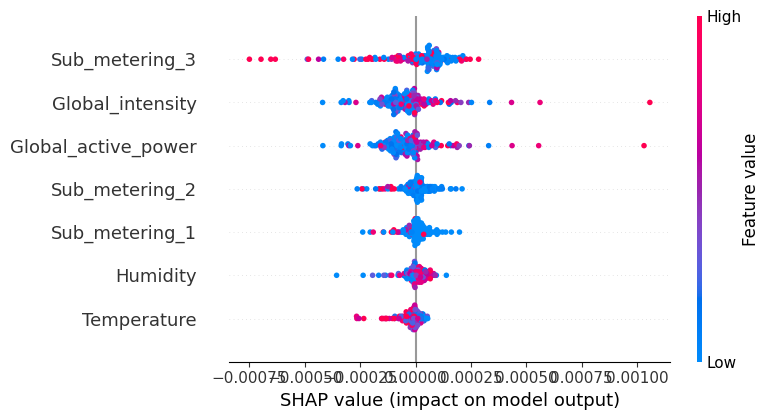

Force plot (target output index: 0)


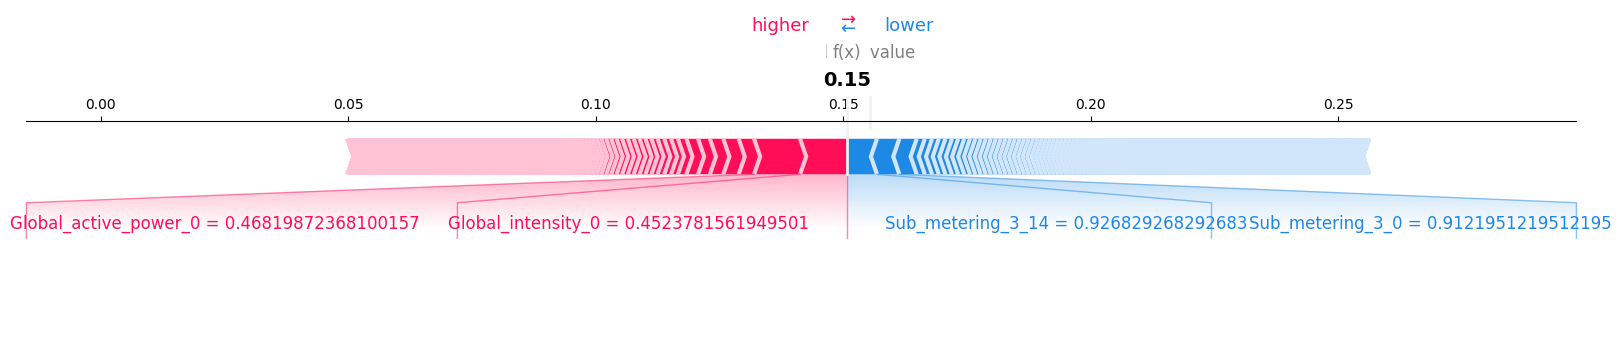

Waterfall plot (target output index: 0)


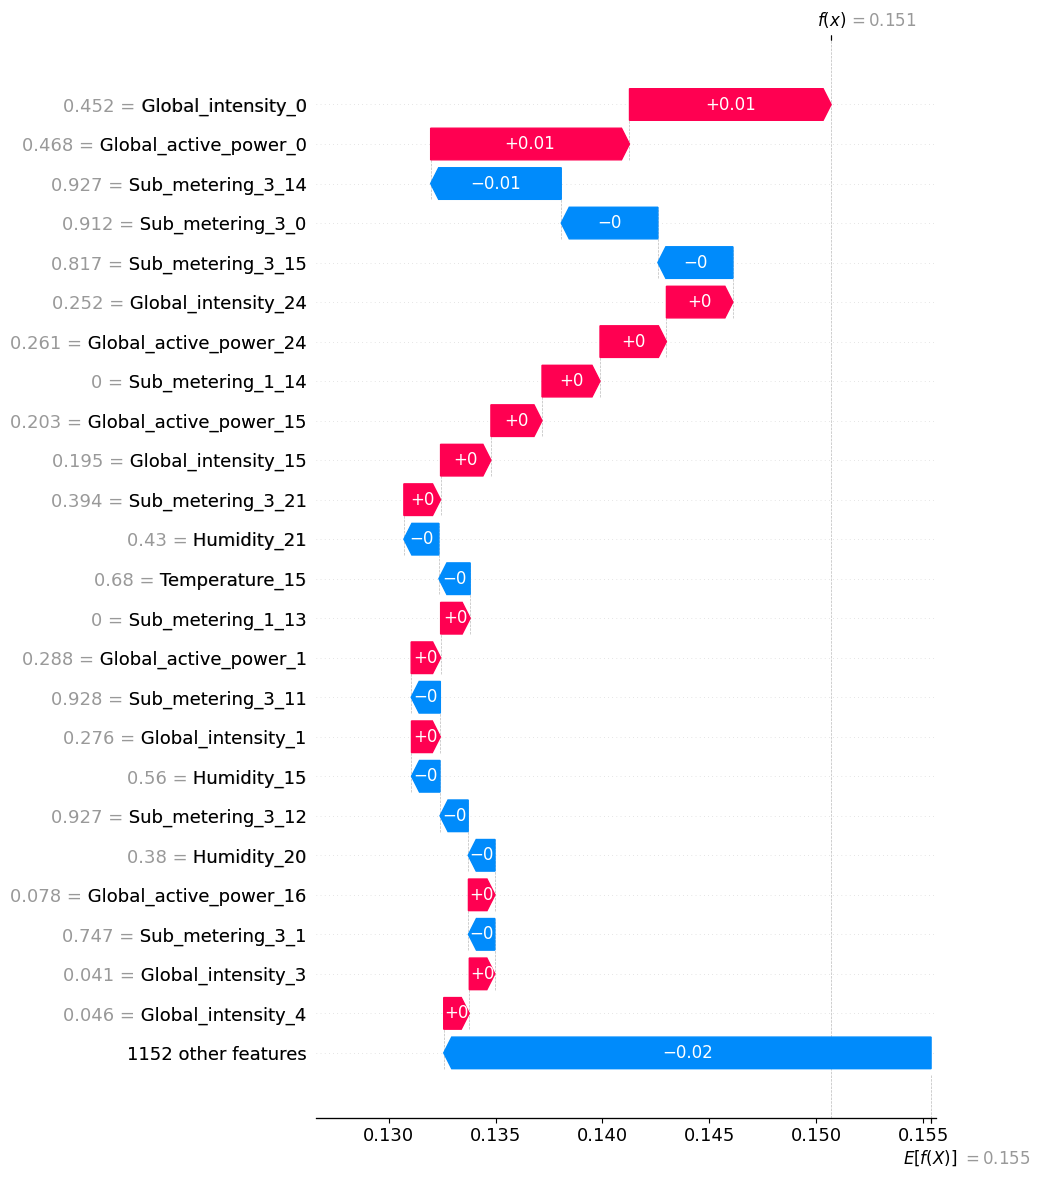

Dependence plot (target output index: 0)


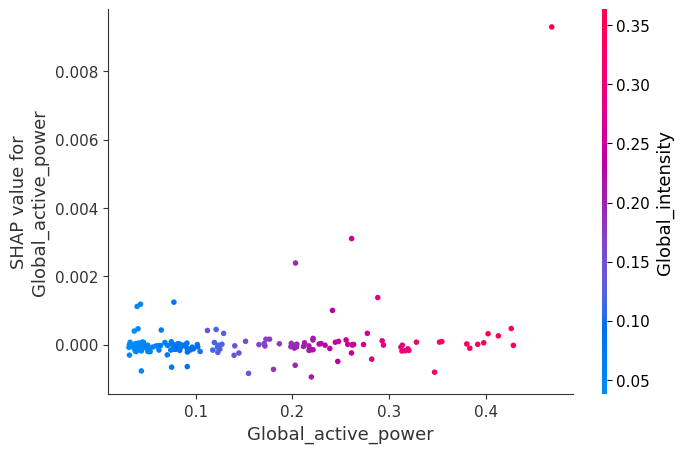

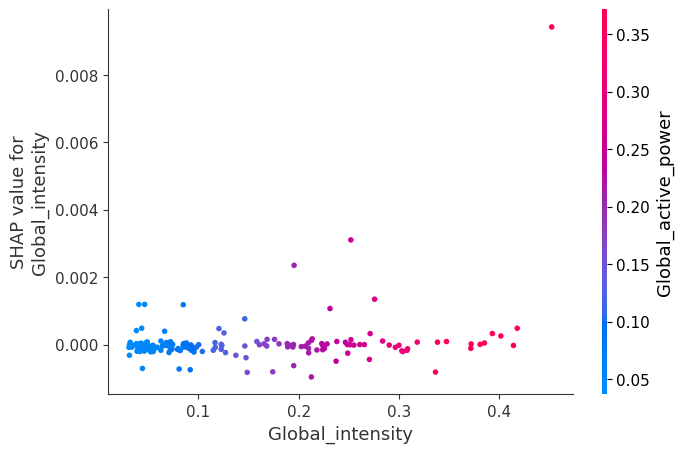

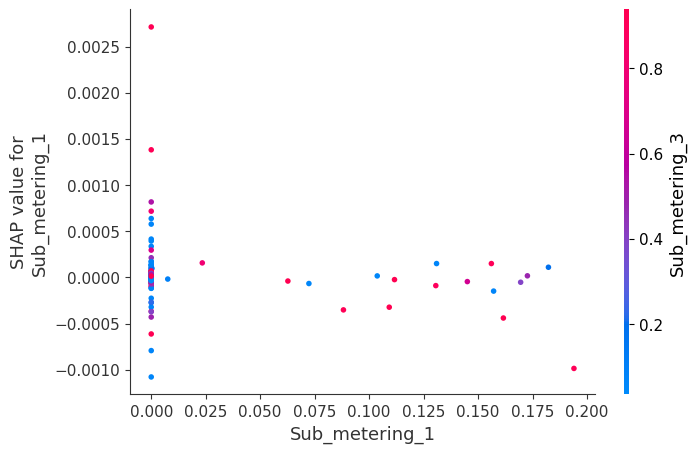

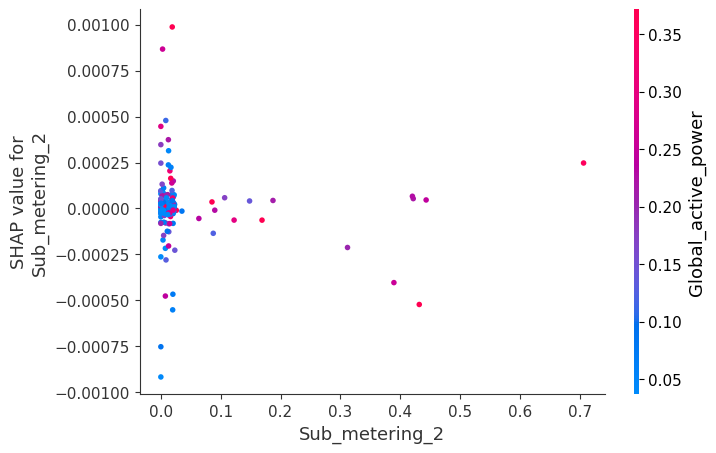

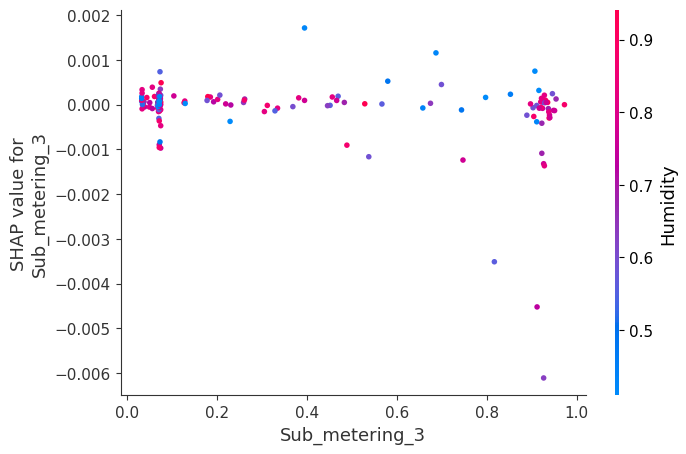

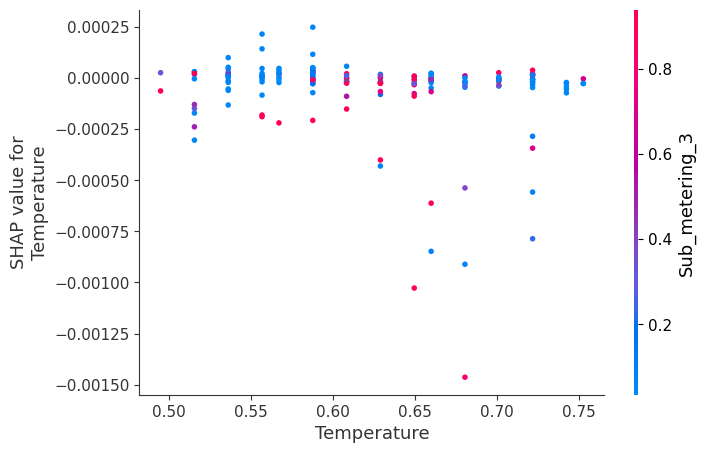

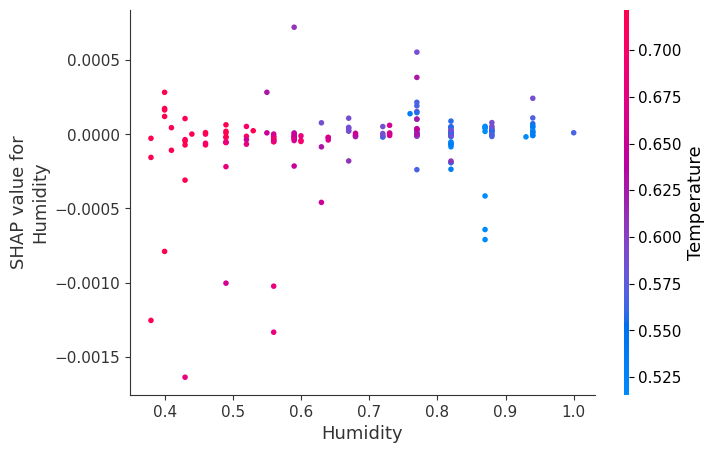

Decision plot (target output index: 0)


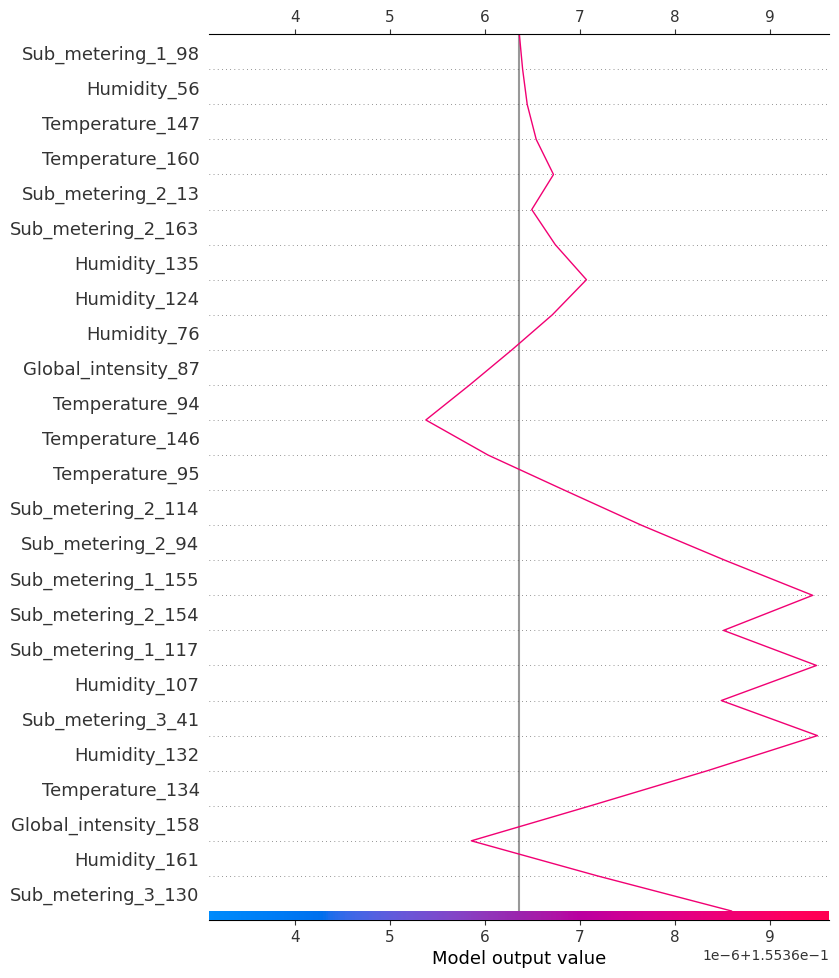

Scatter plot (target output index: 0)


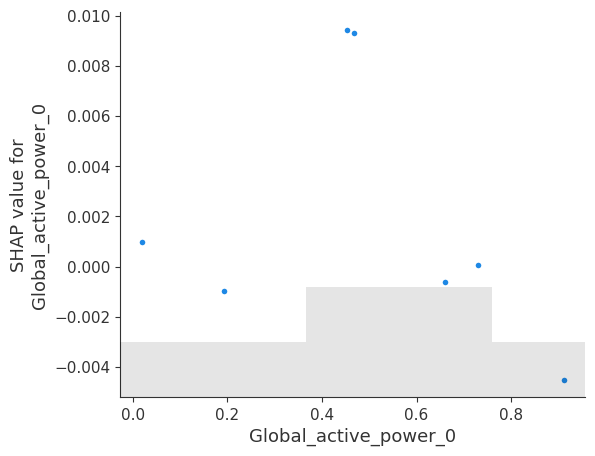

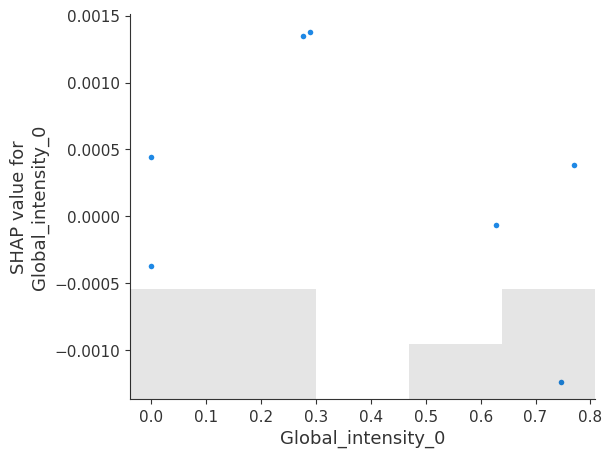

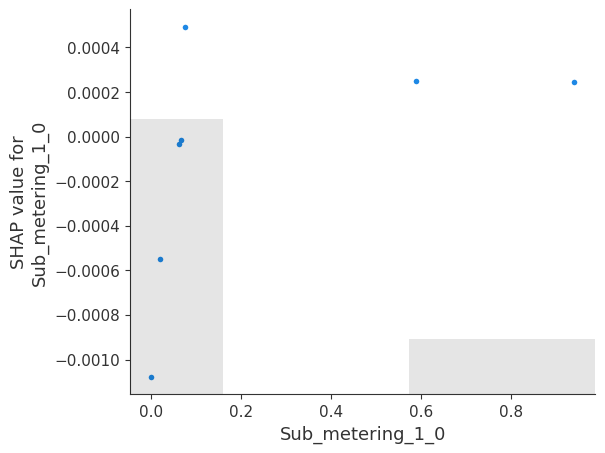

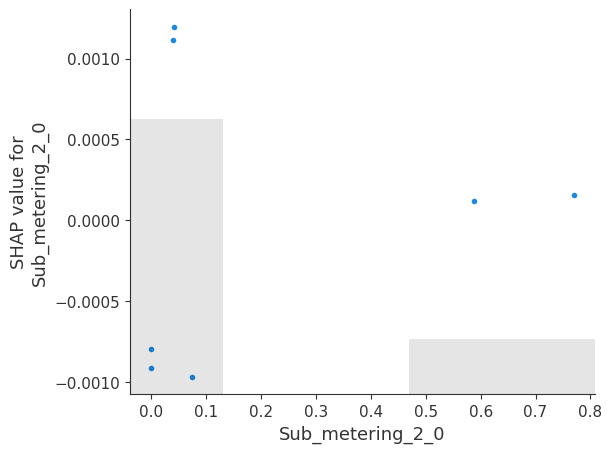

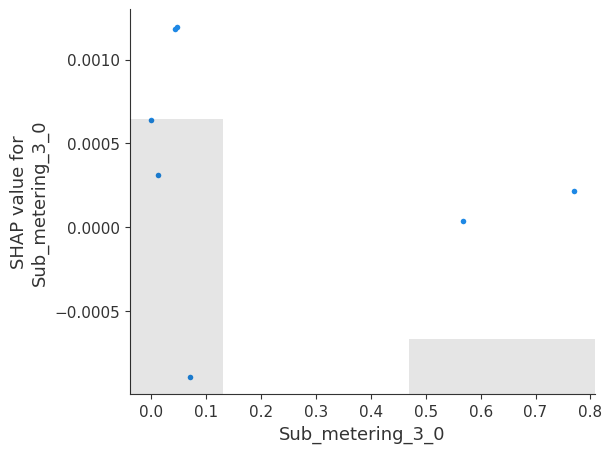

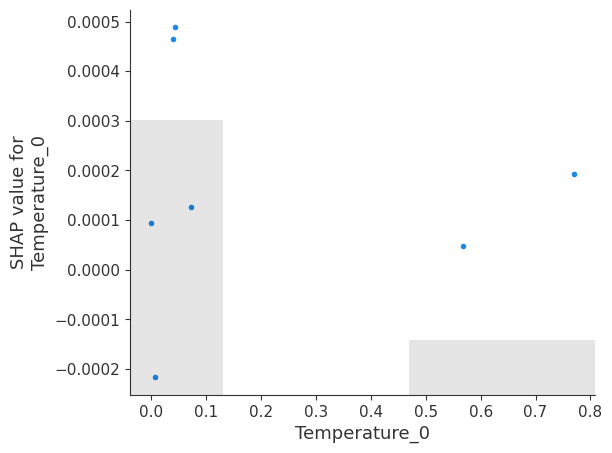

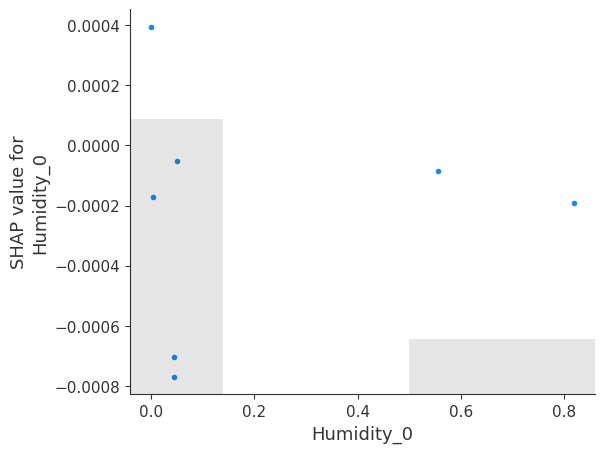

Bar plot


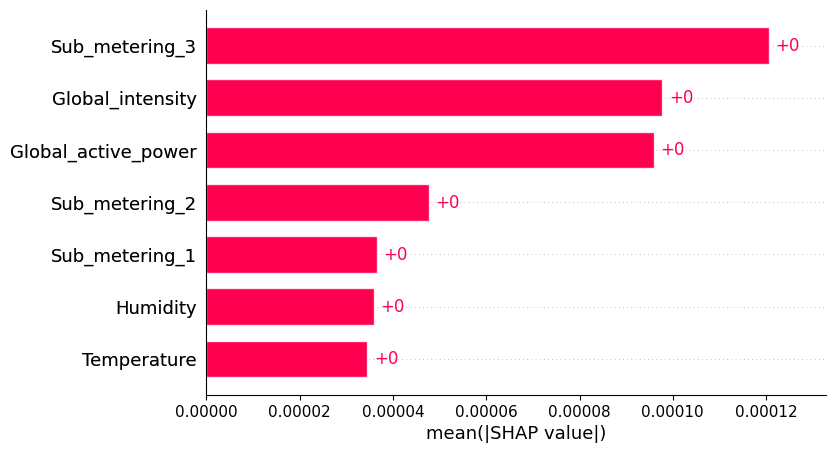

Beeswarm plot


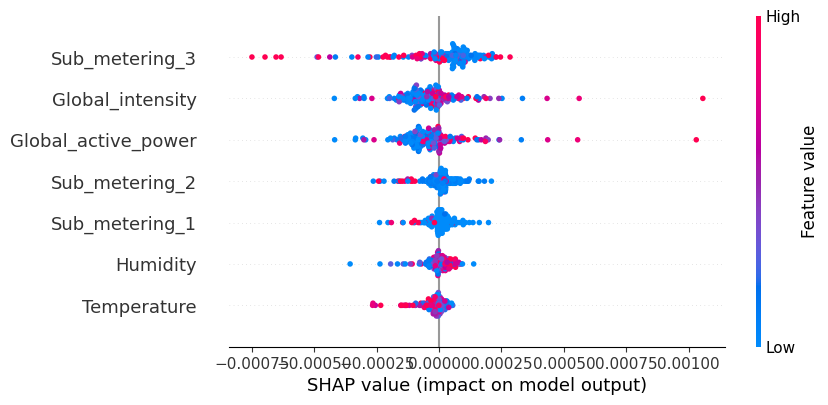

Heatmap plot


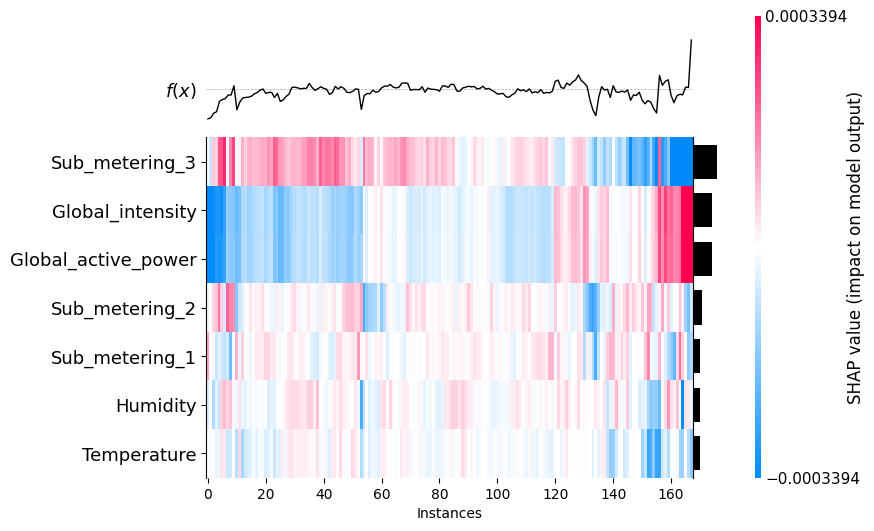

Partial Dependence Plot (feature: Global_active_power, target output index)


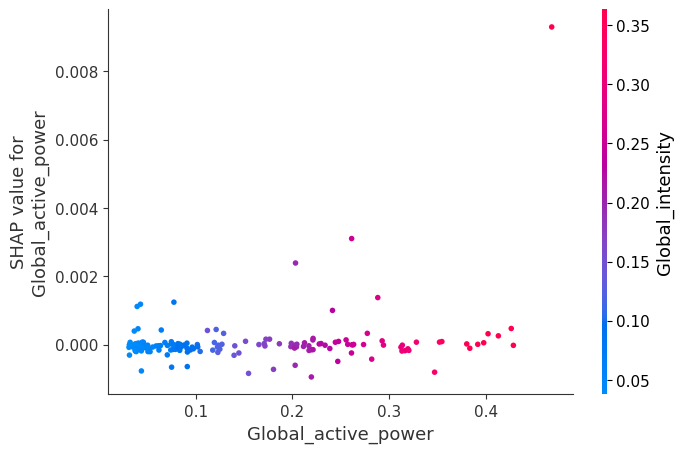

In [73]:
num_samples = 1
shap_values, sampled_eval_sequences = explainer.explain_DeepExplainer(eval_sequences, 
                                                                      num_samples=num_samples)
explainer.visualize_all_one_sample(shap_values[0], 
                                   sampled_eval_sequences[0], 
                                   target_f_idx1=0,
                                   target_f_idx2=1,
                                   target_idx=0)

target_feature_1:  Global_active_power
target_feature_2:  Sub_metering_3
SHAP Value Correlation Plot


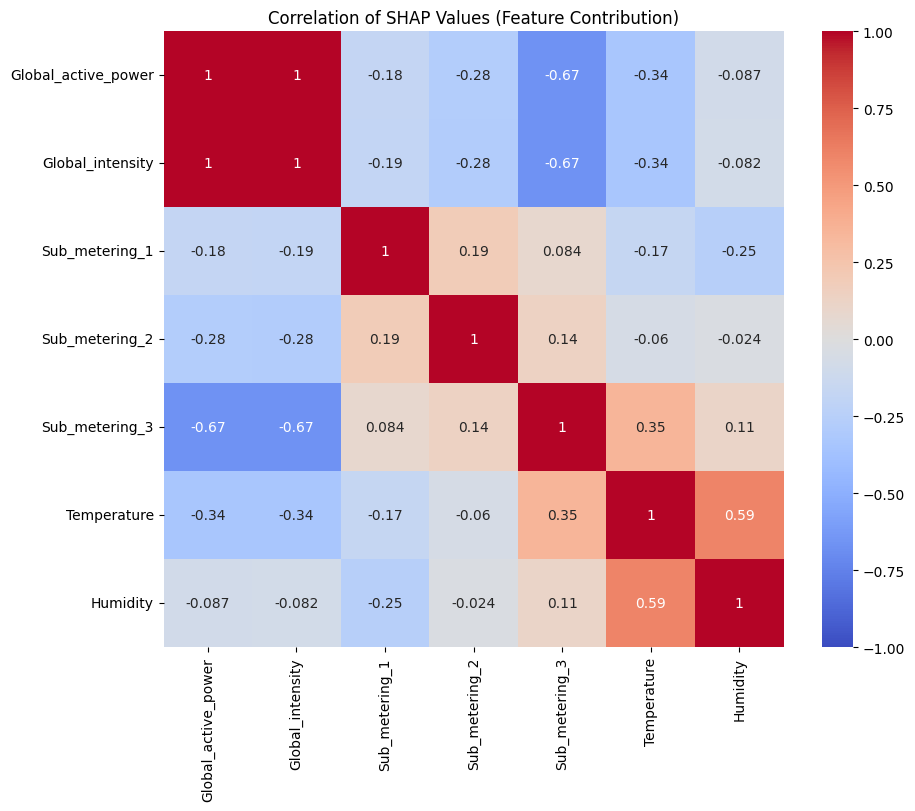

In [74]:
target_feature_1 = dataset.selected_features[0]
target_feature_2 = dataset.selected_features[4]

print('target_feature_1: ', target_feature_1)
print('target_feature_2: ', target_feature_2)


### feature간 shap_value 상관관계 분석
### 현재 출력이 24개이기때문에, 
### 각 아웃풋 1개마다 상관관계 계산 후 24개 평균 
###    or 24개 아웃풋의 평균에 대한 상관관계 계산으로 나뉨 
### 우선 두번째 방법으로 
explainer.visualize_correlation(shap_values[0], sampled_eval_sequences[0], 
                                target_feature_1, target_feature_2)

In [75]:
num_samples_shap = 200  # 여러 샘플을 사용하여 일반화된 분석 시도

shap_values, sampled_eval_sequences = explainer.explain_DeepExplainer(eval_sequences,
                                                                      num_samples=num_samples_shap)

/archive/library/anaconda3/envs/xai/lib/python3.11/site-packages/shap/explainers/_deep/deep_pytorch.py:243: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f'unrecognized nn.Module: {module_type}')


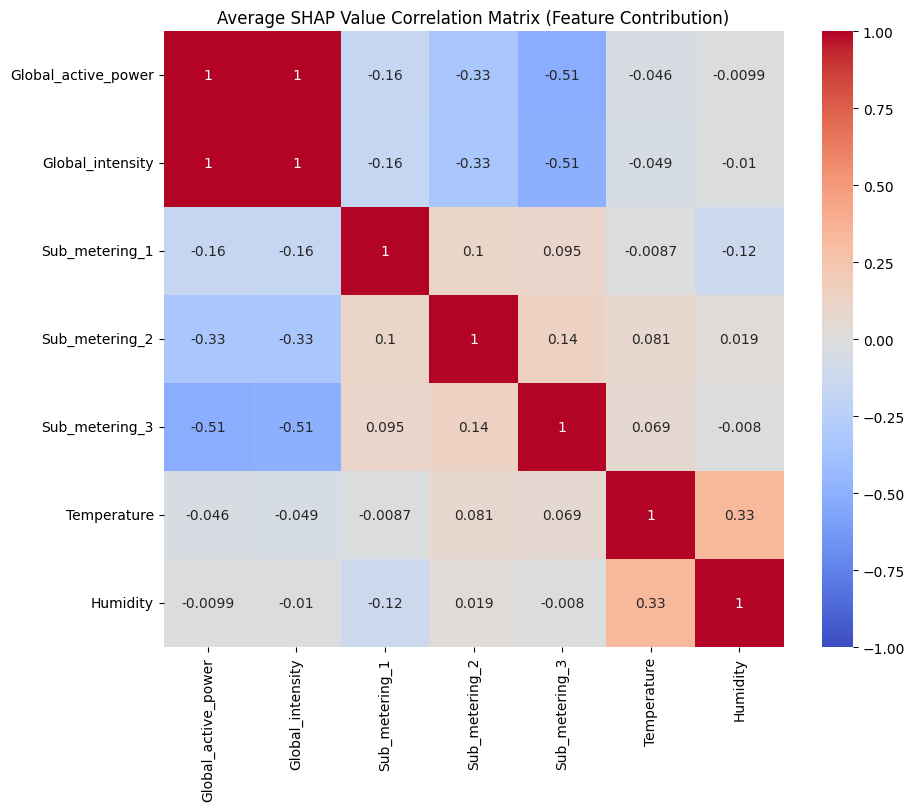

In [76]:
explainer.visualize_correlation_multiple_samples(shap_values)

**주요 feature 추출**

In [77]:
shap_top_features = explainer.extract_important_features(shap_values)
important_features_dict[explainer_type] = shap_top_features

Top 5 important features based on SHAP values:
Top 1: Temperature (Importance: 0.0002809502406614652)
Top 2: Global_intensity (Importance: 0.0002446734254410817)
Top 3: Humidity (Importance: 0.00023211621551820749)
Top 4: Sub_metering_1 (Importance: 0.00021127048619500415)
Top 5: Global_active_power (Importance: 0.00020966898322778298)


### 3-3. Attention
**시각화**

- 현재 입력 sequences가 너무 길어 시각화하는 의미가 없어짐 -> 방법 고민 필요
- 주요 feature의 경우, 각 샘플에 대해서 attention weights를 뽑고, attention weight가 가장 높은 timestep의 feature를 선택 -> N개의 샘플에 대해서 반복해서 가장 빈도가 높은 feature를 주요 feature로 선정

In [36]:
# Attention explainer 정의
explainer_type = 'Attention' 
explainer = get_explainer(explainer_type=explainer_type, 
                          model=model, device=device, 
                          train_sequences=train_sequences, 
                          sequence_length=sequence_length,
                          input_size=input_size,
                          selected_features=dataset.selected_features, 
                          scaler=dataset.scaler)

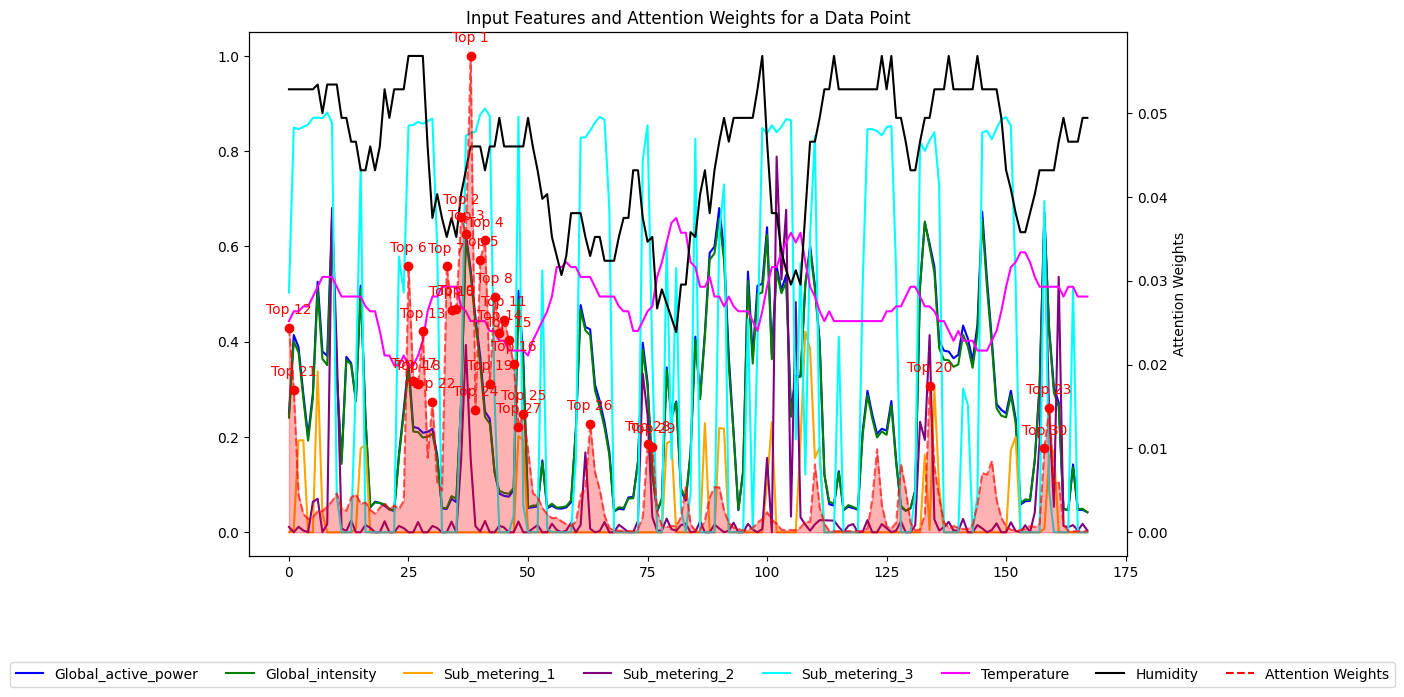

Prediction for the data point: tensor([[0.0949, 0.3192, 0.2152, 0.1930, 0.2180, 0.1133, 0.1353, 0.0703, 0.0634,
         0.2612, 0.2763, 0.3055, 0.4155, 0.4794, 0.6119, 0.3315, 0.4075, 0.4237,
         0.3111, 0.3660, 0.3548, 0.3715, 0.3561, 0.3751]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
Top 30 time steps with highest attention weights:
Top 1 - Time step 38: Attention Weight = 0.05680849775671959
  Global_active_power: 0.5514439882936347
  Global_intensity: 0.5404580152671755
  Sub_metering_1: 0.0
  Sub_metering_2: 0.15541995692749463
  Sub_metering_3: 0.8382113821138212
  Temperature: 0.44329896907216493
  Humidity: 0.81
Top 2 - Time step 36: Attention Weight = 0.037564340978860855
  Global_active_power: 0.2709434192342086
  Global_intensity: 0.26952436876101
  Sub_metering_1: 0.0
  Sub_metering_2: 0.1503948312993539
  Sub_metering_3: 0.28536585365853656
  Temperature: 0.4742268041237113
  Humidity: 0.71
Top 3 - Time step 37: Attention Weight = 0.035566721111536026
  Glob

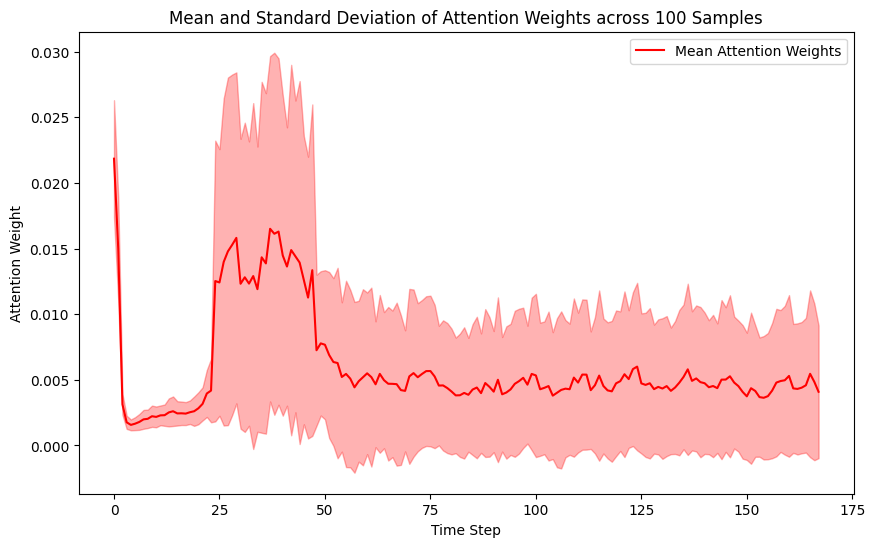

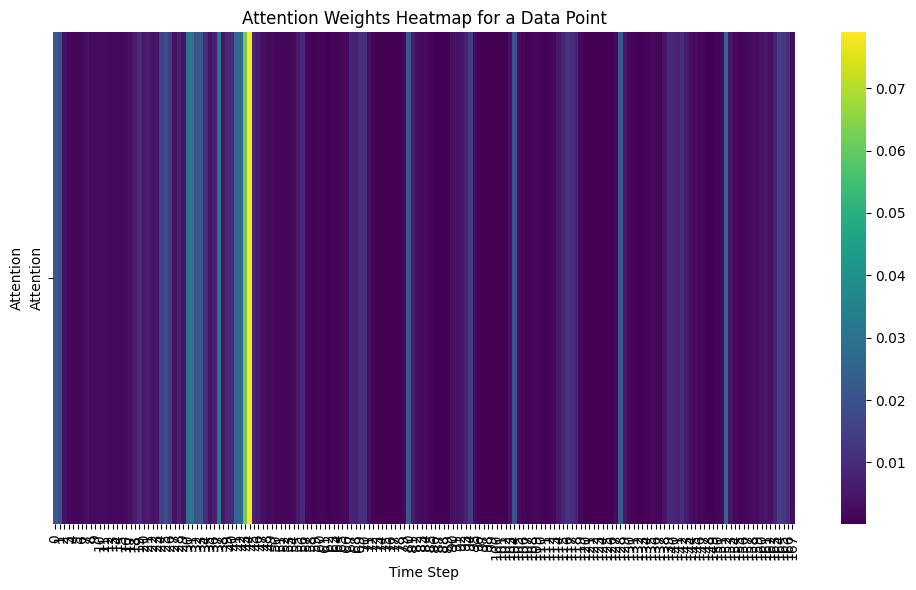

Prediction for the data point: tensor([[0.2280, 0.2437, 0.1622, 0.0569, 0.0707, 0.0662, 0.2707, 0.3058, 0.2309,
         0.2311, 0.1338, 0.0785, 0.0991, 0.2393, 0.0869, 0.0901, 0.1026, 0.2754,
         0.4216, 0.7715, 0.7794, 0.2368, 0.1077, 0.0683]], device='cuda:0',
       grad_fn=<AddmmBackward0>)


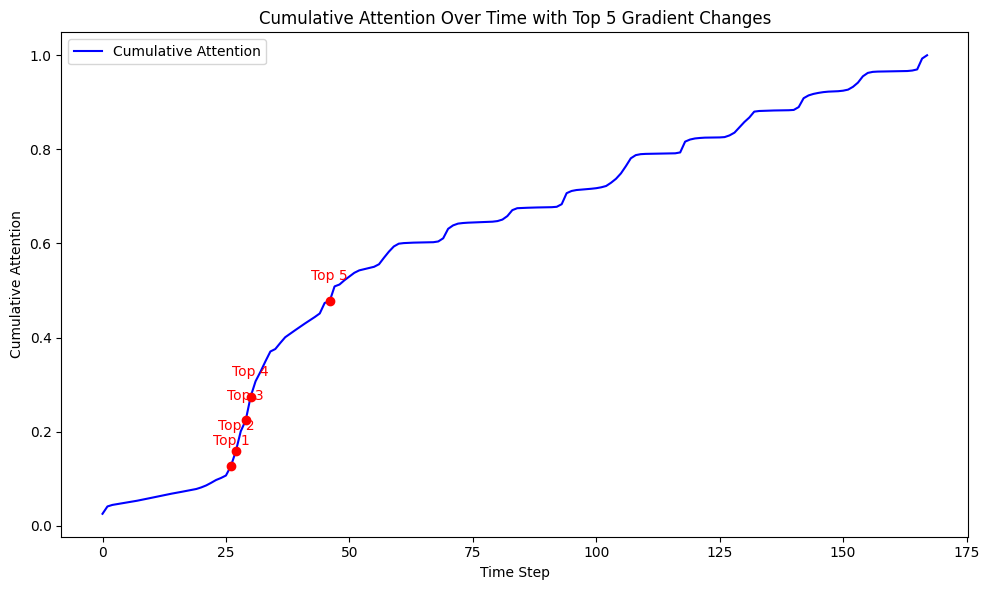

Prediction for the data point: tensor([[0.0683, 0.0792, 0.2083, 0.3273, 0.4283, 0.3243, 0.4880, 0.3387, 0.2287,
         0.2266, 0.1985, 0.0806, 0.1075, 0.0865, 0.0563, 0.0439, 0.0415, 0.0411,
         0.0344, 0.0346, 0.0586, 0.1446, 0.0518, 0.2315]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
Top 5 steps with largest gradient changes:
Top 1 - Time step 26: Gradient Change = 0.01992151141166687
  Global_active_power: 0.22976282416063734
  Global_intensity: 0.22301820317087492
  Sub_metering_1: 0.0
  Sub_metering_2: 0.09009332376166547
  Sub_metering_3: 0.7439024390243902
  Temperature: 0.7216494845360825
  Humidity: 0.49
Top 2 - Time step 27: Gradient Change = 0.03155431151390076
  Global_active_power: 0.2942545321518576
  Global_intensity: 0.2903112155020552
  Sub_metering_1: 0.1450723638869745
  Sub_metering_2: 0.12239770279971285
  Sub_metering_3: 0.6577235772357723
  Temperature: 0.7525773195876289
  Humidity: 0.44
Top 3 - Time step 29: Gradient Change = 0.023187696933746338

In [37]:
attention_top_n = 30

# random smaple 하나에 대해서 attention weight 시각화
explainer.visualize_attention(n=attention_top_n) 

# n개 sample에 대해서 attention weight 분포 시각화
explainer.analyze_attention_distribution(num_samples=100)

# attention heatmap 시각화
explainer.visualize_attention_heatmap()

explainer.visualize_cumulative_attention(num_points=top_n)

**주요 feature 추출**

In [38]:
attention_top_features = explainer.extract_important_features(num_samples=num_samples, 
                                                              top_n=top_n)

Extracting important features: 100%|████████████████████████████████████████████████| 1/1 [00:00<00:00, 218.48sample/s]


Top 5 important features:
Top 1: Humidity (Importance: 0.1192)
Top 2: Temperature (Importance: 0.0861)
Top 3: Sub_metering_3 (Importance: 0.0689)
Top 4: Global_active_power (Importance: 0.0496)
Top 5: Global_intensity (Importance: 0.0485)


In [39]:
important_features_dict[explainer_type] = attention_top_features

### 3-4. Grad-CAM 

Grad-CAM도 마찬가지로 hidden layer에서 만들어진 vector에 대해 각 입력 timestep별로 기여도를 추출 

**시각화**

In [40]:
# LIME explainer 정의
explainer_type = 'GRAD_CAM' 
explainer = get_explainer(explainer_type=explainer_type, 
                          model=model, device=device, 
                          train_sequences=train_sequences, 
                          sequence_length=sequence_length,
                          input_size=input_size,
                          selected_features=dataset.selected_features, 
                          scaler=dataset.scaler)

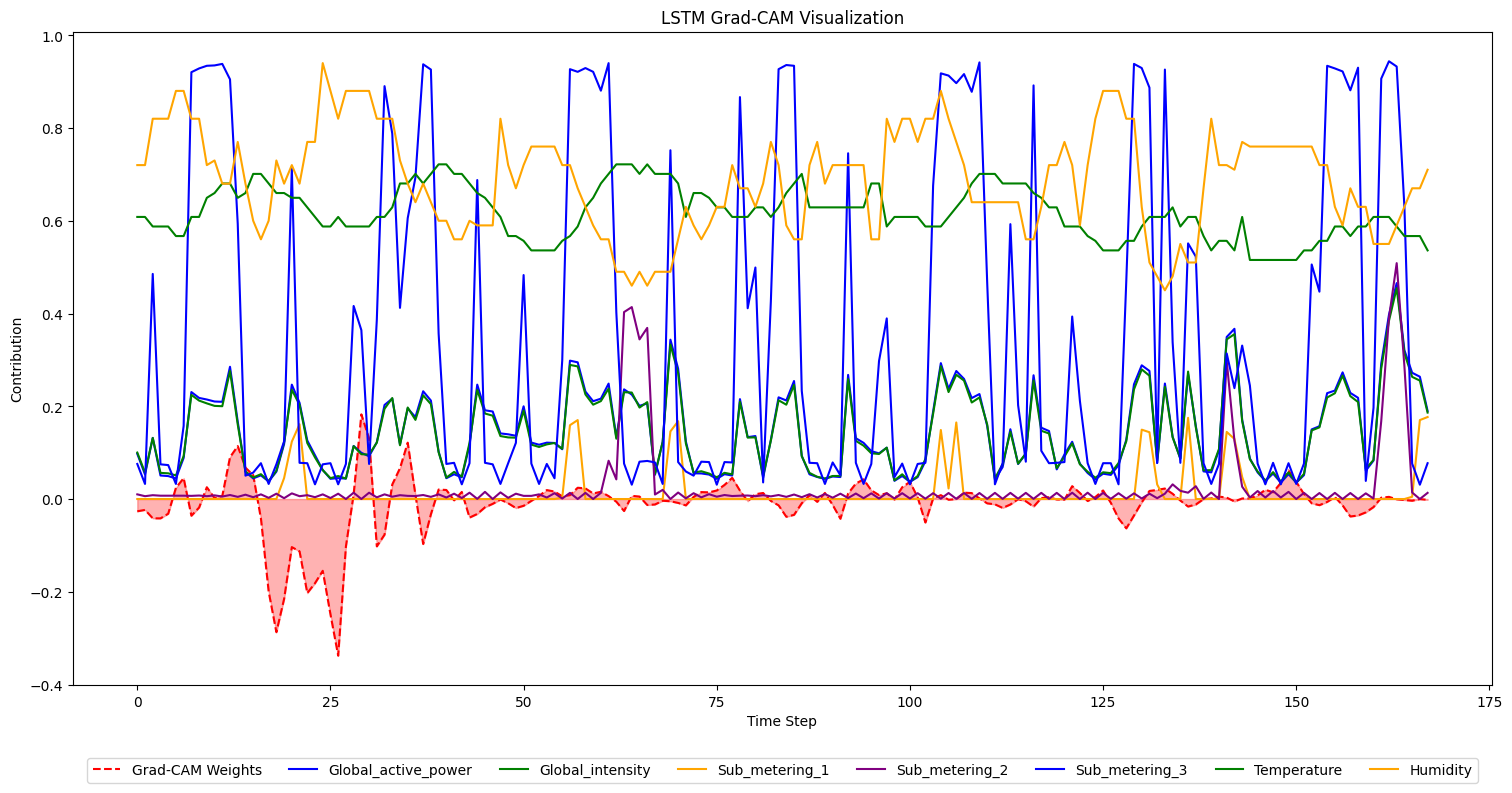

In [41]:
data_point = eval_sequences[np.random.choice(len(eval_sequences))]

grad_cam_weights = explainer.compute_grad_cam(data_point)
explainer.visualize_grad_cam(grad_cam_weights, data_point, dataset.selected_features)

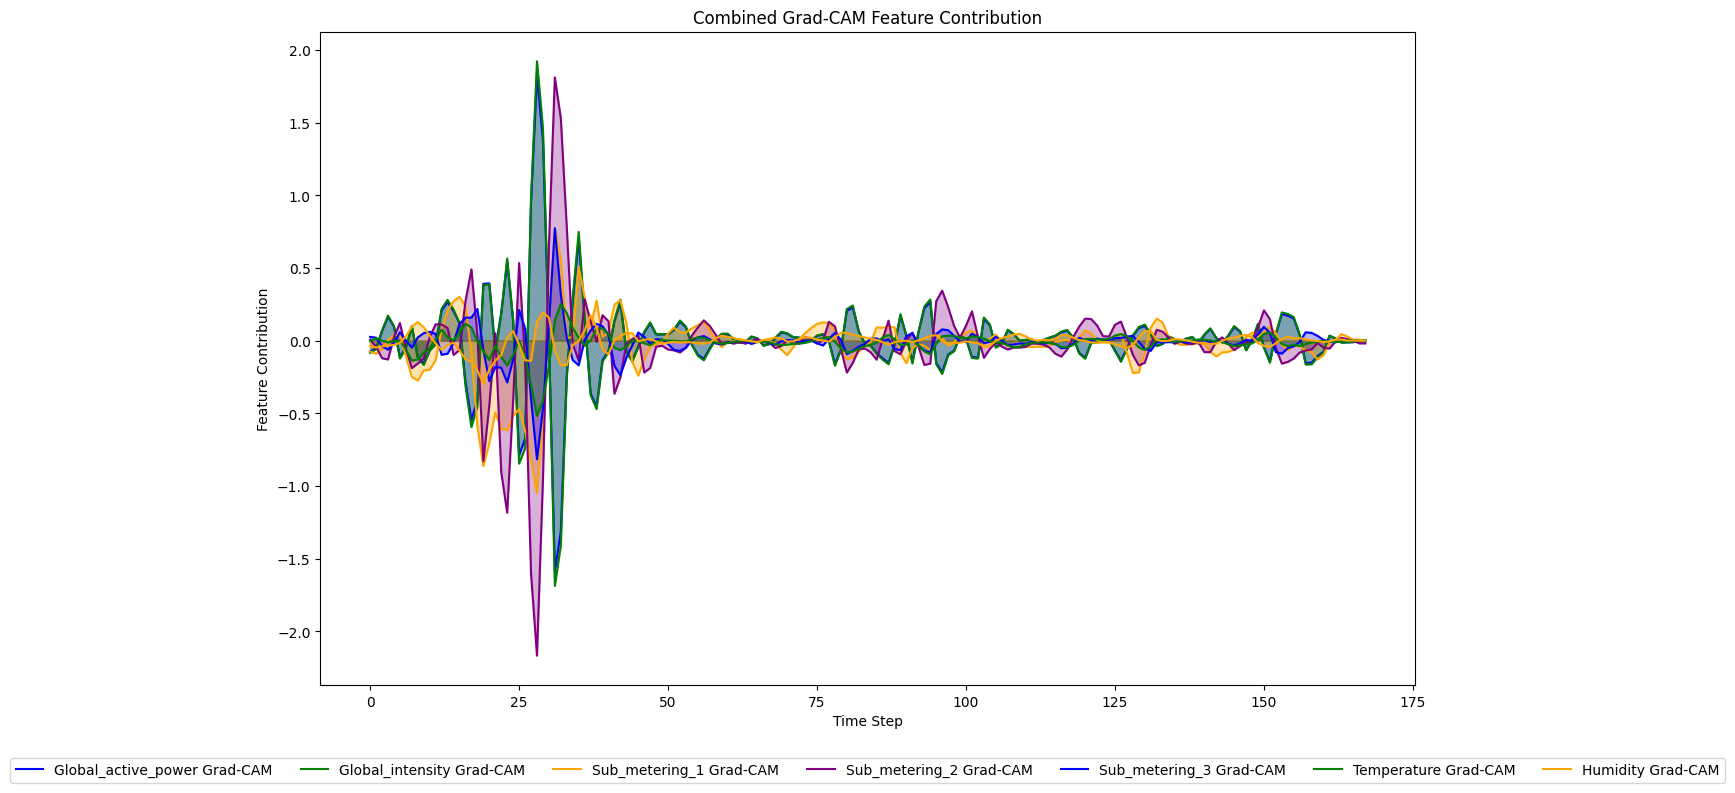

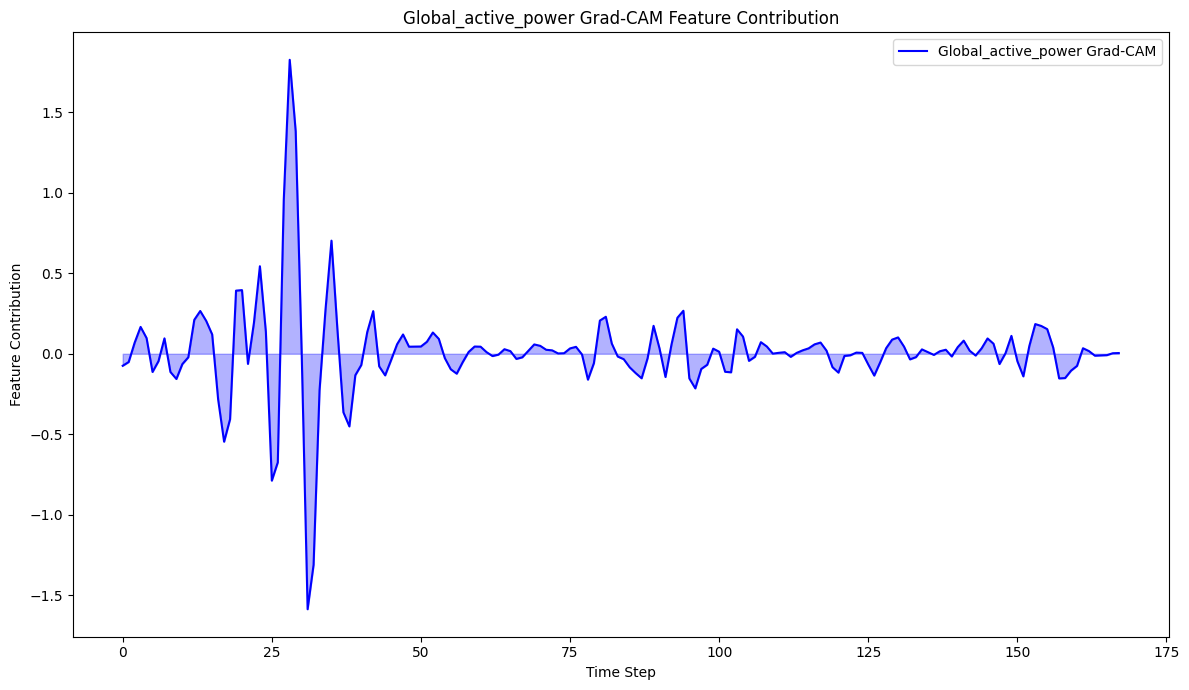

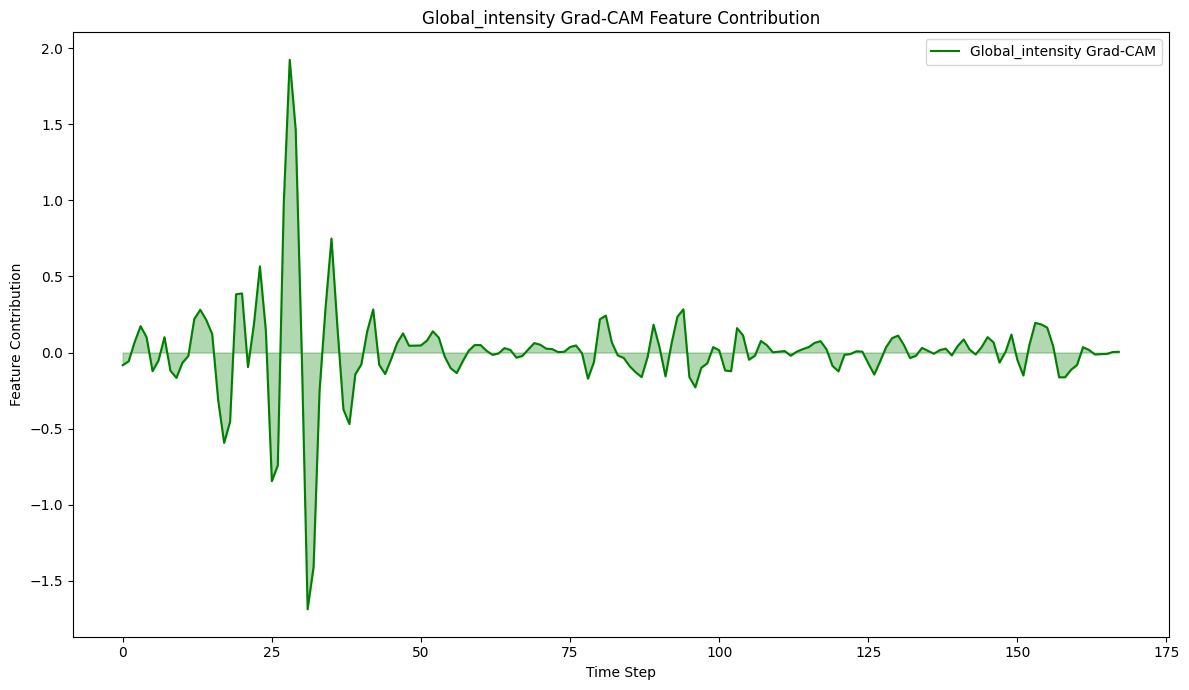

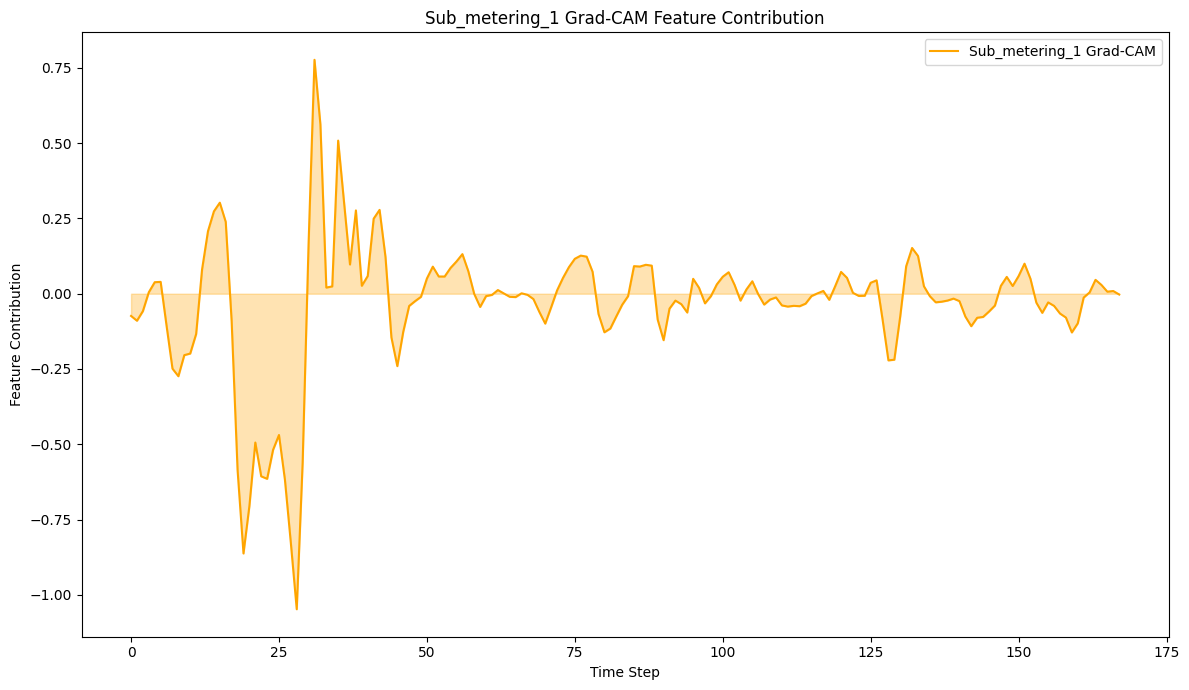

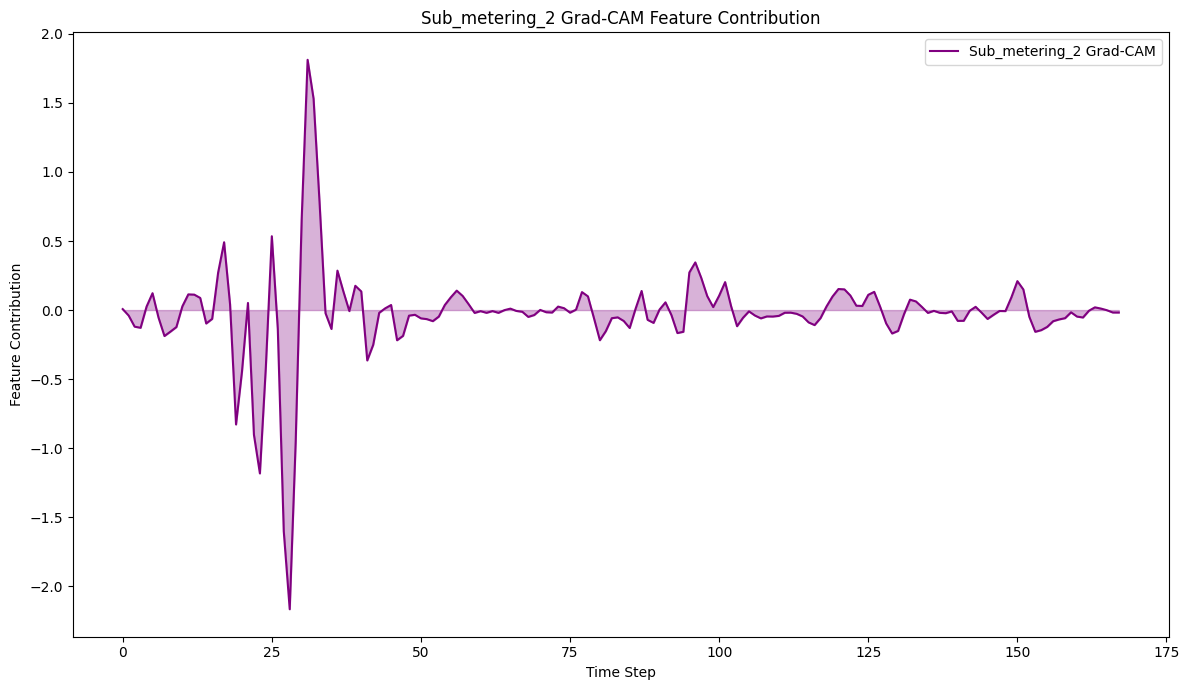

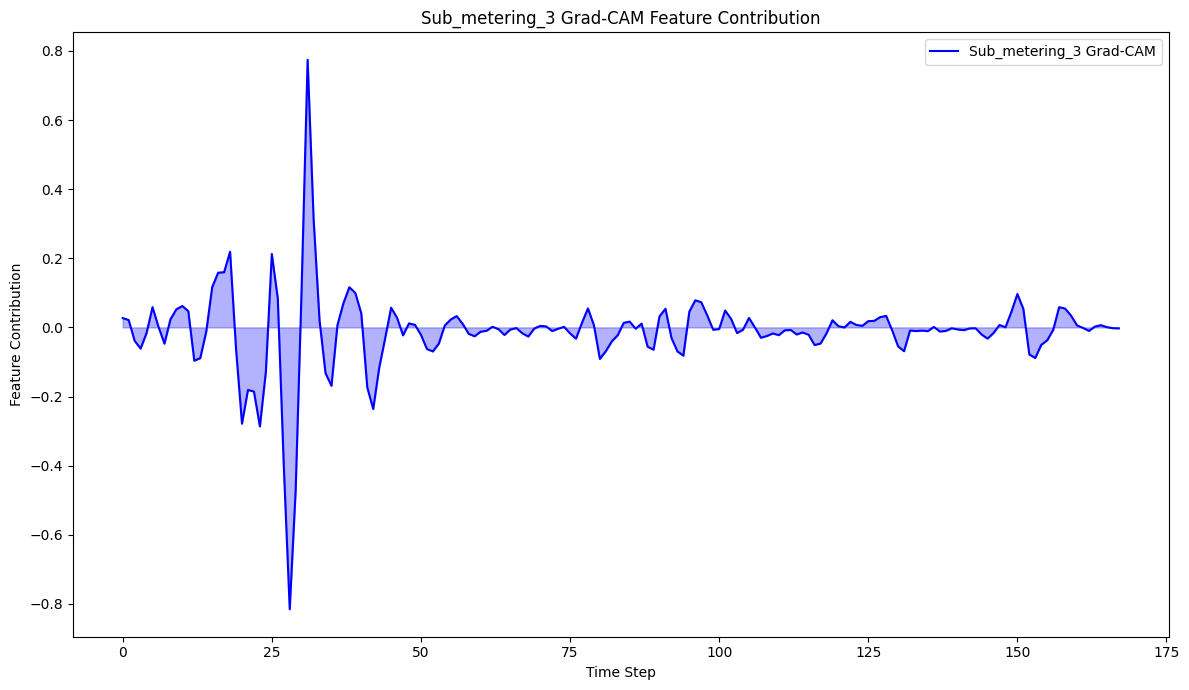

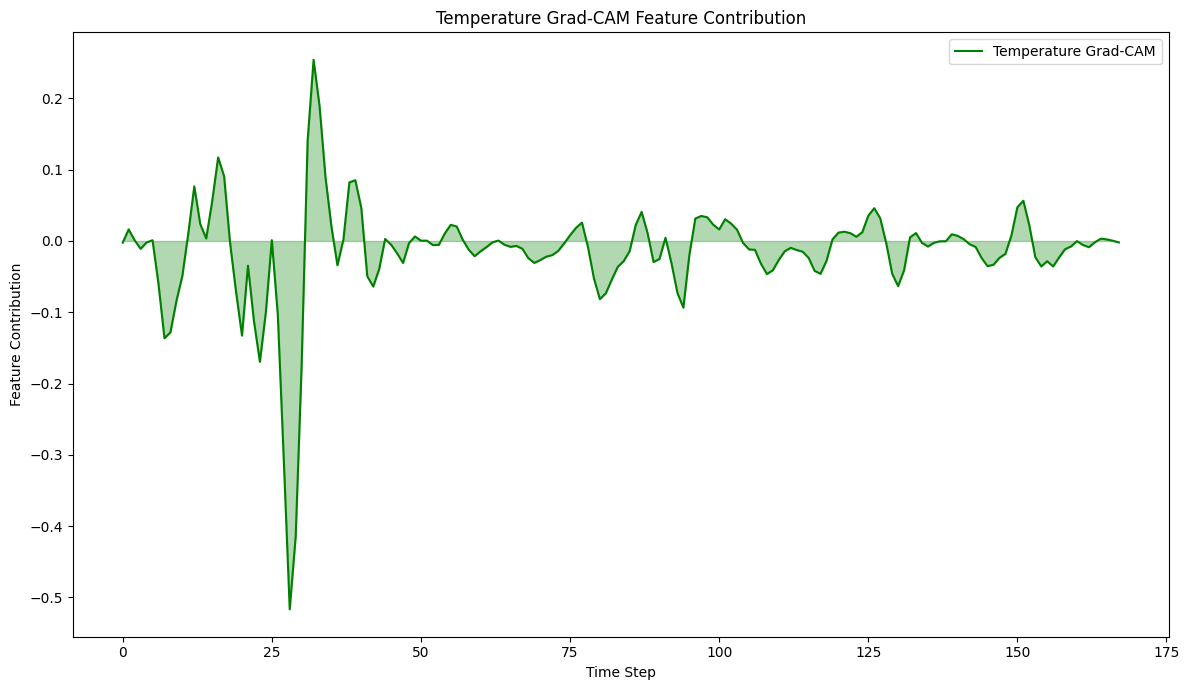

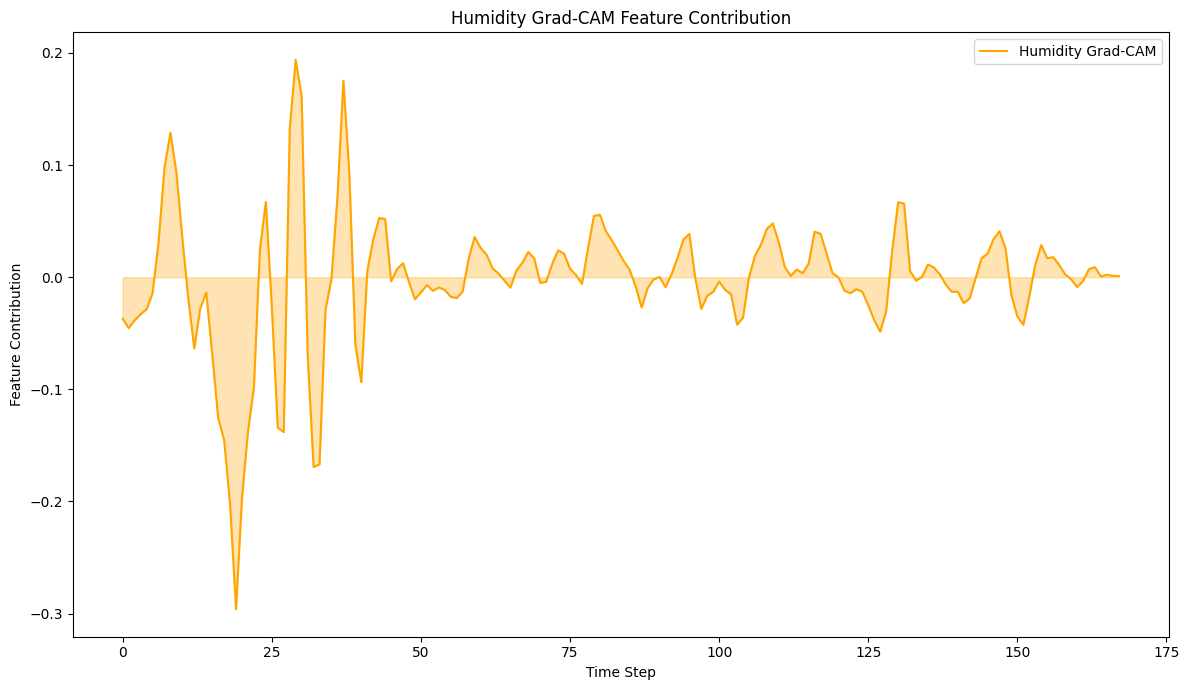

In [42]:
grad_cam_weights_per_feature = explainer.compute_grad_cam_per_feature(data_point)
explainer.visualize_grad_cam_per_feature(grad_cam_weights_per_feature, 
                                         data_point, dataset.selected_features)

In [44]:
gradcam_top_features = explainer.extract_important_features(num_samples=num_samples, 
                                                            top_n=top_n)

Extracting important features with Grad-CAM...


Processing samples: 100%|████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 39.32it/s]

Top 5 important features based on SHAP values:
Top 1: Sub_metering_2 (Importance: 0.13282868266105652)
Top 2: Sub_metering_1 (Importance: 0.11338106542825699)
Top 3: Global_intensity (Importance: 0.1074066013097763)
Top 4: Global_active_power (Importance: 0.10084765404462814)
Top 5: Sub_metering_3 (Importance: 0.044602811336517334)


In [45]:
important_features_dict[explainer_type] = gradcam_top_features

**최종 주요 feature 추출**

- 각 방법론별 importance 값을 정규화함
- 각 방법론별 중요도/가중치는 논의 후 반영 (현재는 동일 가중치)

In [46]:
"""
    explainers.utils.py 로 옮길 예정
"""

def normalize(values):
    min_val, max_val = min(values), max(values)
    return [(v - min_val) / (max_val - min_val) if max_val > min_val else 0 for v in values]

def get_top_features(methods):
    """
    최종 5개의 feature와 합산된 중요도를 반환하는 함수
    :param methods: 각 방법론의 feature 중요도를 포함한 딕셔너리
                    {"method_name": {"feature_name": importance, ...}, ...}
    :return: 최종 Top 5 feature와 중요도 합산 딕셔너리
    """
    # 각 방법론의 정규화된 중요도 값을 담을 딕셔너리
    normalized_importances = {}

    # 각 방법론의 중요도 값 정규화 및 합산
    for method_name, features in methods.items():
        importances = list(features.values())
        norm_importances = normalize(importances)

        for (feature, _), norm_imp in zip(features.items(), norm_importances):
            if feature in normalized_importances:
                normalized_importances[feature] += norm_imp
            else:
                normalized_importances[feature] = norm_imp

    # 합산된 중요도 값으로 상위 5개 feature를 추출
    top_features = sorted(normalized_importances.items(), key=lambda x: x[1], reverse=True)[:5]

    # 최종 결과 반환
    return {feature: importance for feature, importance in top_features}

In [101]:
top_5_features = get_top_features(important_features_dict)
# print(top_5_features)

# importance 값을 어떻게 활용하지?
important_features = list(top_5_features.keys())
print('final important featurs: ')
important_features

final important featurs: 


['Sub_metering_1',
 'Temperature',
 'Global_intensity',
 'Humidity',
 'Global_active_power']

In [102]:
feature_abbreviations = {
    'Global_active_power': 'GA',
    'Global_intensity': 'GI',
    'Sub_metering_1': 'SM1',
    'Sub_metering_2': 'SM2',
    'Sub_metering_3': 'SM3',
    'Humidity': 'HV',
    'Temperature': 'TV'
}
abbreviated_features = [feature_abbreviations[feature] for feature in important_features]

In [103]:
sequence_length/24

7.0

## 4. Re-train model with important features

앞서 추출한 주요 feature (top_N)에 대해서 모델 재학습 

In [ ]:
important_features

In [ ]:
important_features_for_long = []
important_features_for_short = []

for feature_long in important_features['long']:
    important_features_for_long.append(feature_long[0])
print(important_features_for_long)

for feature_short in important_features['short']:
    important_features_for_short.append(feature_short[0])
print(important_features_for_short)

In [ ]:
def load_dataset_new_features(params, is_long_term_forecast=True):
    selected_features = dict()
    
    if is_long_term_forecast:
        dataset_6h = EPCDataset(
            file_path=file_path_for_1h,
            sequence_length=params['long_term_length'],  
            prediction_length=params['long_term_pred_length'],
            target_features=important_features_for_long
        )
        train_long, train_targets_long, eval_long, eval_targets_long = dataset_6h.load_data()
        
        dataset_1h = EPCDataset(
            file_path=file_path_for_1h,
            sequence_length=params['short_term_length'],  
            prediction_length=params['short_term_pred_length'],
            target_features=important_features_for_short
        )
        train_short, train_targets_short, eval_short, eval_targets_short = dataset_1h.load_data()
        
        train_data=(train_long, train_short)
        train_targets=(train_targets_long, train_targets_short)
        eval_data=(eval_long, eval_short)
        eval_targets=(eval_targets_long, eval_targets_short)

        selected_features['long'] = dataset_6h.selected_features
        selected_features['short'] = dataset_1h.selected_features

    else:
        dataset_1h = EPCDataset(
            file_path=file_path_for_1h,
            sequence_length=params['sequence_length'],  
            prediction_length=params['prediction_length'],
            target_features=important_features_for_1h
        )
        
        train_sequence, train_targets_sequence, eval_sequence, eval_targets_sequence = dataset_1h.load_data()

        train_data=train_sequence
        train_targets=train_targets_sequence
        eval_data=eval_sequence
        eval_targets=eval_targets_sequence
    
        selected_features['single'] = dataset_1h.selected_features

    return train_data, train_targets, eval_data, eval_targets, selected_features

In [ ]:
is_long_term_forecast = True

train_data, train_targets, eval_data, eval_targets, selected_features = load_dataset_new_features(params=dataset_params,
                                                                                                  is_long_term_forecast=True)

if isinstance(train_data, tuple):
    print("6-hour data sequences for long-term forecast:")
    print(f"  Train sequences shape: {train_data[0].shape}")
    print(f"  Train targets shape: {train_targets[0].shape}")
    print(f"  Eval sequences shape: {eval_data[0].shape}")
    print(f"  Eval targets shape: {eval_targets[0].shape}")
    print(f"  Selected_features: {selected_features['long']}")
    
    print("\n1-hour data sequences for long-term forecast:")
    print(f"  Train sequences shape: {train_data[1].shape}")
    print(f"  Train targets shape: {train_targets[1].shape}")
    print(f"  Eval sequences shape: {eval_data[1].shape}")
    print(f"  Eval targets shape: {eval_targets[1].shape}")
    print(f"  Selected_features: {selected_features['short']}")
    
else:
    print("1-hour data sequences for short-term forecast:")
    print(f"  Train sequences shape: {train_data.shape}")
    print(f"  Train targets shape: {train_targets.shape}")
    print(f"  Eval sequences shape: {eval_data.shape}")
    print(f"  Eval targets shape: {eval_targets.shape}")
    print(f"  Selected_features: {selected_features['single']}")

In [ ]:
def load_trained_model(params):
    if params is None:
        return

    # Extract parameters
    model_name = params['model_name']
    hidden_size = params['hidden_size']
    num_layers = params['num_layers']
    dropout = params['dropout']
    num_epochs = params['num_epochs']
    batch_size = params['batch_size']
    learning_rate = params['learning_rate']
    patience = params['patience']
    mse_decay = params['mse_decay']

    # Determine input size and output size
    input_size = {
        # 'long': len(important_features_for_6h)+6,
        'long': len(important_features_for_long)+6,
        'short': len(important_features_for_short)+6,
        'single': len(important_features_for_short)+6
    }
    output_size = {
        'long': dataset_params['long_term_pred_length'],
        'short': dataset_params['short_term_pred_length'],
        'single': dataset_params['prediction_length']
    }

    if mse_decay:
        mse_alpha = 0.3
        mse_beta = 1.0

    else:
        mse_alpha = 1.0
        mse_beta = 1.0

    # Model 생성 
    model = create_model(
        model_name=model_name,
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        output_size=output_size,
        dropout=dropout, 
        long_term_length=dataset_params['long_term_length'], 
        short_term_length=dataset_params['short_term_length']
    ) 

    if 'LS_CNNLSTM' in model_name:
        model_path = './trained_models/important_features_{}_{}_{}_long_{}_short_{}_{}_{}_{}_alpha_{}_beta_{}.pth'.format(
            input_size['long'], input_size['short'],
            model_name, dataset_params['long_term_length'], dataset_params['short_term_length'],
            dataset_params['long_term_pred_length'], hidden_size, num_layers, mse_alpha, mse_beta
        )
    else:
        model_path = './trained_models/important_features_{}_{}_{}.pth'.format(
            model_name, dataset_params['sequence_length'], dataset_params['prediction_length']
        )
        
    print("Model path:", model_path)

    # Load pre-trained model or train a new one
    if os.path.exists(model_path):
        print(f"Loading the pre-trained {model_name} model...")
        model.load_state_dict(torch.load(model_path))
        model.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
    else:
        print(f"{model_name} model not found. Training a new model...")
        if 'LS_CNNLSTM' in model_name:
            train_for_long_term_forecast(
                model=model,
                model_name=model_name,
                train_data=train_data,
                train_targets=train_targets,
                eval_data=eval_data,
                eval_targets=eval_targets,
                model_path=model_path,
                num_epochs=num_epochs,
                batch_size=batch_size,
                learning_rate=learning_rate,
                patience=patience,
                oversample_eval=True, 
                alpha=mse_alpha, 
                beta=mse_beta
            )
        else:
            train_for_short_term_forecast(
                model=model,
                model_name=model_name,
                train_sequences=train_data,
                train_targets=train_targets,
                eval_sequences=eval_data,
                eval_targets=eval_targets,
                model_path=model_path,
                num_epochs=num_epochs,
                batch_size=batch_size,
                learning_rate=learning_rate,
                patience=patience
            )

    return model

In [ ]:
model_params = {
    'model_name' : 'LS_CNNLSTM_Att', 
    'hidden_size' : 256, # 256 # 512 # 1024
    'num_layers' : 3,  # 3
    'dropout' : 0.3,
    'num_epochs' : 200,
    'batch_size' : 16,
    'learning_rate' : 0.001,
    'patience' : 15,
    'mse_decay' : True   # 고정, 가중치 변화
}


# build model 
model = load_trained_model(model_params)

print("Evaluating the model...")
if is_long_term_forecast:
    results = evaluate_for_long_term_forecast(
        model=model,
        eval_data=eval_data,
        eval_targets=eval_targets,
        model_name=model_params['model_name'],
        batch_size=model_params['batch_size'], 
        oversample_eval=True 
    )
else:
    results = evaluate_for_short_term_forecast(
        model=model,
        eval_sequences=eval_short,
        eval_targets=eval_targets_short,
        model_name=model_params['model_name'],
        batch_size=model_params['batch_size']
    )

In [ ]:
print("!")

## Explainer 비교

### LIME

random_index:  4083


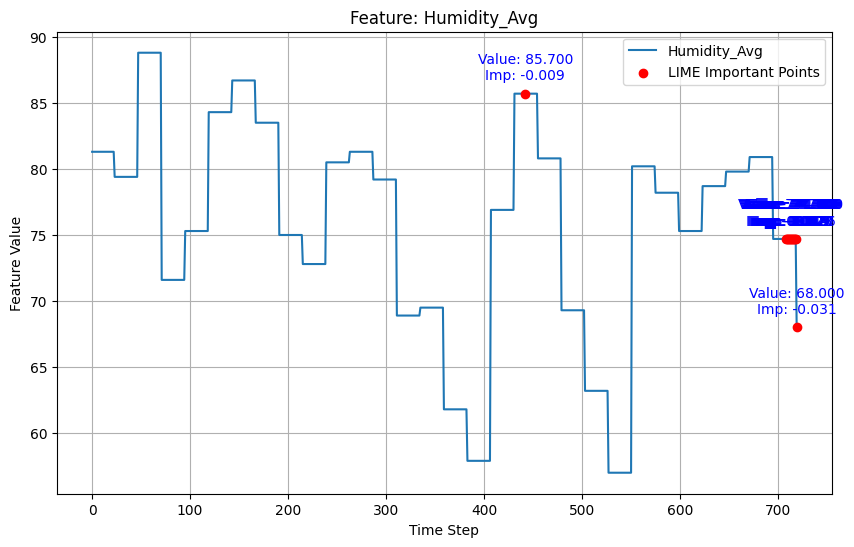


Feature: Humidity_Avg - Detailed Information
Time Step: 718, Feature Value: 74.700, Importance: -0.036
Time Step: 719, Feature Value: 68.000, Importance: -0.031
Time Step: 717, Feature Value: 74.700, Importance: -0.027
Time Step: 715, Feature Value: 74.700, Importance: -0.023
Time Step: 714, Feature Value: 74.700, Importance: -0.021
Time Step: 716, Feature Value: 74.700, Importance: -0.020
Time Step: 710, Feature Value: 74.700, Importance: -0.018
Time Step: 713, Feature Value: 74.700, Importance: -0.017
Time Step: 711, Feature Value: 74.700, Importance: -0.014
Time Step: 712, Feature Value: 74.700, Importance: -0.013
Time Step: 709, Feature Value: 74.700, Importance: -0.012
Time Step: 708, Feature Value: 74.700, Importance: -0.011
Time Step: 442, Feature Value: 85.700, Importance: -0.009


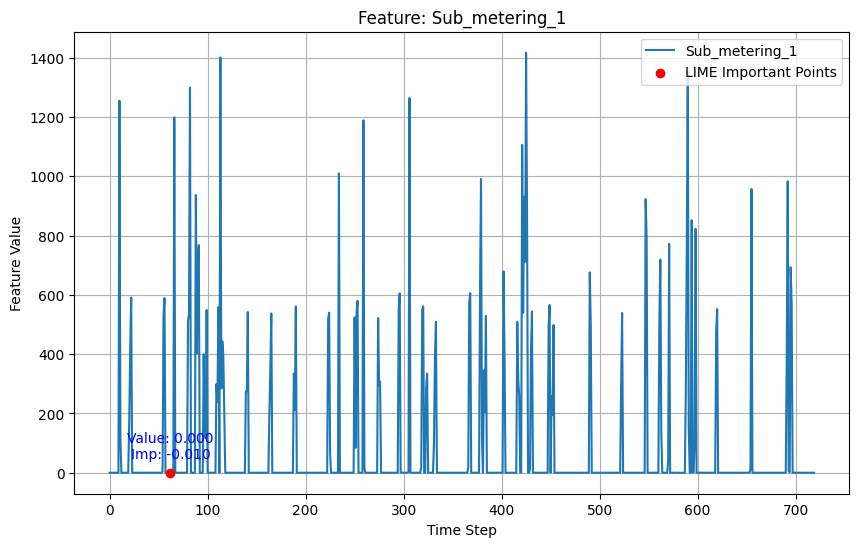


Feature: Sub_metering_1 - Detailed Information
Time Step: 62, Feature Value: 0.000, Importance: -0.010


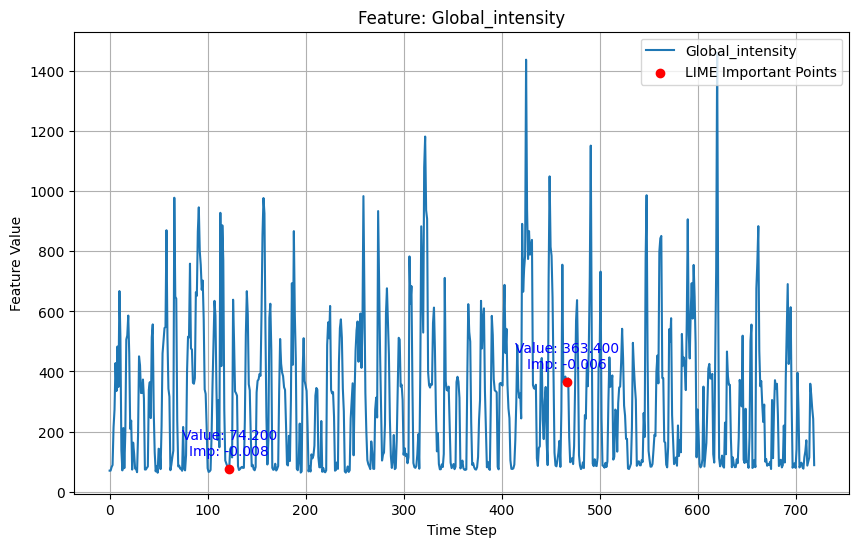


Feature: Global_intensity - Detailed Information
Time Step: 122, Feature Value: 74.200, Importance: -0.008
Time Step: 467, Feature Value: 363.400, Importance: -0.006


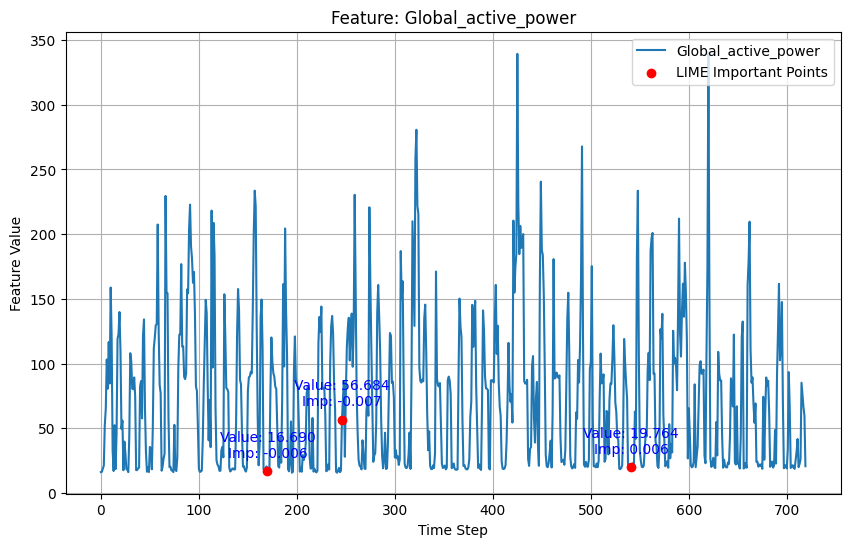


Feature: Global_active_power - Detailed Information
Time Step: 246, Feature Value: 56.684, Importance: -0.007
Time Step: 541, Feature Value: 19.764, Importance: 0.006
Time Step: 170, Feature Value: 16.690, Importance: -0.006


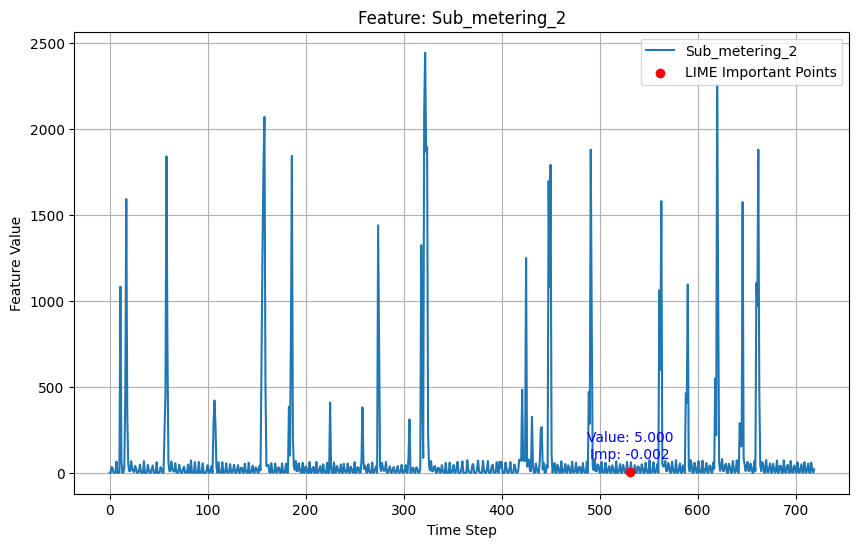


Feature: Sub_metering_2 - Detailed Information
Time Step: 531, Feature Value: 5.000, Importance: -0.002


In [79]:
# LIME explainer 정의
explainer_type = 'LIME' 
explainer = get_explainer(explainer_type=explainer_type, 
                          model=retrained_model, device=device, 
                          train_sequences=train_sequences, 
                          sequence_length=sequence_length,
                          input_size=input_size,
                          selected_features=dataset.selected_features, 
                          scaler=dataset.scaler)

if explainer != None:
    # 랜덤 샘플 추출 후, 주요 feature 시각화
    random_index = np.random.choice(len(eval_sequences)) 
    random_data_point = eval_sequences[random_index] 
    print('random_index: ', random_index)
    
    explanation = explainer.explain(random_data_point, 
                                    eval_sequences,
                                    num_features=20, 
                                    is_visual=True)

### SHAP

/archive/library/anaconda3/envs/xai_311/lib/python3.11/site-packages/shap/explainers/_deep/deep_pytorch.py:243: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f'unrecognized nn.Module: {module_type}')


Summary plot


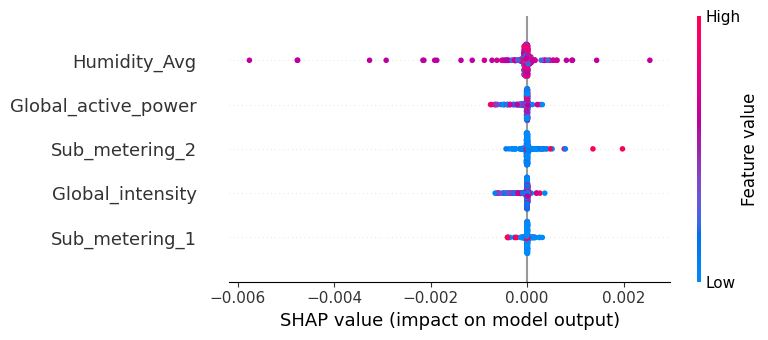

Force plot (target output index: 0)


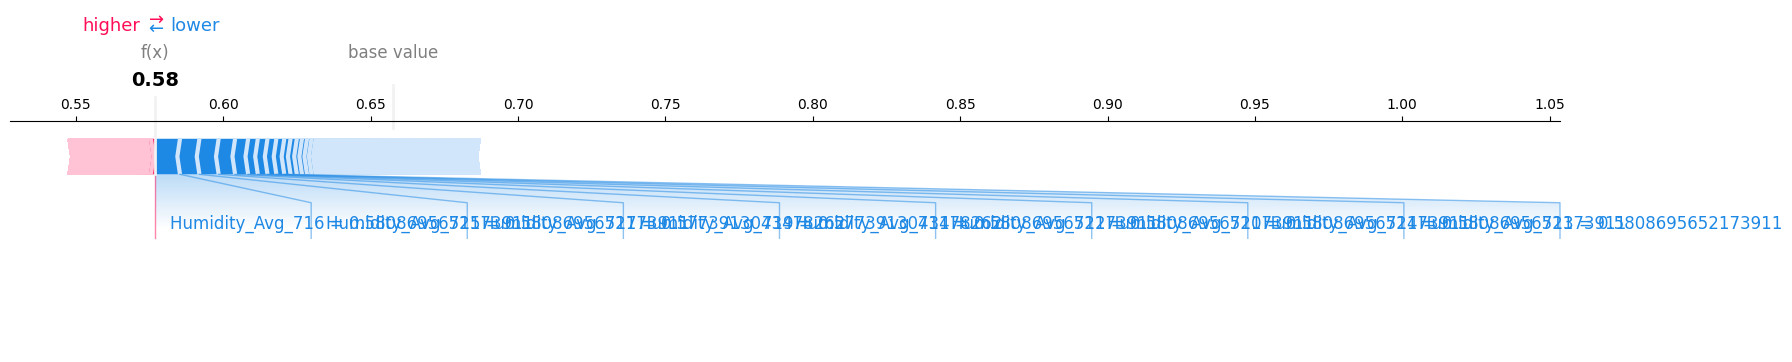

Waterfall plot (target output index: 0)


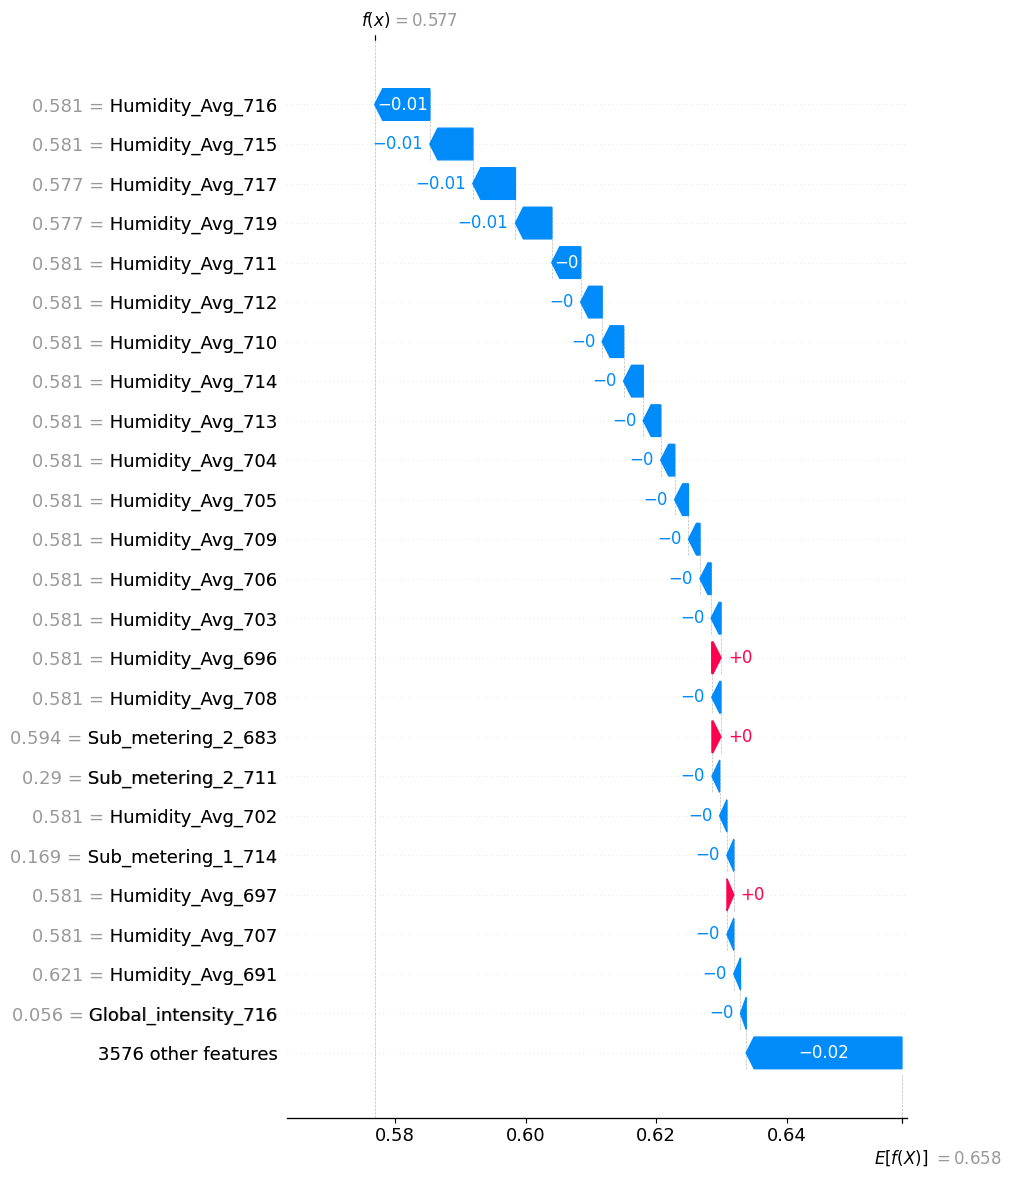

Dependence plot (target output index: 0)


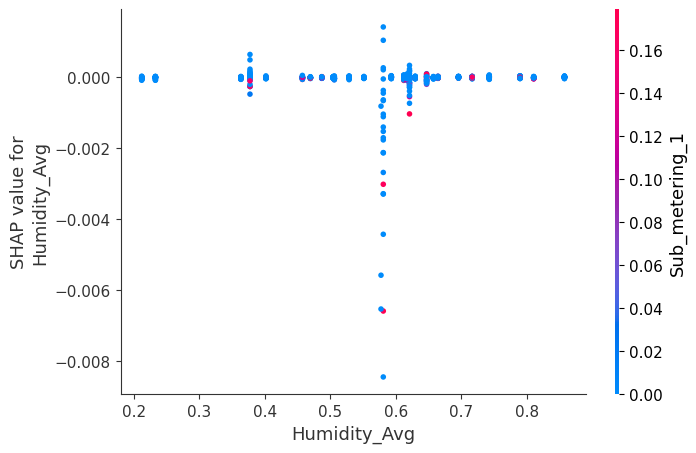

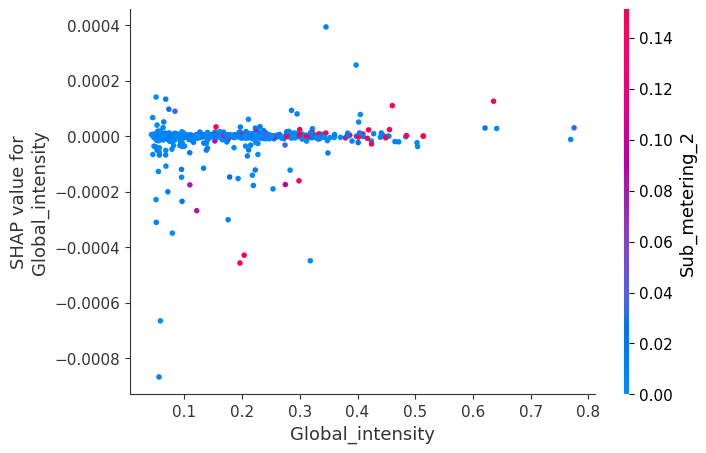

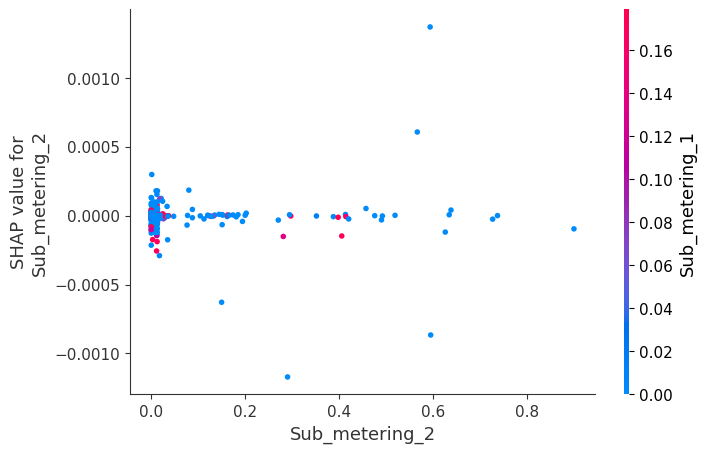

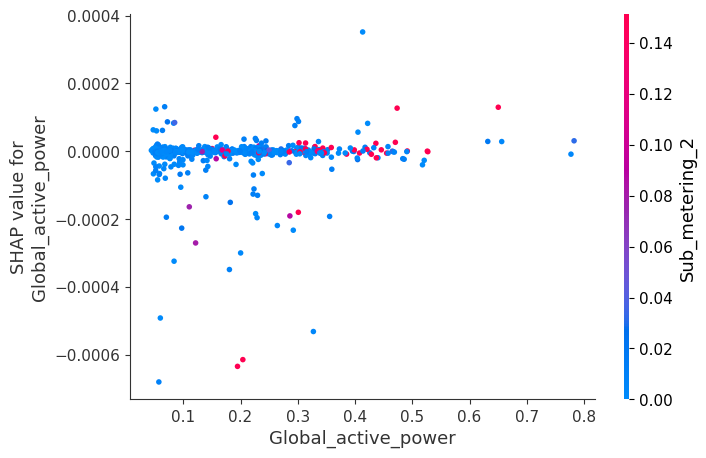

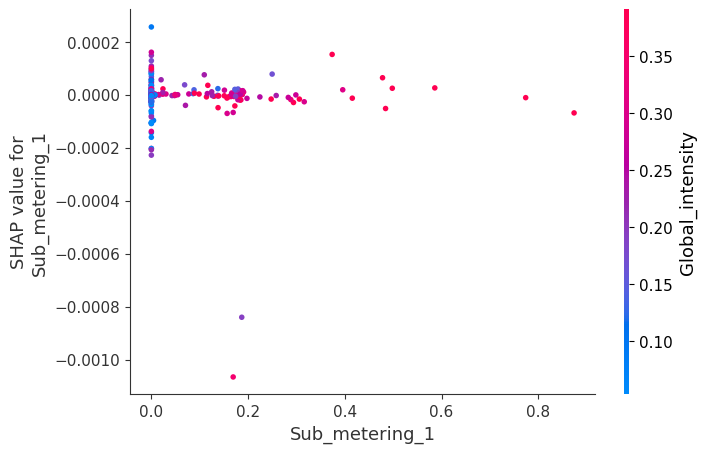

Decision plot (target output index: 0)


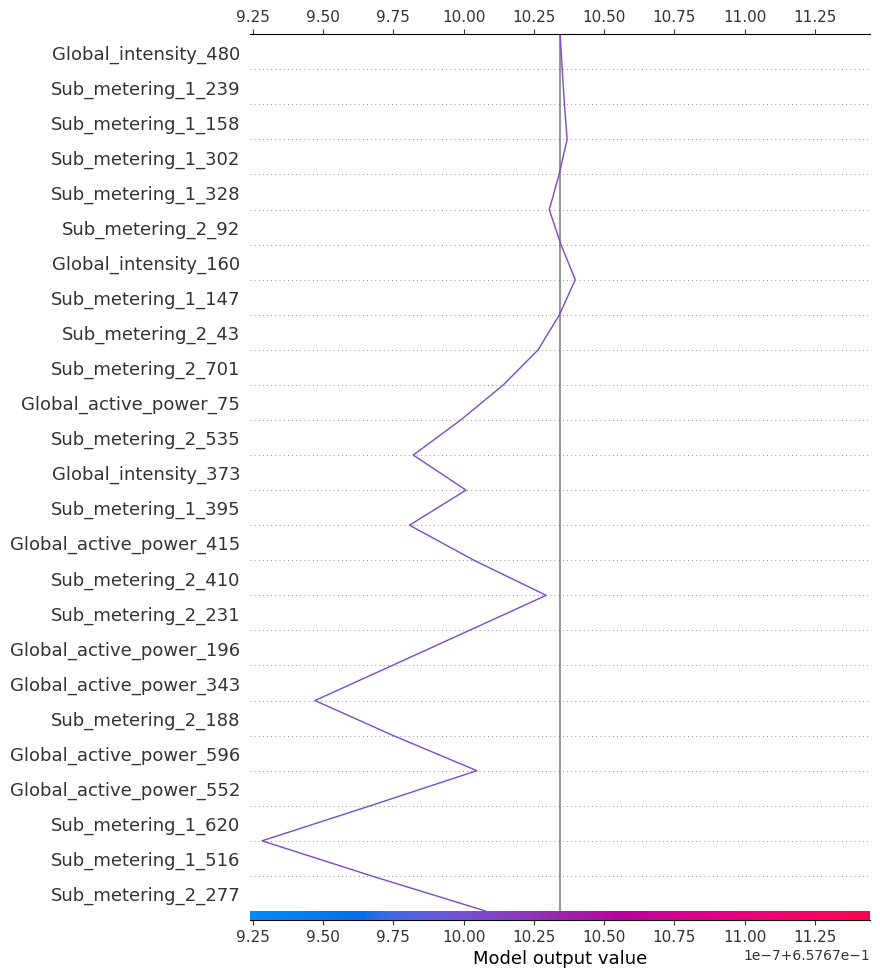

Scatter plot (target output index: 0)


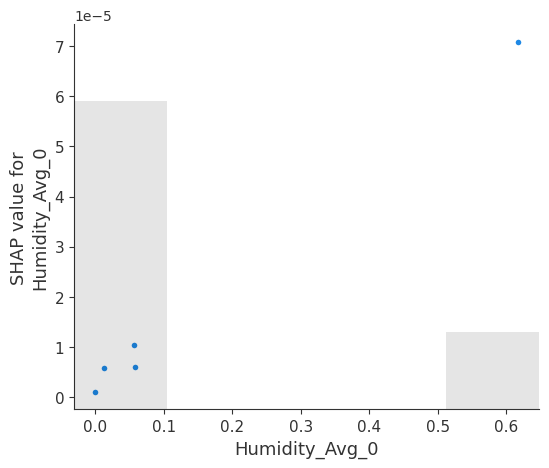

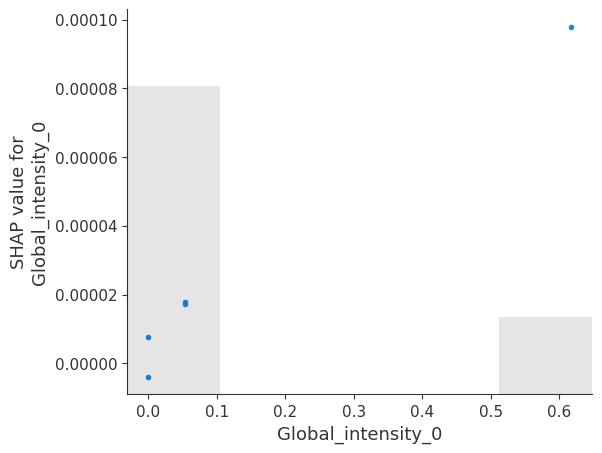

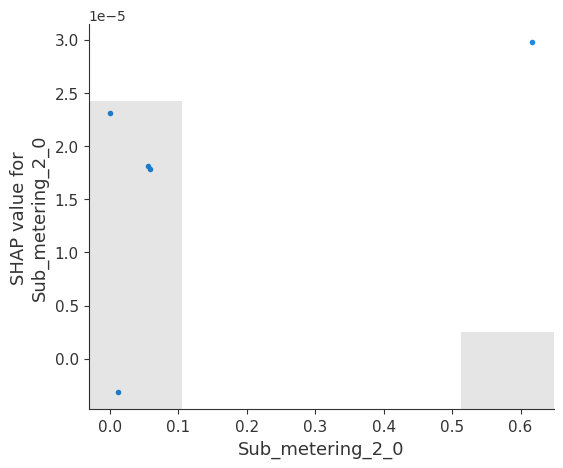

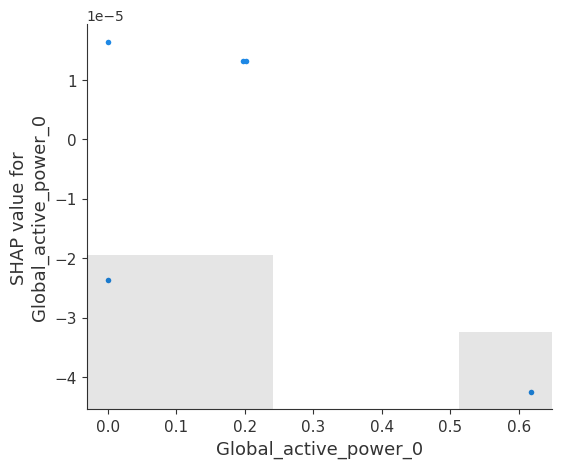

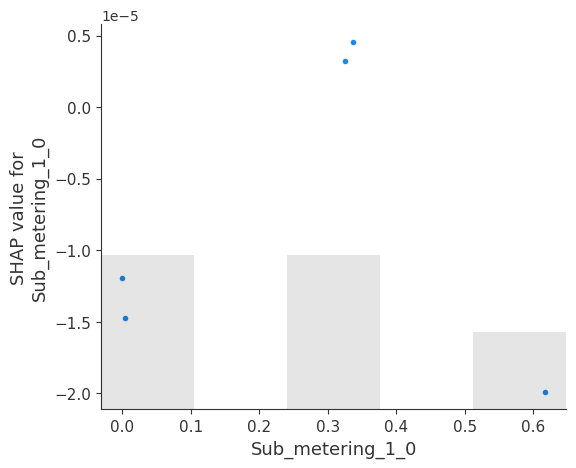

Bar plot


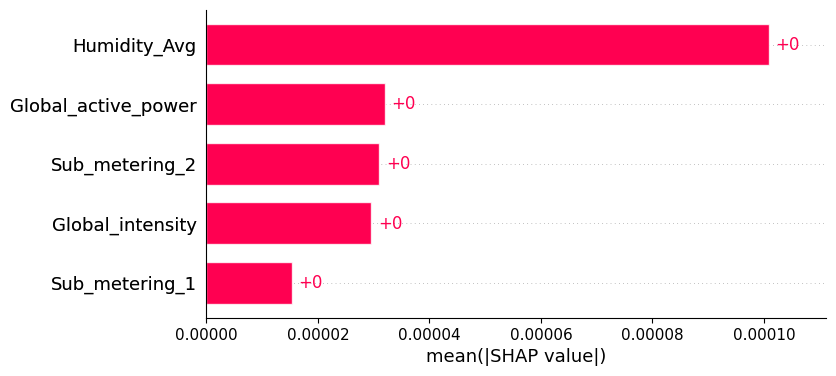

Beeswarm plot


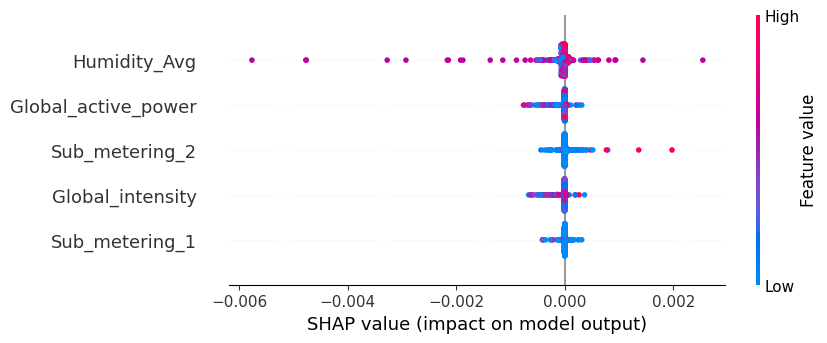

Heatmap plot


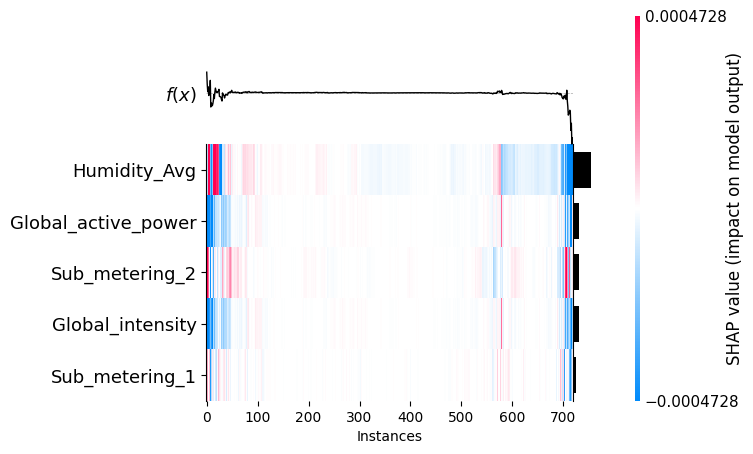

Partial Dependence Plot (feature: Humidity_Avg, target output index)


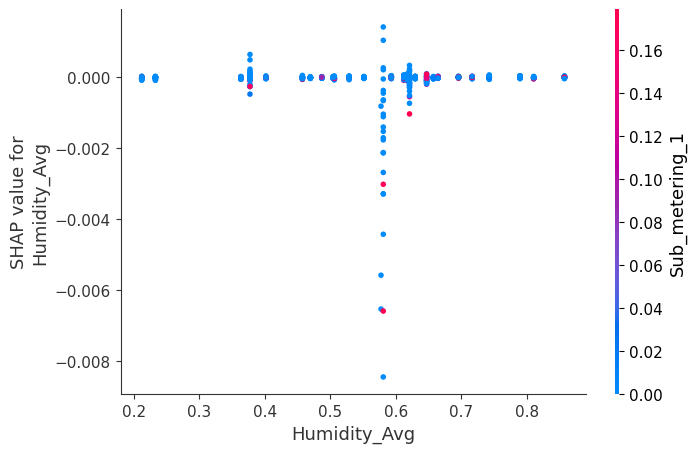

In [83]:
# SHAP explainer 정의
explainer_type = 'SHAP' 
explainer = get_explainer(explainer_type=explainer_type, 
                          model=retrained_model, device=device, 
                          train_sequences=train_sequences, 
                          sequence_length=sequence_length,
                          input_size=input_size,
                          selected_features=dataset.selected_features, 
                          scaler=dataset.scaler)

num_samples = 1
shap_values, sampled_eval_sequences = explainer.explain_DeepExplainer(eval_sequences, 
                                                                      num_samples=num_samples)
explainer.visualize_all_one_sample(shap_values[0], 
                                   sampled_eval_sequences[0], 
                                   target_f_idx1=0,
                                   target_f_idx2=1,
                                   target_idx=0)

target_feature_1:  Humidity_Avg
target_feature_2:  Global_active_power
SHAP Value Correlation Plot


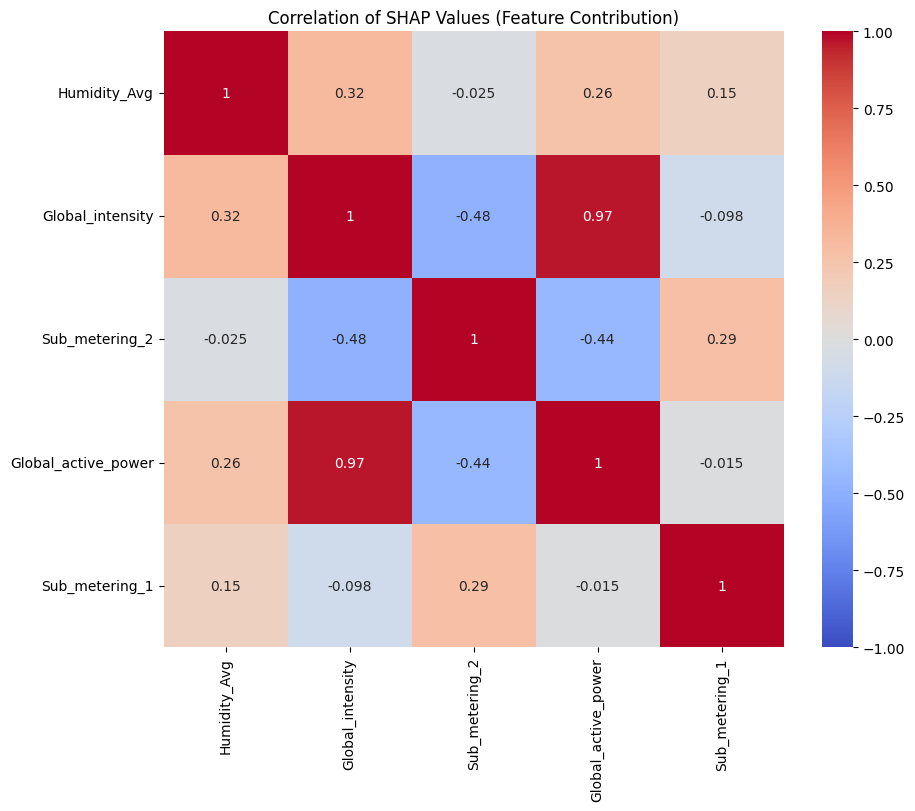

In [84]:
target_feature_1 = dataset.selected_features[0]
target_feature_2 = dataset.selected_features[3]

print('target_feature_1: ', target_feature_1)
print('target_feature_2: ', target_feature_2)

explainer.visualize_correlation(shap_values[0], sampled_eval_sequences[0], 
                                target_feature_1, target_feature_2)

/archive/library/anaconda3/envs/xai_311/lib/python3.11/site-packages/shap/explainers/_deep/deep_pytorch.py:243: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f'unrecognized nn.Module: {module_type}')


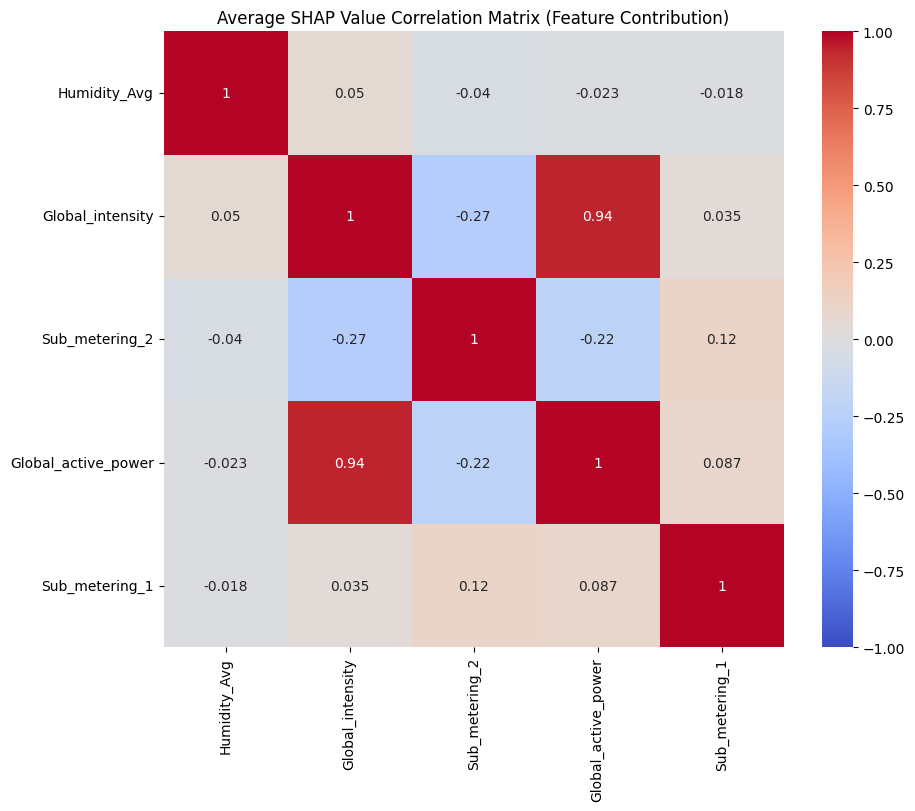

In [85]:
num_samples_shap = 50  # 여러 샘플을 사용하여 일반화된 분석 시도

shap_values, sampled_eval_sequences = explainer.explain_DeepExplainer(eval_sequences,
                                                                      num_samples=num_samples_shap)

explainer.visualize_correlation_multiple_samples(shap_values)

### Attention

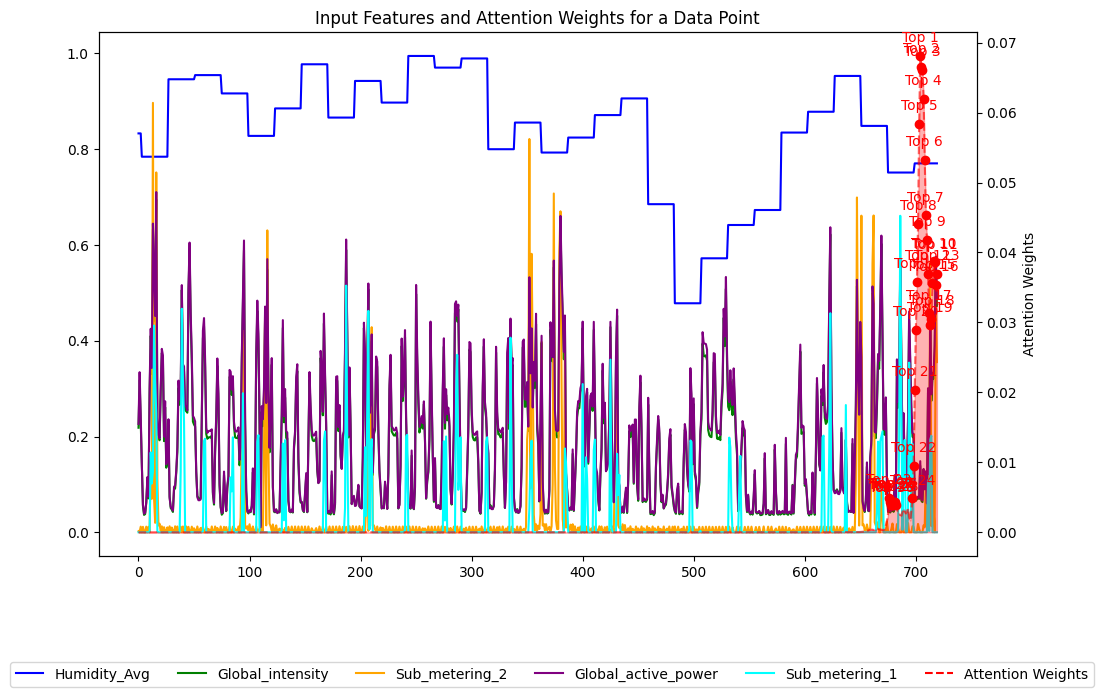

Prediction for the data point: tensor([[0.7704, 0.7779, 0.7880, 0.7974, 0.8172, 0.8228, 0.8197, 0.8193, 0.8213,
         0.8232, 0.8167, 0.8195, 0.8157, 0.8198, 0.8254, 0.8255, 0.8187, 0.8204,
         0.8218, 0.8187, 0.8177, 0.8250, 0.8227, 0.8229]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
Top 30 time steps with highest attention weights:
Top 1 - Time step 704: Attention Weight = 0.0680941641330719
  Humidity_Avg: 0.7704347826086956
  Global_intensity: 0.13881385789782735
  Sub_metering_2: 0.0
  Global_active_power: 0.1484584586618974
  Sub_metering_1: 0.0
Top 2 - Time step 705: Attention Weight = 0.06658393889665604
  Humidity_Avg: 0.7704347826086956
  Global_intensity: 0.06588373458602466
  Sub_metering_2: 0.0
  Global_active_power: 0.06918644825623933
  Sub_metering_1: 0.0
Top 3 - Time step 706: Attention Weight = 0.0660741925239563
  Humidity_Avg: 0.7704347826086956
  Global_intensity: 0.06294773928361715
  Sub_metering_2: 0.0
  Global_active_power: 0.06687464433785871
 

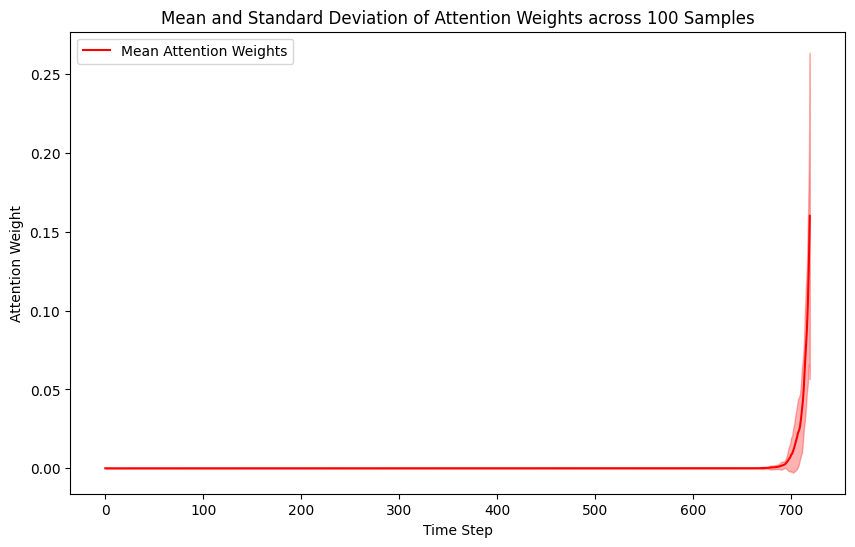

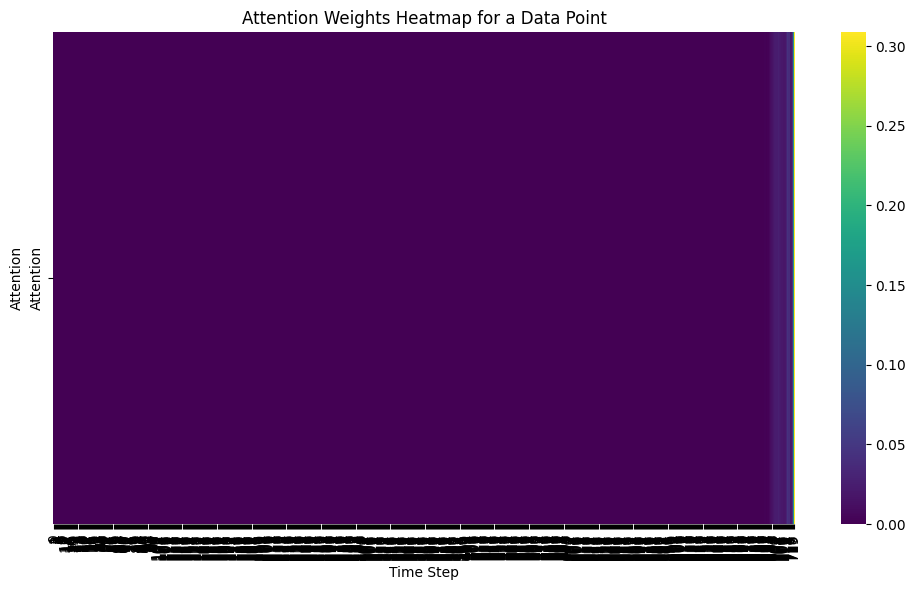

Prediction for the data point: tensor([[0.5337, 0.5251, 0.5180, 0.5104, 0.5165, 0.5179, 0.5184, 0.5169, 0.5204,
         0.5191, 0.5170, 0.5200, 0.5224, 0.5172, 0.5182, 0.5198, 0.5162, 0.5218,
         0.5246, 0.5191, 0.5197, 0.5171, 0.5134, 0.5156]], device='cuda:0',
       grad_fn=<AddmmBackward0>)


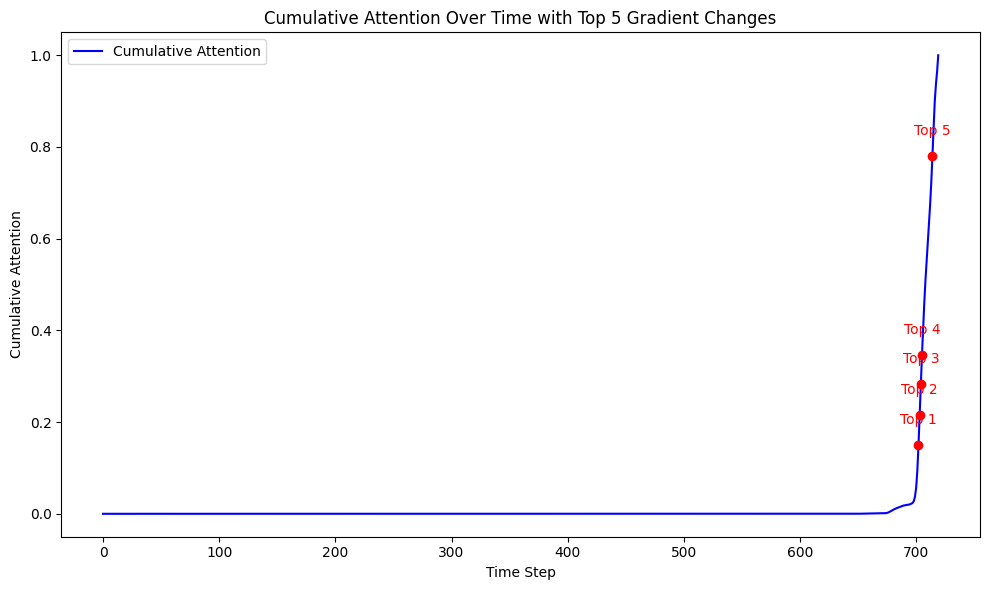

Prediction for the data point: tensor([[0.6379, 0.6355, 0.6341, 0.6261, 0.6263, 0.6184, 0.6106, 0.6091, 0.6114,
         0.6075, 0.5997, 0.6050, 0.6127, 0.6161, 0.6168, 0.6164, 0.6134, 0.6155,
         0.6159, 0.6119, 0.6128, 0.6129, 0.6103, 0.6111]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
Top 5 steps with largest gradient changes:
Top 1 - Time step 702: Gradient Change = 0.05559831112623215
  Humidity_Avg: 0.6313043478260868
  Global_intensity: 0.05179095713446859
  Sub_metering_2: 0.016312594840667678
  Global_active_power: 0.05362368913096496
  Sub_metering_1: 0.0
Top 2 - Time step 703: Gradient Change = 0.06633323431015015
  Humidity_Avg: 0.6313043478260868
  Global_intensity: 0.049207281268349966
  Sub_metering_2: 0.0034142640364188165
  Global_active_power: 0.049035647508332655
  Sub_metering_1: 0.0
Top 3 - Time step 704: Gradient Change = 0.06736037135124207
  Humidity_Avg: 0.6313043478260868
  Global_intensity: 0.05202583675866118
  Sub_metering_2: 0.0106221547799696

In [87]:
# Attention explainer 정의
explainer_type = 'Attention' 
explainer = get_explainer(explainer_type=explainer_type, 
                          model=retrained_model, device=device, 
                          train_sequences=train_sequences, 
                          sequence_length=sequence_length,
                          input_size=input_size,
                          selected_features=dataset.selected_features, 
                          scaler=dataset.scaler)

attention_top_n = 30

# random smaple 하나에 대해서 attention weight 시각화
explainer.visualize_attention(n=attention_top_n) 

# n개 sample에 대해서 attention weight 분포 시각화
explainer.analyze_attention_distribution(num_samples=100)

# attention heatmap 시각화
explainer.visualize_attention_heatmap()

explainer.visualize_cumulative_attention(num_points=top_n)

### Grad-CAM

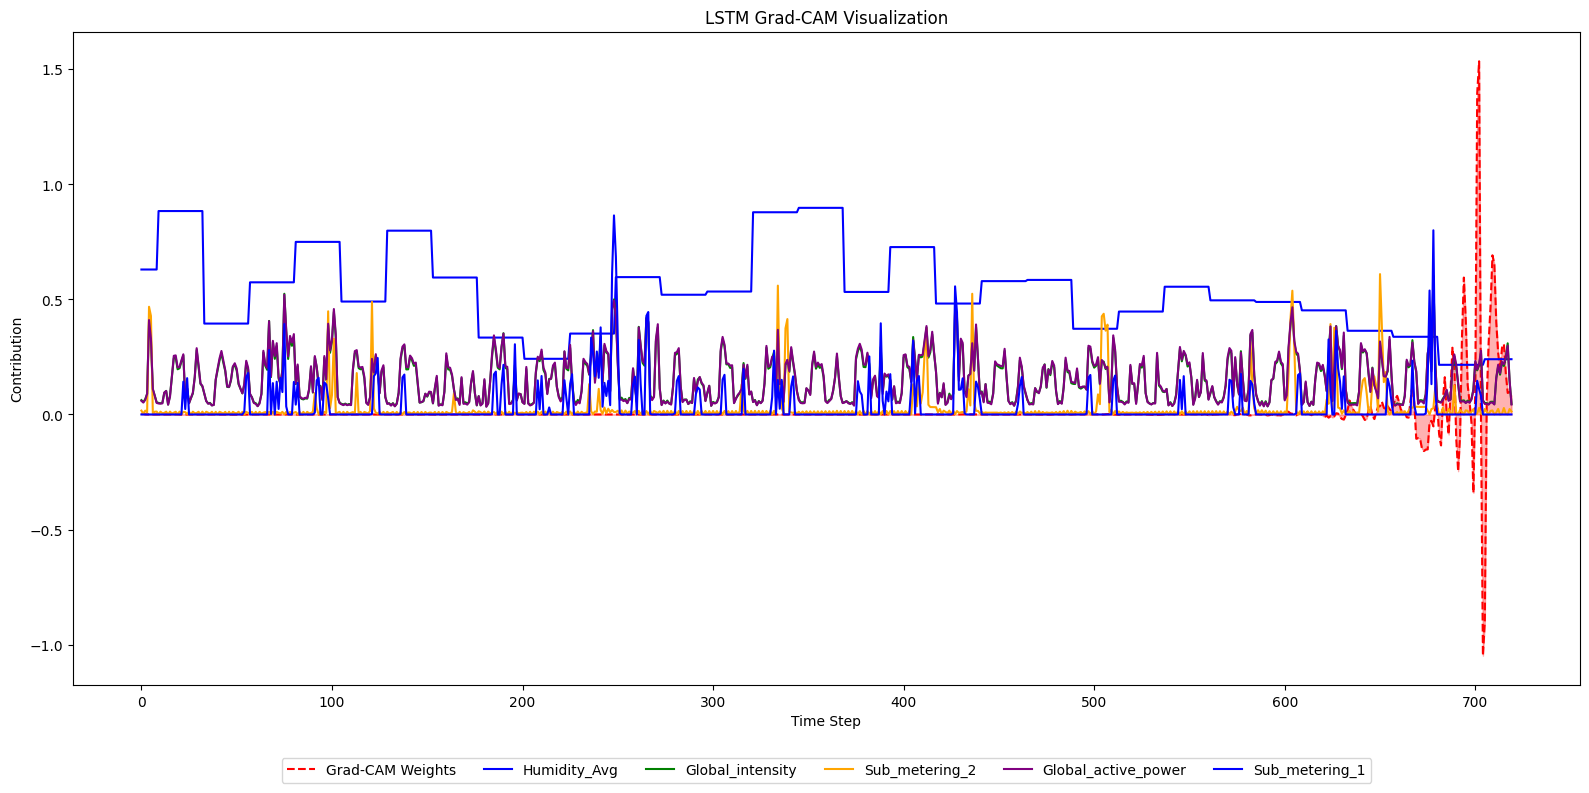

In [88]:
# LIME explainer 정의
explainer_type = 'GRAD_CAM' 
explainer = get_explainer(explainer_type=explainer_type, 
                          model=retrained_model, device=device, 
                          train_sequences=train_sequences, 
                          sequence_length=sequence_length,
                          input_size=input_size,
                          selected_features=dataset.selected_features, 
                          scaler=dataset.scaler)

data_point = eval_sequences[np.random.choice(len(eval_sequences))]

grad_cam_weights = explainer.compute_grad_cam(data_point)
explainer.visualize_grad_cam(grad_cam_weights, data_point, dataset.selected_features)

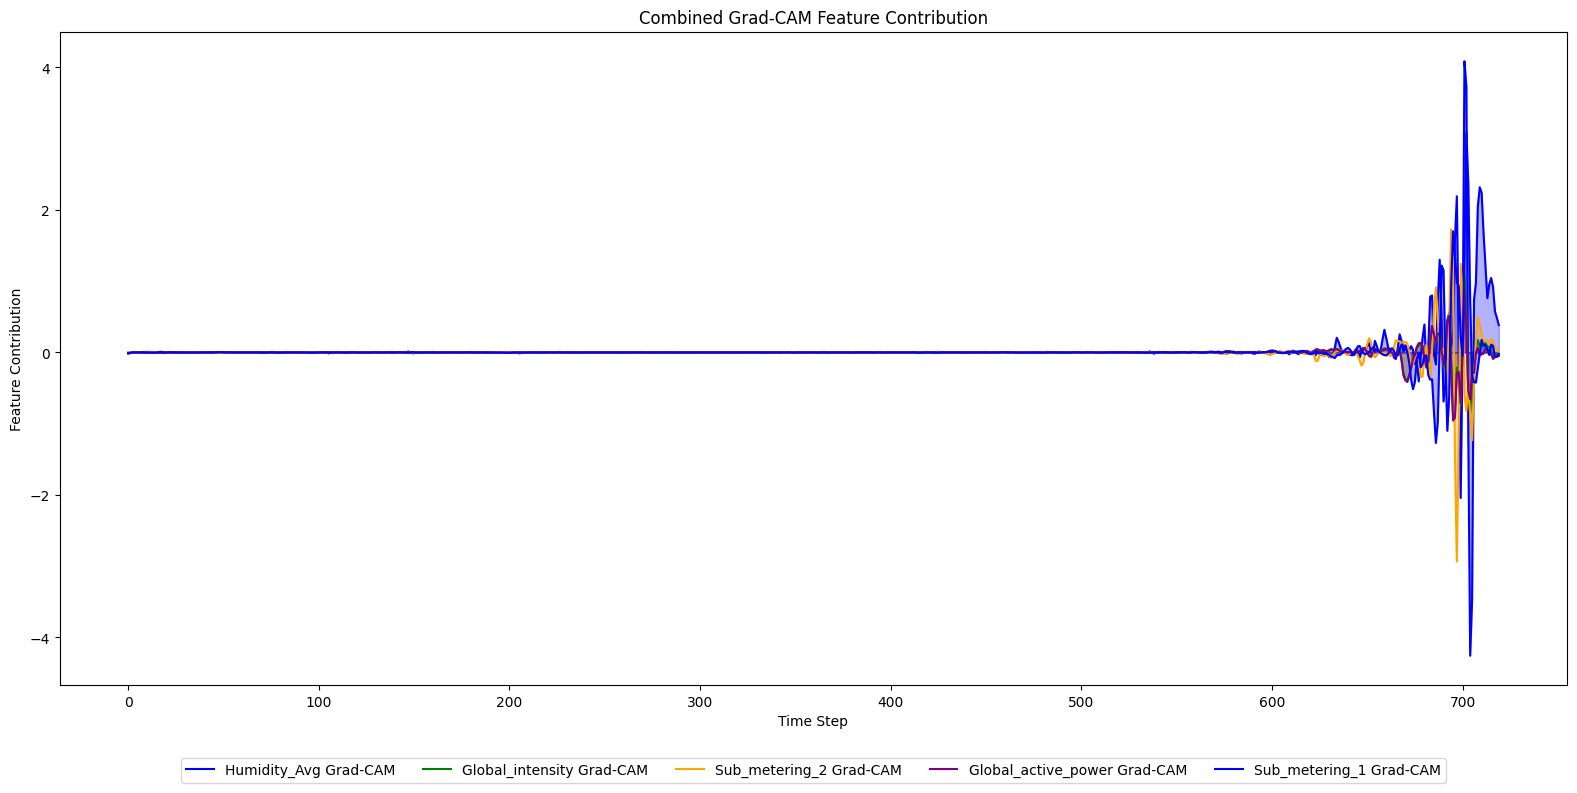

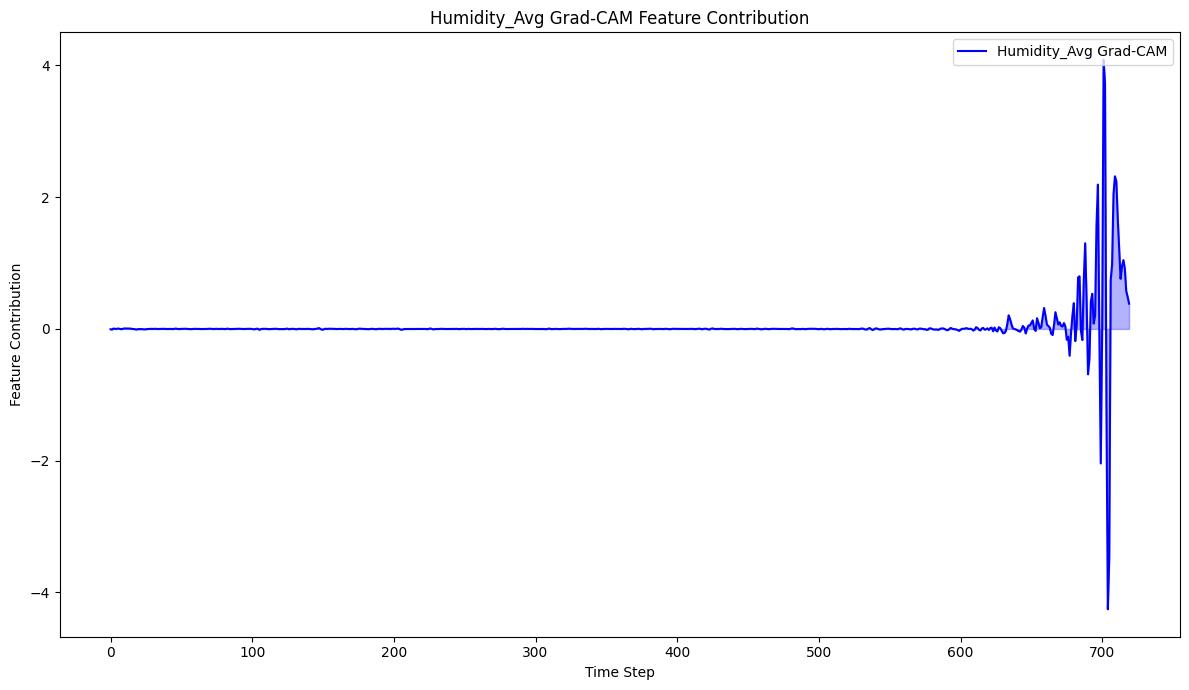

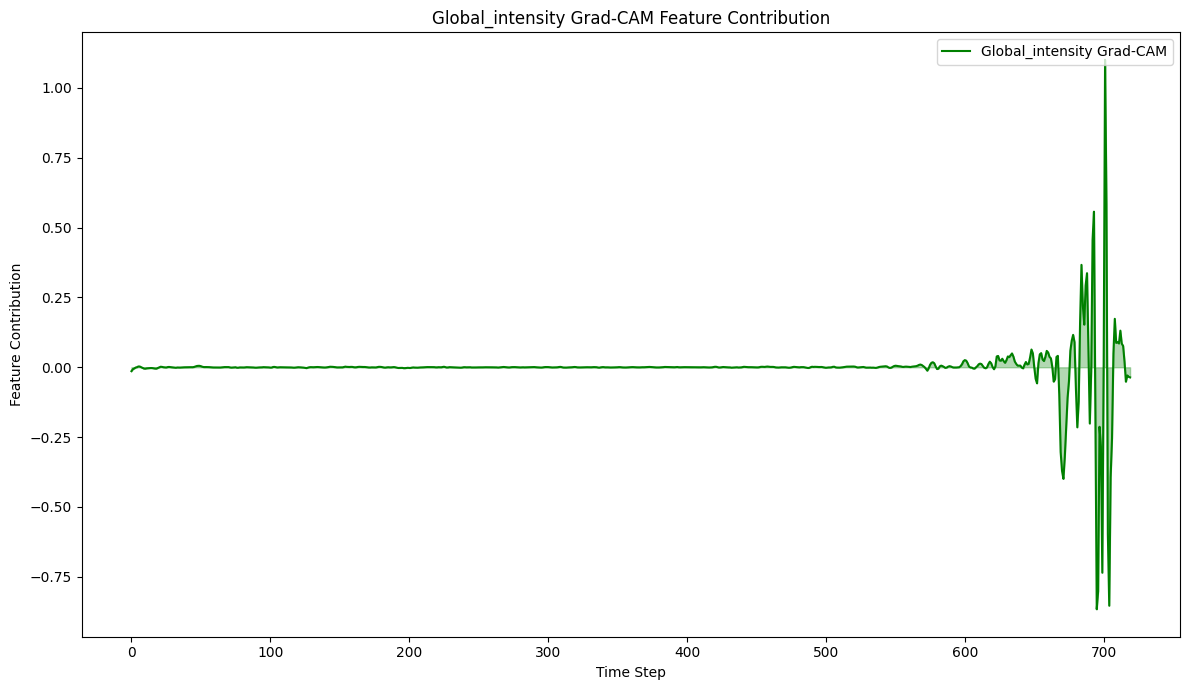

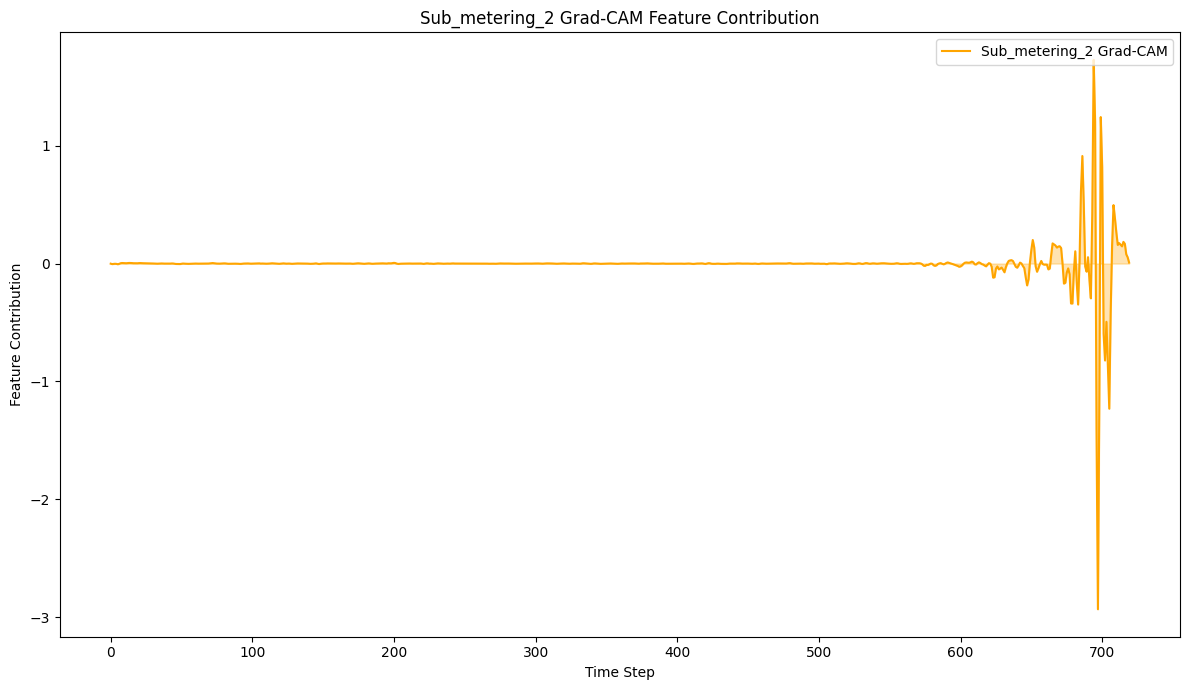

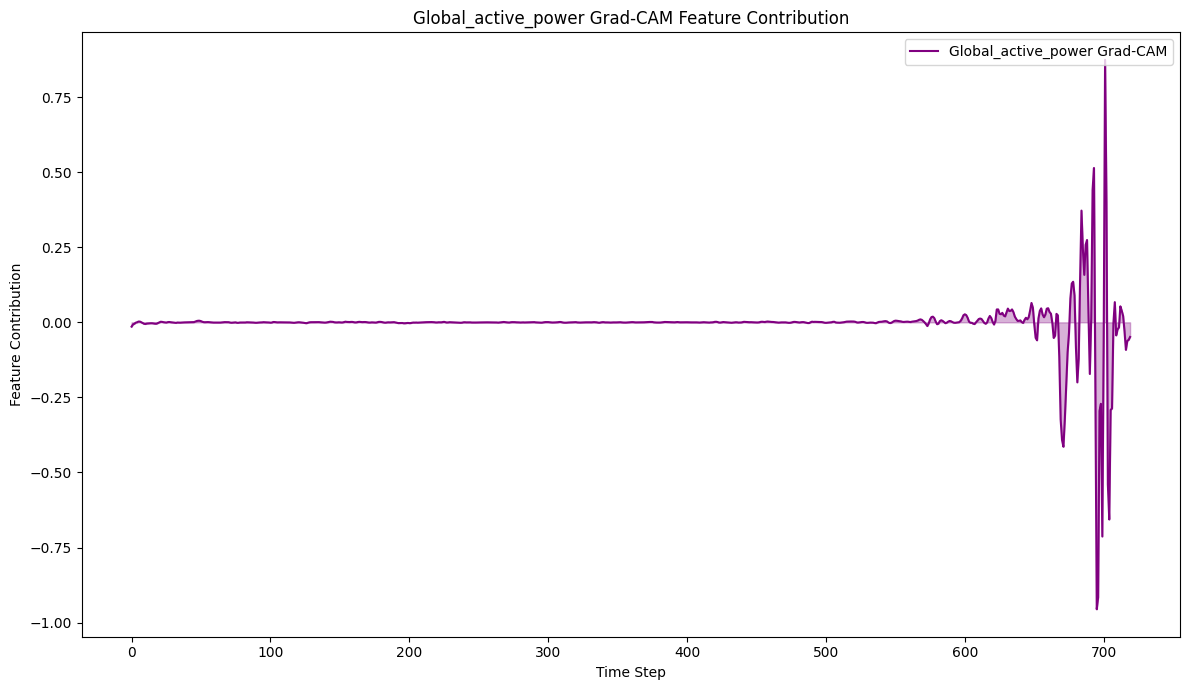

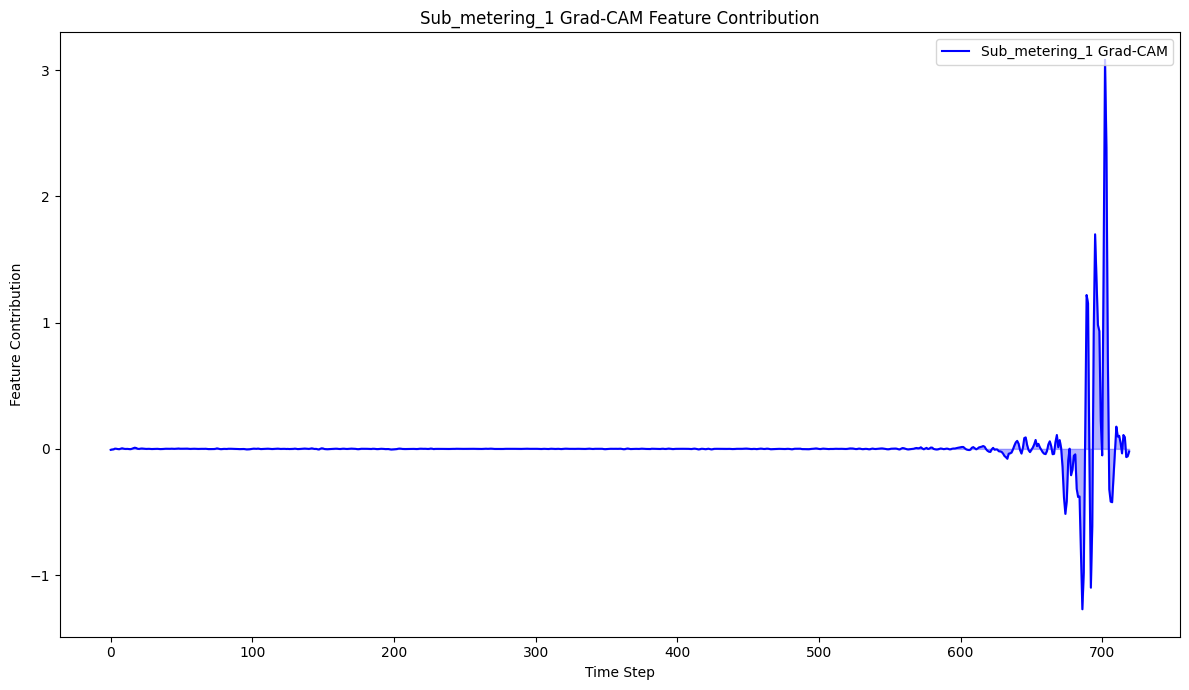

In [89]:
grad_cam_weights_per_feature = explainer.compute_grad_cam_per_feature(data_point)
explainer.visualize_grad_cam_per_feature(grad_cam_weights_per_feature, 
                                         data_point, dataset.selected_features)